## Cell 1 — Environment setup, reproducibility, and experiment configuration

This cell initializes the Python environment, fixes random seeds for reproducibility, prepares output folders, and defines a central experiment configuration dictionary. It also stores run metadata so the notebook can support a research-grade workflow with traceable figures, tables, and parameter settings.

In [1]:
import os
import sys
import json
import math
import random
import platform
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# Runtime environment
# -----------------------------
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

PROJECT_NAME = "quantum_secure_comm"

if IN_COLAB:
    drive.mount("/content/drive", force_remount=True)
    ROOT_DIR = Path(f"/content/drive/MyDrive/Outputs/{PROJECT_NAME}")
else:
    ROOT_DIR = Path("./Outputs") / PROJECT_NAME

FIG_DIR = ROOT_DIR / "figures"
TAB_DIR = ROOT_DIR / "tables"
OTH_DIR = ROOT_DIR / "others"

for d in [ROOT_DIR, FIG_DIR, TAB_DIR, OTH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OUTPUTS_SUMMARY_PATH = ROOT_DIR / "outputs_summary.txt"
RUN_METADATA_PATH = OTH_DIR / "run_metadata.json"
CONFIG_PATH = OTH_DIR / "experiment_config.json"

# -----------------------------
# Plot settings
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.size": 11
})

# -----------------------------
# Central experiment configuration
# -----------------------------
CONFIG = {
    "project_name": PROJECT_NAME,
    "seed": SEED,
    "time_horizon": 24,
    "max_candidate_paths_per_flow": 8,
    "max_path_hops": 6,
    "security_weights": {
        "alpha_qkd": 0.55,
        "beta_trust_penalty": 0.22,
        "lambda_cost": 0.30,
        "gamma_risk": 0.45
    },
    "risk_weights": {
        "trust": 0.45,
        "noise": 0.30,
        "qber": 0.25
    },
    "notes": (
        "Architecture-level hybrid QKD-PQC STIN simulation. "
        "This notebook models surrogate quantum-security behavior rather than "
        "full physical-layer satellite QKD."
    )
}

# Persist config for reproducibility
with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)

run_metadata = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "networkx_version": nx.__version__,
    "matplotlib_version": plt.matplotlib.__version__,
    "in_colab": IN_COLAB,
    "root_dir": str(ROOT_DIR.resolve()),
    "config_path": str(CONFIG_PATH.resolve()),
}
with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print(f"[INFO] Root output directory: {ROOT_DIR.resolve()}")
print(f"[INFO] Figures directory: {FIG_DIR.resolve()}")
print(f"[INFO] Tables directory: {TAB_DIR.resolve()}")
print(f"[INFO] Metadata saved: {RUN_METADATA_PATH.resolve()}")
print(f"[INFO] Config saved: {CONFIG_PATH.resolve()}")

[INFO] Root output directory: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm
[INFO] Figures directory: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm\figures
[INFO] Tables directory: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm\tables
[INFO] Metadata saved: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm\others\run_metadata.json
[INFO] Config saved: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm\others\experiment_config.json


## Cell 2 — Unified theoretical quantities and surrogate security utilities

This cell defines the mathematical quantities used throughout the notebook. The formulation is intentionally architecture-level rather than full physical-layer quantum simulation. It includes role/layer typing, surrogate QKD and PQC secure-rate models, path degradation and risk operators, a normalized hybrid security level, and the Quantum Security Functional used later for path selection under dynamic STIN conditions.

In [2]:
# -----------------------------
# Role and layer definitions
# -----------------------------
def node_role(name: str) -> str:
    if name.startswith("SAT"):
        return "satellite"
    if name.startswith("UAV"):
        return "uav"
    if name.startswith("GW"):
        return "gateway"
    if name.startswith("BS"):
        return "base_station"
    if name.startswith("DC"):
        return "data_center"
    return "unknown"

def node_layer(name: str) -> str:
    role = node_role(name)
    if role == "satellite":
        return "space"
    if role == "uav":
        return "air"
    return "ground"

def edge_role_class(u: str, v: str) -> str:
    ru, rv = node_role(u), node_role(v)
    roles = {ru, rv}

    if roles == {"satellite"}:
        return "inter_satellite"
    if "satellite" in roles and "gateway" in roles:
        return "satellite_gateway"
    if "satellite" in roles and "uav" in roles:
        return "satellite_aerial"
    if "uav" in roles and "gateway" in roles:
        return "aerial_gateway"
    if "uav" in roles and "base_station" in roles:
        return "aerial_access"
    if "gateway" in roles and "base_station" in roles:
        return "gateway_backhaul"
    if roles == {"base_station"}:
        return "terrestrial_backhaul"
    if "base_station" in roles and "data_center" in roles:
        return "metro_core"
    if "gateway" in roles and "data_center" in roles:
        return "gateway_core"
    return "heterogeneous_ground"

# -----------------------------
# Numeric helpers
# -----------------------------
def clip01(x: float) -> float:
    return float(np.clip(x, 0.0, 1.0))

def safe_mean(values) -> float:
    values = list(values)
    return float(np.mean(values)) if values else 0.0

def normalize_value(value: float, upper_bound: float, lower_bound: float = 0.0) -> float:
    if upper_bound <= lower_bound:
        return 0.0
    return float(np.clip((value - lower_bound) / (upper_bound - lower_bound), 0.0, 1.0))

def binary_entropy(p: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    return float(-(p * np.log2(p) + (1.0 - p) * np.log2(1.0 - p)))

# -----------------------------
# Surrogate secure-rate models
# -----------------------------
def qkd_rate(transmissivity: float, excess_noise: float, qber: float, reconciliation_efficiency: float = 0.92) -> float:
    """
    Architecture-level surrogate QKD secret-key-rate proxy.
    It is not a protocol-exact physical model, but it preserves monotonic dependence on:
    - higher transmissivity -> higher secure rate
    - higher excess noise -> lower secure rate
    - higher QBER -> lower secure rate
    """
    eta = float(np.clip(transmissivity, 1e-6, 0.999999))
    xi = max(0.0, float(excess_noise))
    q = float(np.clip(qber, 1e-6, 0.49))

    plob_like_bound = -np.log2(1.0 - eta)
    secret_fraction = max(0.0, reconciliation_efficiency * (1.0 - 2.0 * binary_entropy(q)))
    noise_penalty = np.exp(-4.0 * xi)

    return max(0.0, plob_like_bound * secret_fraction * noise_penalty)

def pqc_secure_rate(link_capacity: float, security_margin: float, pqc_overhead: float = 0.12) -> float:
    """
    Effective secure classical/PQC throughput proxy after cryptographic overhead.
    This is a systems-level abstraction rather than a cryptanalytic model.
    """
    capacity = max(0.0, float(link_capacity))
    sec_margin = clip01(float(security_margin))
    effective_capacity = capacity * (1.0 - pqc_overhead)
    return max(0.0, effective_capacity * sec_margin)

# -----------------------------
# Path-level operators
# -----------------------------
def path_degradation_operator(path_edges_metrics) -> float:
    """
    End-to-end degradation surrogate:
    1 - product(transmissivity_i)
    """
    if not path_edges_metrics:
        return 1.0
    end_to_end_trans = 1.0
    for m in path_edges_metrics:
        end_to_end_trans *= float(np.clip(m["transmissivity"], 1e-6, 1.0))
    return float(1.0 - end_to_end_trans)

def trust_penalty(trust_path: float, beta: float = None) -> float:
    beta = CONFIG["security_weights"]["beta_trust_penalty"] if beta is None else beta
    trust_path = float(np.clip(trust_path, 1e-6, 1.0))
    return float(beta * (1.0 - trust_path))

def path_risk(path_edges_metrics, weights: dict = None) -> float:
    """
    Structural/operational risk surrogate combining:
    - low trust exposure
    - excess noise
    - qber
    """
    if not path_edges_metrics:
        return 1.0

    if weights is None:
        weights = CONFIG["risk_weights"]

    risk_terms = []
    for m in path_edges_metrics:
        trust_risk = 1.0 - float(np.clip(m["trust_score"], 0.0, 1.0))
        noise_risk = normalize_value(float(m["excess_noise"]), upper_bound=0.12)
        qber_risk = normalize_value(float(m["qber"]), upper_bound=0.15)

        risk = (
            weights["trust"] * trust_risk +
            weights["noise"] * noise_risk +
            weights["qber"] * qber_risk
        )
        risk_terms.append(risk)

    return float(np.clip(np.mean(risk_terms), 0.0, 1.0))

def path_latency(path_edges_metrics) -> float:
    return float(np.sum([m["latency_ms"] for m in path_edges_metrics])) if path_edges_metrics else 0.0

def communication_cost(latency_ms: float, hop_count: int, norm_latency: float = 150.0, norm_hops: int = None) -> float:
    if norm_hops is None:
        norm_hops = CONFIG["max_path_hops"]

    latency_term = normalize_value(latency_ms, upper_bound=norm_latency)
    hop_term = normalize_value(hop_count, upper_bound=norm_hops)
    return float(0.70 * latency_term + 0.30 * hop_term)

# -----------------------------
# Hybrid security quantities
# -----------------------------
def hybrid_security_level(q_path_norm: float, p_path_norm: float, trust_path: float, alpha: float = None, beta: float = None) -> float:
    """
    Normalized hybrid security level in [0, 1] approximately.
    q_path_norm and p_path_norm should already be normalized.
    """
    alpha = CONFIG["security_weights"]["alpha_qkd"] if alpha is None else alpha
    beta = CONFIG["security_weights"]["beta_trust_penalty"] if beta is None else beta

    q_path_norm = clip01(q_path_norm)
    p_path_norm = clip01(p_path_norm)
    trust_path = clip01(trust_path)

    base = alpha * q_path_norm + (1.0 - alpha) * p_path_norm
    penalty = trust_penalty(trust_path, beta=beta)
    return float(np.clip(base - penalty, 0.0, 1.0))

def security_margin_value(security_level: float, security_req: float) -> float:
    return float(security_level - security_req)

def qkd_share(q_path_norm: float, p_path_norm: float, eps: float = 1e-9) -> float:
    total = max(q_path_norm + p_path_norm, eps)
    return float(q_path_norm / total)

def nonlinear_security_value(
    security_level: float,
    q_share: float,
    trust_path: float,
    degradation_path: float
) -> float:
    """
    Reward secure paths with better trust and lower degradation,
    while allowing a modest benefit for stronger quantum contribution.
    """
    security_level = clip01(security_level)
    q_share = clip01(q_share)
    trust_path = clip01(trust_path)
    degradation_path = clip01(degradation_path)

    return float(
        security_level *
        (0.55 + 0.20 * q_share + 0.25 * trust_path) *
        (1.0 - 0.35 * degradation_path)
    )

def quantum_security_functional(
    security_level: float,
    security_req: float,
    q_share: float,
    trust_path: float,
    latency_ms: float,
    hop_count: int,
    risk_val: float,
    degradation_val: float,
    flow_priority: float,
    lam: float = None,
    gamma: float = None
) -> float:
    lam = CONFIG["security_weights"]["lambda_cost"] if lam is None else lam
    gamma = CONFIG["security_weights"]["gamma_risk"] if gamma is None else gamma

    sec_margin = security_margin_value(security_level, security_req)
    benefit = nonlinear_security_value(
        security_level=security_level,
        q_share=q_share,
        trust_path=trust_path,
        degradation_path=degradation_val
    )
    margin_bonus = 0.20 * np.tanh(4.0 * sec_margin)
    cost = communication_cost(latency_ms=latency_ms, hop_count=hop_count)

    score = (
        float(flow_priority) * benefit +
        margin_bonus -
        lam * cost -
        gamma * float(np.clip(risk_val, 0.0, 1.0))
    )
    return float(score)

def security_feasible(security_level: float, security_req: float) -> bool:
    return bool(security_level >= security_req)

# -----------------------------
# Security Criticality Index (SCI)
# -----------------------------
def security_criticality_index(
    feasible_ratio: float,
    mean_security_margin: float,
    mean_q_share: float,
    mean_risk: float
) -> float:
    """
    SCI is designed as an operating-state indicator.
    Higher SCI means stronger secure operation with:
    - higher feasibility
    - positive security margin
    - meaningful quantum participation
    - lower risk
    """
    feasible_ratio = clip01(feasible_ratio)
    margin_term = clip01(0.5 + 0.5 * mean_security_margin)
    q_share_term = clip01(mean_q_share)
    risk_term = 1.0 - clip01(mean_risk)

    sci = feasible_ratio * (0.45 * margin_term + 0.25 * q_share_term + 0.30 * risk_term)
    return float(np.clip(sci, 0.0, 1.0))

def classify_security_regime(sci: float) -> str:
    if sci < 0.30:
        return "sparse"
    if sci < 0.65:
        return "transition"
    return "saturation"

print("[INFO] Unified surrogate security utilities are ready.")

[INFO] Unified surrogate security utilities are ready.


## Cell 3 — Multi-layer STIN topology construction with role-aware links

This cell constructs the synthetic STIN demonstrator as a role-aware graph with satellite, UAV, gateway, base-station, and data-center nodes. Unlike the earlier coarse model, links are now parameterized by explicit edge classes such as inter-satellite, satellite-to-gateway, aerial-access, gateway-backhaul, and metro-core. This makes the topology more defensible for architecture-level hybrid-security evaluation.

In [3]:
G = nx.Graph()

# -----------------------------
# Node definitions
# -----------------------------
nodes = [
    "SAT_1", "SAT_2",
    "UAV_1", "UAV_2",
    "GW_1", "GW_2",
    "BS_1", "BS_2", "BS_3",
    "DC_1"
]
G.add_nodes_from(nodes)

# Fixed positions for reproducible plotting and pseudo-geometry
node_pos = {
    "SAT_1": (0.12, 0.92),
    "SAT_2": (0.88, 0.92),
    "UAV_1": (0.24, 0.70),
    "UAV_2": (0.76, 0.70),
    "GW_1":  (0.24, 0.48),
    "GW_2":  (0.76, 0.48),
    "BS_1":  (0.12, 0.20),
    "BS_2":  (0.50, 0.20),
    "BS_3":  (0.88, 0.20),
    "DC_1":  (0.50, 0.04),
}

for n in G.nodes():
    G.nodes[n]["role"] = node_role(n)
    G.nodes[n]["layer"] = node_layer(n)
    G.nodes[n]["pos"] = node_pos[n]

# -----------------------------
# Edge definitions
# -----------------------------
edges = [
    ("SAT_1", "SAT_2"),
    ("SAT_1", "UAV_1"),
    ("SAT_2", "UAV_2"),
    ("SAT_1", "GW_1"),
    ("SAT_2", "GW_2"),
    ("UAV_1", "GW_1"),
    ("UAV_2", "GW_2"),
    ("UAV_1", "BS_2"),
    ("UAV_2", "BS_2"),
    ("GW_1", "BS_1"),
    ("GW_1", "BS_2"),
    ("GW_2", "BS_2"),
    ("GW_2", "BS_3"),
    ("BS_1", "BS_2"),
    ("BS_2", "BS_3"),
    ("BS_1", "DC_1"),
    ("BS_2", "DC_1"),
    ("BS_3", "DC_1"),
]
G.add_edges_from(edges)

# -----------------------------
# Link-class parameter library
# Architecture-level surrogate ranges
# -----------------------------
LINK_CLASS_PARAMS = {
    "inter_satellite": {
        "distance_km": (900, 1400),
        "transmissivity": (0.20, 0.38),
        "noise": (0.010, 0.030),
        "qber": (0.010, 0.040),
        "latency_ms": (12, 22),
        "capacity": (8, 16),
        "security_margin": (0.82, 0.96),
        "trust": (0.82, 0.94),
    },
    "satellite_gateway": {
        "distance_km": (700, 1200),
        "transmissivity": (0.14, 0.32),
        "noise": (0.020, 0.060),
        "qber": (0.020, 0.065),
        "latency_ms": (20, 40),
        "capacity": (6, 14),
        "security_margin": (0.80, 0.95),
        "trust": (0.72, 0.88),
    },
    "satellite_aerial": {
        "distance_km": (500, 950),
        "transmissivity": (0.16, 0.36),
        "noise": (0.018, 0.055),
        "qber": (0.018, 0.060),
        "latency_ms": (16, 32),
        "capacity": (6, 14),
        "security_margin": (0.80, 0.94),
        "trust": (0.70, 0.86),
    },
    "aerial_gateway": {
        "distance_km": (120, 260),
        "transmissivity": (0.30, 0.58),
        "noise": (0.010, 0.035),
        "qber": (0.012, 0.045),
        "latency_ms": (7, 15),
        "capacity": (10, 22),
        "security_margin": (0.82, 0.96),
        "trust": (0.76, 0.90),
    },
    "aerial_access": {
        "distance_km": (80, 180),
        "transmissivity": (0.36, 0.66),
        "noise": (0.008, 0.030),
        "qber": (0.010, 0.040),
        "latency_ms": (5, 12),
        "capacity": (12, 24),
        "security_margin": (0.84, 0.97),
        "trust": (0.78, 0.92),
    },
    "gateway_backhaul": {
        "distance_km": (25, 90),
        "transmissivity": (0.62, 0.90),
        "noise": (0.004, 0.018),
        "qber": (0.006, 0.020),
        "latency_ms": (2, 8),
        "capacity": (18, 36),
        "security_margin": (0.86, 0.98),
        "trust": (0.84, 0.96),
    },
    "terrestrial_backhaul": {
        "distance_km": (20, 80),
        "transmissivity": (0.72, 0.95),
        "noise": (0.003, 0.015),
        "qber": (0.005, 0.018),
        "latency_ms": (1, 6),
        "capacity": (20, 40),
        "security_margin": (0.88, 0.99),
        "trust": (0.86, 0.97),
    },
    "metro_core": {
        "distance_km": (15, 70),
        "transmissivity": (0.78, 0.96),
        "noise": (0.002, 0.012),
        "qber": (0.004, 0.016),
        "latency_ms": (1, 5),
        "capacity": (24, 44),
        "security_margin": (0.90, 0.99),
        "trust": (0.88, 0.98),
    },
    "gateway_core": {
        "distance_km": (30, 100),
        "transmissivity": (0.68, 0.92),
        "noise": (0.003, 0.015),
        "qber": (0.005, 0.018),
        "latency_ms": (2, 7),
        "capacity": (22, 40),
        "security_margin": (0.88, 0.99),
        "trust": (0.86, 0.97),
    },
    "heterogeneous_ground": {
        "distance_km": (20, 100),
        "transmissivity": (0.60, 0.88),
        "noise": (0.004, 0.020),
        "qber": (0.006, 0.022),
        "latency_ms": (2, 8),
        "capacity": (16, 32),
        "security_margin": (0.84, 0.97),
        "trust": (0.82, 0.95),
    },
}

def sample_from_range(bounds):
    return float(np.random.uniform(bounds[0], bounds[1]))

# -----------------------------
# Assign baseline edge attributes
# -----------------------------
for u, v in G.edges():
    link_class = edge_role_class(u, v)
    params = LINK_CLASS_PARAMS[link_class]

    G[u][v]["link_class"] = link_class
    G[u][v]["distance_km"] = sample_from_range(params["distance_km"])
    G[u][v]["base_transmissivity"] = sample_from_range(params["transmissivity"])
    G[u][v]["base_noise"] = sample_from_range(params["noise"])
    G[u][v]["base_qber"] = sample_from_range(params["qber"])
    G[u][v]["latency_ms"] = sample_from_range(params["latency_ms"])
    G[u][v]["link_capacity"] = sample_from_range(params["capacity"])
    G[u][v]["security_margin"] = sample_from_range(params["security_margin"])
    G[u][v]["trust_score"] = sample_from_range(params["trust"])

    # Optional architecture annotations for later analysis
    G[u][v]["supports_qkd"] = link_class in {
        "inter_satellite",
        "satellite_gateway",
        "satellite_aerial",
        "aerial_gateway",
        "aerial_access"
    }
    G[u][v]["supports_pqc"] = True

print(f"[INFO] Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

node_preview = pd.DataFrame([
    {
        "node": n,
        "role": G.nodes[n]["role"],
        "layer": G.nodes[n]["layer"],
        "pos_x": G.nodes[n]["pos"][0],
        "pos_y": G.nodes[n]["pos"][1],
    }
    for n in G.nodes()
])

edge_preview = pd.DataFrame([
    {
        "u": u,
        "v": v,
        "link_class": G[u][v]["link_class"],
        "distance_km": G[u][v]["distance_km"],
        "base_transmissivity": G[u][v]["base_transmissivity"],
        "base_noise": G[u][v]["base_noise"],
        "base_qber": G[u][v]["base_qber"],
        "latency_ms": G[u][v]["latency_ms"],
        "link_capacity": G[u][v]["link_capacity"],
        "security_margin": G[u][v]["security_margin"],
        "trust_score": G[u][v]["trust_score"],
        "supports_qkd": G[u][v]["supports_qkd"],
    }
    for u, v in G.edges()
])

display(node_preview)
display(edge_preview.head(10))

[INFO] Nodes: 10, Edges: 18


,node,role,layer,pos_x,pos_y
0,SAT_1,satellite,space,0.12,0.92
1,SAT_2,satellite,space,0.88,0.92
2,UAV_1,uav,air,0.24,0.70
3,UAV_2,uav,air,0.76,0.70
4,GW_1,gateway,ground,0.24,0.48
5,GW_2,gateway,ground,0.76,0.48
6,BS_1,base_station,ground,0.12,0.20
7,BS_2,base_station,ground,0.50,0.20
8,BS_3,base_station,ground,0.88,0.20
9,DC_1,data_center,ground,0.50,0.04


,u,v,link_class,distance_km,base_transmissivity,base_noise,base_qber,latency_ms,link_capacity,security_margin,trust_score,supports_qkd
0,SAT_1,SAT_2,inter_satellite,1087.270059,0.371129,0.024640,0.027960,13.560186,9.247956,0.828132,0.923941,True
1,SAT_1,UAV_1,satellite_aerial,770.501755,0.301615,0.018762,0.058736,29.319082,7.698713,0.825455,0.729345,True
2,SAT_1,GW_1,satellite_gateway,852.121121,0.234456,0.037278,0.033105,32.237058,7.115951,0.843822,0.778618,True
3,SAT_2,UAV_2,satellite_aerial,705.231493,0.317035,0.025388,0.039598,25.478633,6.371603,0.885056,0.727284,True
4,SAT_2,GW_2,satellite_gateway,732.525796,0.310799,0.058625,0.056378,26.092275,6.781377,0.902635,0.790424,True
5,UAV_1,GW_1,aerial_gateway,137.085353,0.438650,0.010860,0.042008,9.070240,17.950267,0.863640,0.832810,True
6,UAV_1,BS_2,aerial_access,134.671028,0.415456,0.029331,0.033254,11.576493,22.737928,0.917727,0.909062,True
7,UAV_2,GW_2,aerial_gateway,132.388950,0.354875,0.011131,0.022736,10.109418,13.256188,0.936023,0.809945,True
8,UAV_2,BS_2,aerial_access,108.093451,0.522809,0.011100,0.034066,5.521855,23.842643,0.940392,0.807820,True
9,GW_1,BS_1,gateway_backhaul,25.358938,0.848329,0.013896,0.016206,6.627622,19.332804,0.903016,0.853904,False


## Cell 4 — Dynamic link-state simulation with heterogeneous time-varying channels

This cell generates the dynamic edge-state dataset used by the routing and allocation stages. Unlike the globally synchronized perturbation model, each link now evolves with its own temporal phase, volatility, and impairment sensitivity. The simulation includes time-varying transmissivity, excess noise, QBER, effective capacity, latency, trust, and operational availability. QKD rates are computed only on links marked as quantum-capable, while PQC secure rates remain available on all links with time-varying overhead-sensitive throughput.

In [4]:
# -----------------------------
# Dynamic link-state simulation
# -----------------------------
T = CONFIG["time_horizon"]
records = []

# Global environment processes
time_index = np.arange(T)
weather_series = 0.5 + 0.5 * np.sin(2 * np.pi * time_index / T + 0.6)   # affects space/air quantum links
congestion_series = 0.5 + 0.5 * np.sin(2 * np.pi * time_index / T + 2.1)  # affects ground-side latency/capacity
adversarial_pressure = 0.5 + 0.5 * np.sin(2 * np.pi * time_index / T + 4.0)  # affects trust/risk slightly

# Edge-specific temporal profiles
edge_temporal_profile = {}
for u, v in G.edges():
    edge_temporal_profile[(u, v)] = {
        "phase": np.random.uniform(0, 2 * np.pi),
        "trans_volatility": np.random.uniform(0.03, 0.08),
        "noise_volatility": np.random.uniform(0.003, 0.012),
        "qber_volatility": np.random.uniform(0.003, 0.010),
        "capacity_volatility": np.random.uniform(0.04, 0.12),
        "latency_volatility": np.random.uniform(0.05, 0.18),
        "trust_volatility": np.random.uniform(0.01, 0.05),
    }

def edge_dynamic_factors(link_class: str):
    """
    Coarse class-dependent sensitivities used to create heterogeneous
    temporal behavior at the architecture level.
    """
    if link_class in {"inter_satellite", "satellite_gateway", "satellite_aerial"}:
        return {
            "weather_sensitivity": 1.00,
            "congestion_sensitivity": 0.20,
            "availability_base": 0.94,
        }
    if link_class in {"aerial_gateway", "aerial_access"}:
        return {
            "weather_sensitivity": 0.65,
            "congestion_sensitivity": 0.35,
            "availability_base": 0.96,
        }
    return {
        "weather_sensitivity": 0.15,
        "congestion_sensitivity": 0.85,
        "availability_base": 0.985,
    }

for t in range(T):
    w_t = float(weather_series[t])
    c_t = float(congestion_series[t])
    a_t = float(adversarial_pressure[t])

    for u, v, data in G.edges(data=True):
        profile = edge_temporal_profile[(u, v)]
        factors = edge_dynamic_factors(data["link_class"])
        phase = profile["phase"]

        # Smooth edge-specific oscillation
        edge_wave = np.sin(2 * np.pi * t / T + phase)
        edge_wave_shift = np.cos(2 * np.pi * t / T + phase / 2.0)

        # -----------------------------
        # Operational availability
        # -----------------------------
        # More fragile links become unavailable with small probability under severe conditions.
        availability_score = (
            factors["availability_base"]
            - 0.10 * factors["weather_sensitivity"] * w_t
            - 0.03 * profile["trans_volatility"]
            + 0.04 * edge_wave_shift
        )
        availability_score = float(np.clip(availability_score, 0.70, 0.995))
        is_available = bool(np.random.rand() < availability_score)

        # -----------------------------
        # Dynamic transmissivity
        # -----------------------------
        trans = data["base_transmissivity"]
        trans *= (
            1.0
            + profile["trans_volatility"] * edge_wave
            - 0.18 * factors["weather_sensitivity"] * w_t
            + np.random.normal(0, 0.015)
        )
        if not is_available:
            trans *= np.random.uniform(0.05, 0.25)
        trans = float(np.clip(trans, 0.001, 0.98))

        # -----------------------------
        # Dynamic excess noise
        # -----------------------------
        noise = data["base_noise"]
        noise *= (
            1.0
            + profile["noise_volatility"] * 12.0 * abs(edge_wave_shift)
            + 0.55 * factors["weather_sensitivity"] * w_t
            + np.random.normal(0, 0.05)
        )
        if not is_available:
            noise *= np.random.uniform(1.2, 1.8)
        noise = float(np.clip(noise, 0.001, 0.20))

        # -----------------------------
        # Dynamic QBER correlated with channel quality
        # -----------------------------
        qber = (
            data["base_qber"]
            + 0.10 * noise
            + 0.08 * (1.0 - trans)
            + profile["qber_volatility"] * edge_wave_shift
            + np.random.normal(0, 0.003)
        )
        if not is_available:
            qber += np.random.uniform(0.01, 0.04)
        qber = float(np.clip(qber, 0.001, 0.25))

        # -----------------------------
        # Dynamic secure classical/PQC throughput
        # -----------------------------
        effective_capacity = data["link_capacity"]
        effective_capacity *= (
            1.0
            - 0.20 * factors["congestion_sensitivity"] * c_t
            + profile["capacity_volatility"] * edge_wave
            + np.random.normal(0, 0.02)
        )
        effective_capacity = float(np.clip(effective_capacity, 1.0, data["link_capacity"] * 1.15))

        # -----------------------------
        # Dynamic latency
        # -----------------------------
        latency_ms = data["latency_ms"]
        latency_ms *= (
            1.0
            + 0.35 * factors["congestion_sensitivity"] * c_t
            + profile["latency_volatility"] * abs(edge_wave)
            + np.random.normal(0, 0.03)
        )
        if not is_available:
            latency_ms *= np.random.uniform(1.10, 1.35)
        latency_ms = float(np.clip(latency_ms, 0.5, 120.0))

        # -----------------------------
        # Dynamic trust score
        # -----------------------------
        trust_score = data["trust_score"]
        trust_score -= (
            0.05 * a_t
            + 0.03 * (not is_available)
            + profile["trust_volatility"] * max(0.0, edge_wave_shift)
            + np.random.normal(0, 0.01)
        )
        trust_score = float(np.clip(trust_score, 0.45, 0.99))

        # -----------------------------
        # Rate computation
        # -----------------------------
        if data["supports_qkd"]:
            q_rate = qkd_rate(
                transmissivity=trans,
                excess_noise=noise,
                qber=qber
            )
        else:
            q_rate = 0.0

        p_rate = pqc_secure_rate(
            link_capacity=effective_capacity,
            security_margin=data["security_margin"]
        )

        records.append({
            "time": t,
            "u": u,
            "v": v,
            "link_class": data["link_class"],
            "role_u": G.nodes[u]["role"],
            "role_v": G.nodes[v]["role"],
            "is_available": is_available,
            "transmissivity": trans,
            "excess_noise": noise,
            "qber": qber,
            "q_rate": q_rate,
            "p_rate": p_rate,
            "effective_capacity": effective_capacity,
            "trust_score": trust_score,
            "latency_ms": latency_ms,
            "supports_qkd": data["supports_qkd"],
            "supports_pqc": data["supports_pqc"],
        })

link_df = pd.DataFrame(records)
link_df.to_csv(TAB_DIR / "simulated_link_states.csv", index=False)

print(f"[INFO] Simulated link-state rows: {len(link_df)}")
print(f"[INFO] Time steps: {T}")
print(f"[INFO] Saved: {TAB_DIR / 'simulated_link_states.csv'}")

display(link_df.head(10))

display(
    link_df.groupby("link_class").agg(
        mean_availability=("is_available", "mean"),
        mean_transmissivity=("transmissivity", "mean"),
        mean_qber=("qber", "mean"),
        mean_q_rate=("q_rate", "mean"),
        mean_p_rate=("p_rate", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
        mean_trust=("trust_score", "mean"),
    ).reset_index()
)

[INFO] Simulated link-state rows: 432
[INFO] Time steps: 24
[INFO] Saved: Outputs\quantum_secure_comm\tables\simulated_link_states.csv


,time,u,v,link_class,role_u,role_v,is_available,transmissivity,excess_noise,qber,q_rate,p_rate,effective_capacity,trust_score,latency_ms,supports_qkd,supports_pqc
0,0,SAT_1,SAT_2,inter_satellite,satellite,satellite,True,0.332098,0.037129,0.089255,0.060975,6.896125,9.462874,0.888802,16.170513,True,True
1,0,SAT_1,UAV_1,satellite_aerial,satellite,uav,True,0.274667,0.028662,0.125909,0.000000,5.800118,7.984735,0.696097,34.570419,True,True
2,0,SAT_1,GW_1,satellite_gateway,satellite,gateway,True,0.216825,0.054393,0.101284,0.014064,5.602622,7.544978,0.761745,37.783969,True,True
3,0,SAT_2,UAV_2,satellite_aerial,satellite,uav,True,0.257597,0.038933,0.100221,0.020506,4.298273,5.518747,0.714408,29.618237,True,True
4,0,SAT_2,GW_2,satellite_gateway,satellite,gateway,True,0.277196,0.089489,0.127081,0.000000,5.236175,6.592033,0.779924,28.004279,True,True
5,0,UAV_1,GW_1,aerial_gateway,uav,gateway,True,0.409841,0.014836,0.096929,0.053847,13.864477,18.242665,0.785017,10.818954,True,True
6,0,UAV_1,BS_2,aerial_access,uav,base_station,True,0.353458,0.039363,0.085927,0.076428,15.778802,19.537898,0.890318,14.985503,True,True
7,0,UAV_2,GW_2,aerial_gateway,uav,gateway,True,0.321323,0.015151,0.070705,0.127300,9.195562,11.163720,0.810942,12.887742,True,True
8,0,UAV_2,BS_2,aerial_access,uav,base_station,True,0.459170,0.015500,0.074815,0.178441,16.716370,20.199958,0.802791,6.157605,True,True
9,0,GW_1,BS_1,gateway_backhaul,gateway,base_station,True,0.829216,0.014164,0.026604,0.000000,11.716191,14.743765,0.862183,9.515469,False,True


,link_class,mean_availability,mean_transmissivity,mean_qber,mean_q_rate,mean_p_rate,mean_latency_ms,mean_trust
0,aerial_access,0.916667,0.409465,0.085882,0.129132,18.282973,9.942328,0.823010
1,aerial_gateway,0.895833,0.343682,0.088792,0.084071,11.815849,11.172916,0.777905
2,gateway_backhaul,0.968750,0.752016,0.033342,0.000000,18.871449,6.038668,0.857015
3,inter_satellite,0.958333,0.327292,0.086828,0.074228,6.624160,14.955992,0.882569
4,metro_core,0.972222,0.869229,0.024896,0.000000,22.811779,4.358503,0.884670
5,satellite_aerial,0.895833,0.257506,0.114593,0.011628,5.187645,31.648633,0.693576
6,satellite_gateway,0.875000,0.221140,0.115072,0.007706,5.221867,33.012733,0.746060
7,terrestrial_backhaul,1.000000,0.840146,0.023808,0.000000,19.089594,2.623784,0.875686


## Cell 5 — Flow definitions and ranked candidate security paths

This cell defines the communication demands evaluated in the STIN. Each flow includes a mission type, a minimum security requirement, and a priority weight. Candidate paths are not taken from arbitrary graph traversal order; instead, simple admissible paths are enumerated, filtered by hop constraints, and ranked using a topology-level preselection score based on trust, latency, and quantum-capable link support.

In [5]:
# -----------------------------
# Flow definitions
# -----------------------------
flows = [
    {
        "flow_id": "F1",
        "src": "SAT_1",
        "dst": "DC_1",
        "mission": "satellite_telemetry_backhaul",
        "security_req": 0.58,
        "priority": 1.00
    },
    {
        "flow_id": "F2",
        "src": "SAT_2",
        "dst": "BS_1",
        "mission": "secure_satellite_access_delivery",
        "security_req": 0.52,
        "priority": 0.94
    },
    {
        "flow_id": "F3",
        "src": "UAV_1",
        "dst": "DC_1",
        "mission": "uav_control_and_data_return",
        "security_req": 0.48,
        "priority": 0.88
    },
    {
        "flow_id": "F4",
        "src": "GW_2",
        "dst": "BS_1",
        "mission": "gateway_to_edge_service_sync",
        "security_req": 0.44,
        "priority": 0.78
    },
    {
        "flow_id": "F5",
        "src": "UAV_2",
        "dst": "BS_3",
        "mission": "uav_to_local_edge_delivery",
        "security_req": 0.46,
        "priority": 0.82
    }
]

# -----------------------------
# Path admissibility rules
# -----------------------------
def is_path_admissible(path):
    """
    Lightweight architectural admissibility filter.
    Rejects obviously unreasonable candidate paths.
    """
    hop_count = len(path) - 1
    if hop_count > CONFIG["max_path_hops"]:
        return False

    roles = [node_role(n) for n in path]

    # Avoid routes that oscillate excessively between space and ground.
    layer_sequence = [node_layer(n) for n in path]
    layer_transitions = sum(
        1 for i in range(len(layer_sequence) - 1)
        if layer_sequence[i] != layer_sequence[i + 1]
    )
    if layer_transitions > hop_count:
        return False

    # Avoid repeated satellite relay chains longer than 2 satellite nodes.
    sat_count = sum(1 for r in roles if r == "satellite")
    if sat_count > 2:
        return False

    return True

# -----------------------------
# Topology-level path preselection score
# -----------------------------
def static_path_preselection_score(path):
    """
    Rank candidate paths before dynamic evaluation.
    Uses only baseline structural quantities:
    - mean trust
    - baseline latency cost
    - proportion of QKD-capable edges
    """
    edge_attrs = []
    qkd_supported_edges = 0

    for a, b in zip(path[:-1], path[1:]):
        data = G[a][b]
        edge_attrs.append(data)
        if data["supports_qkd"]:
            qkd_supported_edges += 1

    hop_count = len(path) - 1
    mean_trust = safe_mean(d["trust_score"] for d in edge_attrs)
    total_latency = float(sum(d["latency_ms"] for d in edge_attrs))
    qkd_fraction = qkd_supported_edges / max(hop_count, 1)

    latency_cost = communication_cost(total_latency, hop_count)
    score = (
        0.45 * mean_trust +
        0.25 * qkd_fraction -
        0.30 * latency_cost
    )
    return float(score)

# -----------------------------
# Candidate path generation
# -----------------------------
candidate_paths = {}

for flow in flows:
    raw_paths = list(
        nx.all_simple_paths(
            G,
            source=flow["src"],
            target=flow["dst"],
            cutoff=CONFIG["max_path_hops"]
        )
    )

    admissible_paths = [p for p in raw_paths if is_path_admissible(p)]
    ranked_paths = sorted(
        admissible_paths,
        key=static_path_preselection_score,
        reverse=True
    )

    candidate_paths[flow["flow_id"]] = ranked_paths[:CONFIG["max_candidate_paths_per_flow"]]

# -----------------------------
# Candidate-path summary
# -----------------------------
candidate_summary = []
for flow in flows:
    fid = flow["flow_id"]
    for rank_idx, path in enumerate(candidate_paths[fid], start=1):
        edge_list = list(zip(path[:-1], path[1:]))
        hop_count = len(path) - 1
        qkd_fraction = np.mean([1.0 if G[a][b]["supports_qkd"] else 0.0 for a, b in edge_list])
        mean_trust = np.mean([G[a][b]["trust_score"] for a, b in edge_list])
        total_latency = np.sum([G[a][b]["latency_ms"] for a, b in edge_list])

        candidate_summary.append({
            "flow_id": fid,
            "rank": rank_idx,
            "path": " -> ".join(path),
            "hop_count": hop_count,
            "mean_trust": float(mean_trust),
            "baseline_latency_ms": float(total_latency),
            "qkd_edge_fraction": float(qkd_fraction),
            "preselection_score": static_path_preselection_score(path),
        })

candidate_paths_df = pd.DataFrame(candidate_summary)
candidate_paths_df.to_csv(TAB_DIR / "candidate_paths_ranked.csv", index=False)

print("[INFO] Candidate paths per flow:")
for fid, paths in candidate_paths.items():
    print(f"  {fid}: {len(paths)} ranked candidates")

display(candidate_paths_df.sort_values(["flow_id", "rank"]).reset_index(drop=True))
print(f"[SAVED] {TAB_DIR / 'candidate_paths_ranked.csv'}")

[INFO] Candidate paths per flow:
  F1: 8 ranked candidates
  F2: 8 ranked candidates
  F3: 8 ranked candidates
  F4: 8 ranked candidates
  F5: 8 ranked candidates


,flow_id,rank,path,hop_count,mean_trust,baseline_latency_ms,qkd_edge_fraction,preselection_score
0,F1,1,SAT_1 -> UAV_1 -> BS_2 -> DC_1,3,0.850242,42.375036,0.666667,0.444951
1,F1,2,SAT_1 -> SAT_2 -> UAV_2 -> BS_2 -> DC_1,4,0.842841,46.040135,0.750000,0.442322
2,F1,3,SAT_1 -> GW_1 -> UAV_1 -> BS_2 -> DC_1,4,0.858203,54.363252,0.750000,0.437583
3,F1,4,SAT_1 -> SAT_2 -> GW_2 -> UAV_2 -> BS_2 -> DC_1,5,0.848890,56.763196,0.800000,0.427532
4,F1,5,SAT_1 -> SAT_2 -> GW_2 -> BS_3 -> DC_1,4,0.881370,46.690826,0.500000,0.396250
5,F1,6,SAT_1 -> SAT_2 -> GW_2 -> BS_2 -> DC_1,4,0.881485,47.696634,0.500000,0.394893
6,F1,7,SAT_1 -> UAV_1 -> BS_2 -> BS_3 -> DC_1,4,0.875794,47.885040,0.500000,0.392068
7,F1,8,SAT_1 -> SAT_2 -> UAV_2 -> BS_2 -> BS_3 -> DC_1,5,0.864763,51.550139,0.600000,0.391973
8,F2,1,SAT_2 -> UAV_2 -> BS_2 -> BS_1,3,0.804279,33.144478,0.666667,0.437190
9,F2,2,SAT_2 -> GW_2 -> UAV_2 -> BS_2 -> BS_1,4,0.821481,43.867539,0.750000,0.435752


[SAVED] Outputs\quantum_secure_comm\tables\candidate_paths_ranked.csv


## Cell 6 — Decision-centric hybrid security allocation with shared-resource coupling

This cell implements the hybrid decision algorithm under dynamic STIN conditions. At each time step, flows are processed in priority order and candidate paths are evaluated using residual link resources, availability, trust, degradation, risk, and latency. Unlike the earlier independent best-path scoring approach, this version performs feasible-first path selection and consumes shared PQC/QKD resources after allocation. The cell also computes the Security Criticality Index (SCI) from the selected operating state of the network.

In [6]:
# -----------------------------
# Flow resource profiles
# These values create realistic pressure on shared resources.
# -----------------------------
FLOW_RESOURCE_PROFILE = {
    "F1": {"traffic_demand": 7.0, "key_demand": 0.050},
    "F2": {"traffic_demand": 5.5, "key_demand": 0.040},
    "F3": {"traffic_demand": 6.0, "key_demand": 0.030},
    "F4": {"traffic_demand": 4.5, "key_demand": 0.020},
    "F5": {"traffic_demand": 4.0, "key_demand": 0.020},
}

for flow in flows:
    flow.update(FLOW_RESOURCE_PROFILE[flow["flow_id"]])

# -----------------------------
# Fast edge lookup
# -----------------------------
def canonical_edge(a: str, b: str):
    return tuple(sorted((a, b)))

link_lookup = {}
for row in link_df.to_dict("records"):
    edge_key = canonical_edge(row["u"], row["v"])
    link_lookup[(int(row["time"]), edge_key)] = row

Q_RATE_NORM_UPPER = float(np.quantile(link_df["q_rate"], 0.95))
P_RATE_NORM_UPPER = float(np.quantile(link_df["p_rate"], 0.95))

print(f"[INFO] Q-rate normalization upper bound: {Q_RATE_NORM_UPPER:.4f}")
print(f"[INFO] P-rate normalization upper bound: {P_RATE_NORM_UPPER:.4f}")

# -----------------------------
# Helper functions
# -----------------------------
def get_edge_state(time_t: int, a: str, b: str):
    return link_lookup[(time_t, canonical_edge(a, b))]

def initialize_residual_resources(time_t: int):
    residual = {}
    for u, v in G.edges():
        row = get_edge_state(time_t, u, v)
        residual[canonical_edge(u, v)] = {
            "q_budget": float(row["q_rate"]),
            "p_budget": float(row["p_rate"]),
        }
    return residual

def evaluate_path_at_time(path, time_t, residual_resources, flow):
    edge_metrics = []
    path_available = True

    for a, b in zip(path[:-1], path[1:]):
        row = get_edge_state(time_t, a, b)
        residual = residual_resources[canonical_edge(a, b)]

        if not bool(row["is_available"]):
            path_available = False

        edge_metrics.append({
            "u": a,
            "v": b,
            "link_class": row["link_class"],
            "transmissivity": float(row["transmissivity"]),
            "excess_noise": float(row["excess_noise"]),
            "qber": float(row["qber"]),
            "q_rate": float(row["q_rate"]),
            "p_rate": float(row["p_rate"]),
            "q_budget": float(residual["q_budget"]),
            "p_budget": float(residual["p_budget"]),
            "trust_score": float(row["trust_score"]),
            "latency_ms": float(row["latency_ms"]),
            "supports_qkd": bool(row["supports_qkd"]),
            "supports_pqc": bool(row["supports_pqc"]),
        })

    hop_count = len(path) - 1
    latency_ms = path_latency(edge_metrics)
    risk_val = path_risk(edge_metrics)
    degradation_val = path_degradation_operator(edge_metrics)
    trust_path = safe_mean(m["trust_score"] for m in edge_metrics)

    qkd_edges = [m for m in edge_metrics if m["supports_qkd"]]
    qkd_fraction = len(qkd_edges) / max(len(edge_metrics), 1)

    # Residual bottlenecks under current shared-resource state
    p_path_raw = min(m["p_budget"] for m in edge_metrics) if edge_metrics else 0.0
    q_segment_raw = min(m["q_budget"] for m in qkd_edges) if qkd_edges else 0.0
    q_path_raw = qkd_fraction * q_segment_raw

    # Normalized hybrid-security ingredients
    q_path_norm = normalize_value(q_path_raw, upper_bound=max(Q_RATE_NORM_UPPER, 1e-6))
    p_path_norm = normalize_value(p_path_raw, upper_bound=max(P_RATE_NORM_UPPER, 1e-6))
    q_share = qkd_share(q_path_norm, p_path_norm)

    security_level = hybrid_security_level(
        q_path_norm=q_path_norm,
        p_path_norm=p_path_norm,
        trust_path=trust_path
    )
    security_margin = security_margin_value(security_level, flow["security_req"])

    # Resource feasibility
    service_feasible = bool(p_path_raw >= flow["traffic_demand"])

    # Quantum resource need is required only when the path meaningfully uses QKD-capable segments
    required_key_budget = flow["key_demand"] * max(qkd_fraction, 0.35)
    key_feasible = bool(q_segment_raw >= required_key_budget) if qkd_fraction > 0 else True

    resource_feasible = bool(path_available and service_feasible and key_feasible)
    secure_feasible = bool(resource_feasible and security_feasible(security_level, flow["security_req"]))

    service_deficit = max(0.0, flow["traffic_demand"] - p_path_raw) / max(flow["traffic_demand"], 1e-6)
    key_deficit = 0.0
    if qkd_fraction > 0:
        key_deficit = max(0.0, required_key_budget - q_segment_raw) / max(required_key_budget, 1e-6)

    functional_score = quantum_security_functional(
        security_level=security_level,
        security_req=flow["security_req"],
        q_share=q_share,
        trust_path=trust_path,
        latency_ms=latency_ms,
        hop_count=hop_count,
        risk_val=risk_val,
        degradation_val=degradation_val,
        flow_priority=flow["priority"],
    )

    # Penalize candidates that are unavailable or underprovisioned
    functional_score -= 0.40 * service_deficit
    functional_score -= 0.20 * key_deficit
    if not path_available:
        functional_score -= 0.75

    return {
        "time": time_t,
        "flow_id": flow["flow_id"],
        "mission": flow["mission"],
        "src": flow["src"],
        "dst": flow["dst"],
        "path": " -> ".join(path),
        "hop_count": hop_count,
        "traffic_demand": flow["traffic_demand"],
        "key_demand": flow["key_demand"],
        "security_req": flow["security_req"],
        "priority": flow["priority"],
        "path_available": path_available,
        "service_feasible": service_feasible,
        "key_feasible": key_feasible,
        "resource_feasible": resource_feasible,
        "secure_feasible": secure_feasible,
        "functional_score": float(functional_score),
        "q_path_raw": float(q_path_raw),
        "p_path_raw": float(p_path_raw),
        "q_path_norm": float(q_path_norm),
        "p_path_norm": float(p_path_norm),
        "q_share": float(q_share),
        "trust_path": float(trust_path),
        "latency_path": float(latency_ms),
        "risk_path": float(risk_val),
        "degradation_path": float(degradation_val),
        "security_level": float(security_level),
        "security_margin": float(security_margin),
        "service_deficit": float(service_deficit),
        "key_deficit": float(key_deficit),
        "qkd_edge_fraction": float(qkd_fraction),
    }

def consume_resources_for_selected_path(path_string, time_t, residual_resources, flow):
    path_nodes = path_string.split(" -> ")
    edge_list = list(zip(path_nodes[:-1], path_nodes[1:]))

    qkd_edge_flags = [G[a][b]["supports_qkd"] for a, b in edge_list]
    qkd_fraction = np.mean([1.0 if flag else 0.0 for flag in qkd_edge_flags]) if edge_list else 0.0

    for a, b in edge_list:
        edge_key = canonical_edge(a, b)
        residual_resources[edge_key]["p_budget"] = max(
            0.0,
            residual_resources[edge_key]["p_budget"] - flow["traffic_demand"]
        )

        if G[a][b]["supports_qkd"]:
            residual_resources[edge_key]["q_budget"] = max(
                0.0,
                residual_resources[edge_key]["q_budget"] - flow["key_demand"] * max(qkd_fraction, 0.35)
            )

# -----------------------------
# Priority-aware allocation over time
# -----------------------------
allocation_results = []

flow_order_template = sorted(
    flows,
    key=lambda x: (x["priority"], x["security_req"], x["traffic_demand"]),
    reverse=True
)

for t in range(T):
    residual_resources = initialize_residual_resources(t)
    time_selected = []

    for flow in flow_order_template:
        evaluated_candidates = []

        for path in candidate_paths[flow["flow_id"]]:
            candidate = evaluate_path_at_time(
                path=path,
                time_t=t,
                residual_resources=residual_resources,
                flow=flow
            )
            evaluated_candidates.append(candidate)

        secure_candidates = [c for c in evaluated_candidates if c["secure_feasible"]]
        best_effort_candidates = [c for c in evaluated_candidates if c["resource_feasible"] and not c["secure_feasible"]]
        degraded_candidates = [c for c in evaluated_candidates if c["path_available"] and not c["resource_feasible"]]

        if secure_candidates:
            selected = max(secure_candidates, key=lambda x: x["functional_score"])
            selected["selection_status"] = "secure_allocated"
            selected["allocated"] = True
            consume_resources_for_selected_path(selected["path"], t, residual_resources, flow)

        elif best_effort_candidates:
            selected = max(best_effort_candidates, key=lambda x: x["functional_score"])
            selected["selection_status"] = "best_effort_allocated"
            selected["allocated"] = True
            consume_resources_for_selected_path(selected["path"], t, residual_resources, flow)

        elif degraded_candidates:
            selected = max(degraded_candidates, key=lambda x: x["functional_score"])
            selected["selection_status"] = "degraded_unallocated"
            selected["allocated"] = False

        else:
            selected = {
                "time": t,
                "flow_id": flow["flow_id"],
                "mission": flow["mission"],
                "src": flow["src"],
                "dst": flow["dst"],
                "path": "BLOCKED",
                "hop_count": np.nan,
                "traffic_demand": flow["traffic_demand"],
                "key_demand": flow["key_demand"],
                "security_req": flow["security_req"],
                "priority": flow["priority"],
                "path_available": False,
                "service_feasible": False,
                "key_feasible": False,
                "resource_feasible": False,
                "secure_feasible": False,
                "functional_score": -1.0,
                "q_path_raw": 0.0,
                "p_path_raw": 0.0,
                "q_path_norm": 0.0,
                "p_path_norm": 0.0,
                "q_share": 0.0,
                "trust_path": 0.0,
                "latency_path": np.nan,
                "risk_path": 1.0,
                "degradation_path": 1.0,
                "security_level": 0.0,
                "security_margin": -flow["security_req"],
                "service_deficit": 1.0,
                "key_deficit": 1.0,
                "qkd_edge_fraction": 0.0,
                "selection_status": "blocked",
                "allocated": False,
            }

        allocation_results.append(selected)
        time_selected.append(selected)

alloc_df = pd.DataFrame(allocation_results)

# -----------------------------
# SCI from selected operating state
# -----------------------------
summary_time_pre = alloc_df.groupby("time").agg(
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    mean_security_margin=("security_margin", "mean"),
    mean_q_share=("q_share", "mean"),
    mean_risk=("risk_path", "mean"),
    mean_security_level=("security_level", "mean"),
    mean_functional_score=("functional_score", "mean"),
    mean_latency=("latency_path", "mean"),
).reset_index()

summary_time_pre["SCI"] = summary_time_pre.apply(
    lambda r: security_criticality_index(
        feasible_ratio=r["secure_feasible_ratio"],
        mean_security_margin=r["mean_security_margin"],
        mean_q_share=r["mean_q_share"],
        mean_risk=r["mean_risk"],
    ),
    axis=1
)
summary_time_pre["regime"] = summary_time_pre["SCI"].apply(classify_security_regime)

alloc_df = alloc_df.merge(
    summary_time_pre[["time", "SCI", "regime", "secure_feasible_ratio", "allocated_ratio"]],
    on="time",
    how="left"
)

display(
    alloc_df[[
        "time", "flow_id", "selection_status", "allocated", "secure_feasible",
        "path", "security_req", "security_level", "security_margin",
        "functional_score", "q_path_raw", "p_path_raw", "q_share",
        "trust_path", "risk_path", "latency_path", "SCI", "regime"
    ]].head(15)
)

display(
    alloc_df.groupby("selection_status").size().rename("count").reset_index()
)

[INFO] Q-rate normalization upper bound: 0.1356
[INFO] P-rate normalization upper bound: 25.1237


,time,flow_id,selection_status,allocated,secure_feasible,path,security_req,security_level,security_margin,functional_score,q_path_raw,p_path_raw,q_share,trust_path,risk_path,latency_path,SCI,regime
0,0,F1,degraded_unallocated,False,False,SAT_1 -> SAT_2 -> UAV_2 -> BS_2 -> BS_3 -> DC_1,0.58,0.094478,-0.485522,-0.616842,0.012304,4.298273,0.346594,0.852625,0.219708,60.950540,0.209864,sparse
1,0,F2,degraded_unallocated,False,False,SAT_2 -> SAT_1 -> GW_1 -> BS_1,0.52,0.102653,-0.417347,-0.489254,0.009376,5.602622,0.236707,0.837577,0.281796,63.469952,0.209864,sparse
2,0,F3,best_effort_allocated,True,False,UAV_1 -> BS_2 -> BS_3 -> DC_1,0.48,0.367446,-0.112554,-0.031608,0.025476,15.778802,0.230290,0.915814,0.150943,23.989687,0.209864,sparse
3,0,F5,secure_allocated,True,True,UAV_2 -> BS_2 -> BS_3,0.46,0.569074,0.109074,0.295622,0.089221,13.083277,0.558243,0.876347,0.155285,9.034064,0.209864,sparse
4,0,F4,secure_allocated,True,True,GW_2 -> UAV_2 -> BS_2 -> BS_1,0.44,0.471156,0.031156,0.077039,0.084866,9.195562,0.631025,0.828072,0.210579,22.146010,0.209864,sparse
5,1,F1,degraded_unallocated,False,False,SAT_1 -> GW_1 -> UAV_1 -> BS_2 -> DC_1,0.58,0.094742,-0.485258,-0.646247,0.007225,5.570031,0.193783,0.843936,0.270028,66.015782,0.089674,sparse
6,1,F2,degraded_unallocated,False,False,SAT_2 -> SAT_1 -> GW_1 -> UAV_1 -> BS_2 -> BS_1,0.52,0.097413,-0.422587,-0.595683,0.007707,5.570031,0.204066,0.847197,0.280096,82.841696,0.089674,sparse
7,1,F3,secure_allocated,True,True,UAV_1 -> BS_2 -> DC_1,0.48,0.494387,0.014387,0.156153,0.053271,16.726441,0.371139,0.903133,0.180643,16.363944,0.089674,sparse
8,1,F5,best_effort_allocated,True,False,UAV_2 -> GW_2 -> BS_3,0.46,0.310517,-0.149483,-0.082214,0.044208,9.079191,0.474320,0.857077,0.181875,14.989602,0.089674,sparse
9,1,F4,degraded_unallocated,False,False,GW_2 -> SAT_2 -> SAT_1 -> UAV_1 -> BS_2 -> BS_1,0.44,0.052501,-0.387499,-0.720378,0.000000,5.076783,0.000000,0.825312,0.327769,96.657189,0.089674,sparse


,selection_status,count
0,best_effort_allocated,31
1,blocked,3
2,degraded_unallocated,48
3,secure_allocated,38


## Cell 7 — Aggregated metrics, allocation-state summaries, and criticality tables

This cell summarizes the output of the shared-resource hybrid allocation algorithm. It produces flow-level and time-level analytical tables, regime distributions, allocation-state counts, and path-stability diagnostics. These tables are intended to support the manuscript narrative by showing not only average performance, but also secure feasibility, allocation outcomes, operating regimes, and route switching behavior over time.

In [7]:
# -----------------------------
# Flow-level summary
# -----------------------------
summary_flow = alloc_df.groupby("flow_id").agg(
    mission=("mission", "first"),
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    avg_security_level=("security_level", "mean"),
    avg_security_margin=("security_margin", "mean"),
    avg_functional_score=("functional_score", "mean"),
    avg_q_path_raw=("q_path_raw", "mean"),
    avg_p_path_raw=("p_path_raw", "mean"),
    avg_q_share=("q_share", "mean"),
    avg_trust=("trust_path", "mean"),
    avg_risk=("risk_path", "mean"),
    avg_latency=("latency_path", "mean"),
    avg_degradation=("degradation_path", "mean"),
    dominant_regime=("regime", lambda x: x.mode().iloc[0]),
    dominant_selection_status=("selection_status", lambda x: x.mode().iloc[0]),
).reset_index()

# -----------------------------
# Time-level summary
# -----------------------------
summary_time = alloc_df.groupby("time").agg(
    n_flows=("flow_id", "count"),
    secure_allocated_flows=("selection_status", lambda x: int((x == "secure_allocated").sum())),
    best_effort_flows=("selection_status", lambda x: int((x == "best_effort_allocated").sum())),
    degraded_flows=("selection_status", lambda x: int((x == "degraded_unallocated").sum())),
    blocked_flows=("selection_status", lambda x: int((x == "blocked").sum())),
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    mean_security_level=("security_level", "mean"),
    mean_security_margin=("security_margin", "mean"),
    mean_functional_score=("functional_score", "mean"),
    mean_q_path_raw=("q_path_raw", "mean"),
    mean_p_path_raw=("p_path_raw", "mean"),
    mean_q_share=("q_share", "mean"),
    mean_trust=("trust_path", "mean"),
    mean_risk=("risk_path", "mean"),
    mean_latency=("latency_path", "mean"),
    mean_degradation=("degradation_path", "mean"),
    SCI=("SCI", "mean"),
    regime=("regime", "first"),
).reset_index()

# -----------------------------
# Regime and selection-state counts
# -----------------------------
regime_counts = (
    summary_time["regime"]
    .value_counts()
    .rename_axis("regime")
    .reset_index(name="count")
)

selection_status_counts = (
    alloc_df["selection_status"]
    .value_counts()
    .rename_axis("selection_status")
    .reset_index(name="count")
)

# -----------------------------
# Path stability / route switching
# -----------------------------
path_switch_records = []

for fid, grp in alloc_df.sort_values(["flow_id", "time"]).groupby("flow_id"):
    path_series = grp["path"].tolist()
    status_series = grp["selection_status"].tolist()

    path_switches = 0
    status_switches = 0

    for i in range(1, len(path_series)):
        if path_series[i] != path_series[i - 1]:
            path_switches += 1
        if status_series[i] != status_series[i - 1]:
            status_switches += 1

    path_switch_records.append({
        "flow_id": fid,
        "n_time_steps": len(grp),
        "path_switches": path_switches,
        "status_switches": status_switches,
        "path_switch_rate": path_switches / max(len(grp) - 1, 1),
        "status_switch_rate": status_switches / max(len(grp) - 1, 1),
        "unique_paths_used": grp["path"].nunique(),
        "blocked_fraction": float((grp["selection_status"] == "blocked").mean()),
        "secure_fraction": float((grp["selection_status"] == "secure_allocated").mean()),
    })

path_stability_df = pd.DataFrame(path_switch_records)

# -----------------------------
# Decision table for manuscript tracing
# -----------------------------
decision_table = alloc_df[[
    "time", "flow_id", "mission", "src", "dst",
    "selection_status", "allocated", "secure_feasible",
    "path", "hop_count",
    "traffic_demand", "key_demand", "security_req", "priority",
    "security_level", "security_margin", "functional_score",
    "q_path_raw", "p_path_raw", "q_path_norm", "p_path_norm", "q_share",
    "trust_path", "risk_path", "degradation_path", "latency_path",
    "service_feasible", "key_feasible", "resource_feasible",
    "service_deficit", "key_deficit",
    "SCI", "regime"
]].copy()

# -----------------------------
# Save tables
# -----------------------------
summary_flow.to_csv(TAB_DIR / "summary_by_flow.csv", index=False)
summary_time.to_csv(TAB_DIR / "summary_by_time.csv", index=False)
regime_counts.to_csv(TAB_DIR / "regime_counts.csv", index=False)
selection_status_counts.to_csv(TAB_DIR / "selection_status_counts.csv", index=False)
path_stability_df.to_csv(TAB_DIR / "path_stability_summary.csv", index=False)
decision_table.to_csv(TAB_DIR / "decision_table.csv", index=False)

# -----------------------------
# Display
# -----------------------------
display(summary_flow)
display(summary_time)
display(regime_counts)
display(selection_status_counts)
display(path_stability_df)

print(f"[SAVED] {TAB_DIR / 'summary_by_flow.csv'}")
print(f"[SAVED] {TAB_DIR / 'summary_by_time.csv'}")
print(f"[SAVED] {TAB_DIR / 'regime_counts.csv'}")
print(f"[SAVED] {TAB_DIR / 'selection_status_counts.csv'}")
print(f"[SAVED] {TAB_DIR / 'path_stability_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'decision_table.csv'}")

,flow_id,mission,secure_feasible_ratio,allocated_ratio,avg_security_level,avg_security_margin,avg_functional_score,avg_q_path_raw,avg_p_path_raw,avg_q_share,avg_trust,avg_risk,avg_latency,avg_degradation,dominant_regime,dominant_selection_status
0,F1,satellite_telemetry_backhaul,0.000000,0.000000,0.115555,-0.464445,-0.565231,0.016666,4.740508,0.363333,0.790320,0.274532,56.969528,0.962294,sparse,degraded_unallocated
1,F2,secure_satellite_access_delivery,0.000000,0.041667,0.113325,-0.406675,-0.424963,0.017102,5.023976,0.377738,0.790745,0.270018,46.438990,0.909968,sparse,degraded_unallocated
2,F3,uav_control_and_data_return,0.333333,0.958333,0.434504,-0.045496,0.047080,0.039845,16.705808,0.291377,0.838531,0.226958,16.042951,0.680542,sparse,best_effort_allocated
3,F4,gateway_to_edge_service_sync,0.333333,0.875000,0.373809,-0.066191,-0.096861,0.059198,9.870530,0.465378,0.762286,0.268356,27.270080,0.886800,sparse,best_effort_allocated
4,F5,uav_to_local_edge_delivery,0.916667,1.000000,0.659284,0.199284,0.374510,0.092634,17.716571,0.491127,0.846221,0.170963,9.115646,0.570132,sparse,secure_allocated


,time,n_flows,secure_allocated_flows,best_effort_flows,degraded_flows,blocked_flows,secure_feasible_ratio,allocated_ratio,mean_security_level,mean_security_margin,mean_functional_score,mean_q_path_raw,mean_p_path_raw,mean_q_share,mean_trust,mean_risk,mean_latency,mean_degradation,SCI,regime
0,0,5,2,1,2,0,0.4,0.6,0.320961,-0.175039,-0.153009,0.044249,9.591707,0.400572,0.862087,0.203662,35.918050,0.823320,0.209864,sparse
1,1,5,1,1,3,0,0.2,0.4,0.209912,-0.286088,-0.377674,0.022482,8.404495,0.248662,0.855331,0.248082,55.373643,0.891968,0.089674,sparse
2,2,5,1,2,2,0,0.2,0.6,0.335335,-0.160665,-0.114856,0.044812,10.313835,0.418535,0.858242,0.203640,28.468659,0.819847,0.106478,sparse
3,3,5,1,0,1,3,0.2,0.2,0.170012,-0.325988,-0.604653,0.025307,4.431973,0.152940,0.345303,0.684770,35.476866,0.908012,0.056891,sparse
4,4,5,1,2,2,0,0.2,0.6,0.328024,-0.167976,-0.118813,0.037699,11.387364,0.360516,0.868764,0.198514,30.871977,0.815638,0.103556,sparse
5,5,5,3,0,2,0,0.6,0.6,0.362365,-0.133635,-0.103686,0.047265,11.254877,0.333112,0.859258,0.215540,29.262398,0.806151,0.308129,transition
6,6,5,1,1,3,0,0.2,0.4,0.256533,-0.239467,-0.243856,0.029417,9.544776,0.286989,0.846532,0.219093,36.401849,0.830871,0.095428,sparse
7,7,5,2,1,2,0,0.4,0.6,0.386947,-0.109053,-0.043081,0.052619,11.625705,0.435866,0.842071,0.214232,27.055348,0.795760,0.218064,sparse
8,8,5,2,1,2,0,0.4,0.6,0.397379,-0.098621,-0.034996,0.053682,11.971294,0.402096,0.841751,0.203746,26.476922,0.789901,0.216884,sparse
9,9,5,3,0,2,0,0.6,0.6,0.392543,-0.103457,-0.044963,0.052700,11.954836,0.436292,0.839221,0.223783,31.041925,0.788628,0.326196,transition


,regime,count
0,sparse,20
1,transition,4


,selection_status,count
0,degraded_unallocated,48
1,secure_allocated,38
2,best_effort_allocated,31
3,blocked,3


,flow_id,n_time_steps,path_switches,status_switches,path_switch_rate,status_switch_rate,unique_paths_used,blocked_fraction,secure_fraction
0,F1,24,14,2,0.608696,0.086957,5,0.041667,0.000000
1,F2,24,11,2,0.478261,0.086957,3,0.000000,0.000000
2,F3,24,7,8,0.304348,0.347826,4,0.041667,0.333333
3,F4,24,9,13,0.391304,0.565217,5,0.041667,0.333333
4,F5,24,4,4,0.173913,0.173913,2,0.000000,0.916667


[SAVED] Outputs\quantum_secure_comm\tables\summary_by_flow.csv
[SAVED] Outputs\quantum_secure_comm\tables\summary_by_time.csv
[SAVED] Outputs\quantum_secure_comm\tables\regime_counts.csv
[SAVED] Outputs\quantum_secure_comm\tables\selection_status_counts.csv
[SAVED] Outputs\quantum_secure_comm\tables\path_stability_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\decision_table.csv


## Cell 8 — Manuscript-oriented figures and consolidated results summary

This cell generates the final figure suite and a consolidated text summary for the notebook. The figures emphasize architecture, operating regimes, allocation outcomes, security-performance tradeoffs, and path stability under stressed hybrid STIN conditions. All figures and summary outputs are exported with stable filenames for later manuscript drafting.

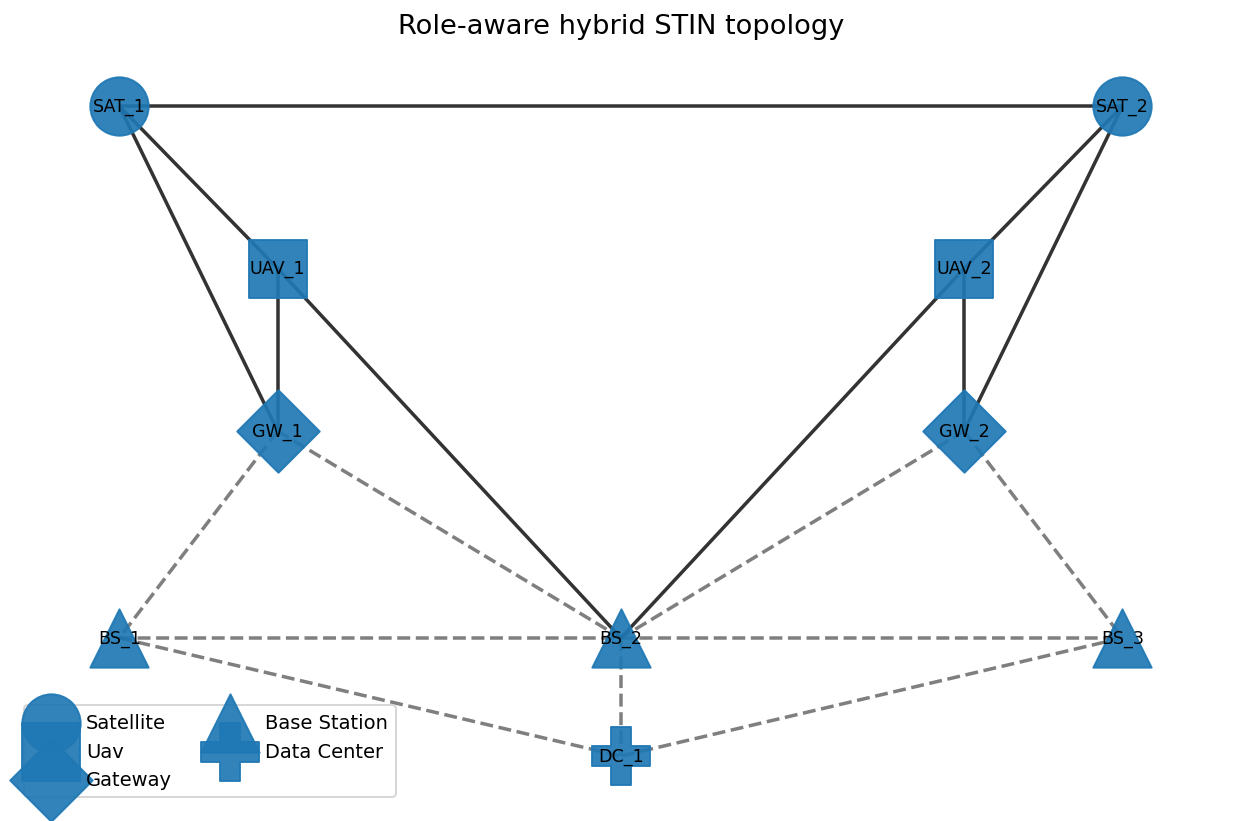

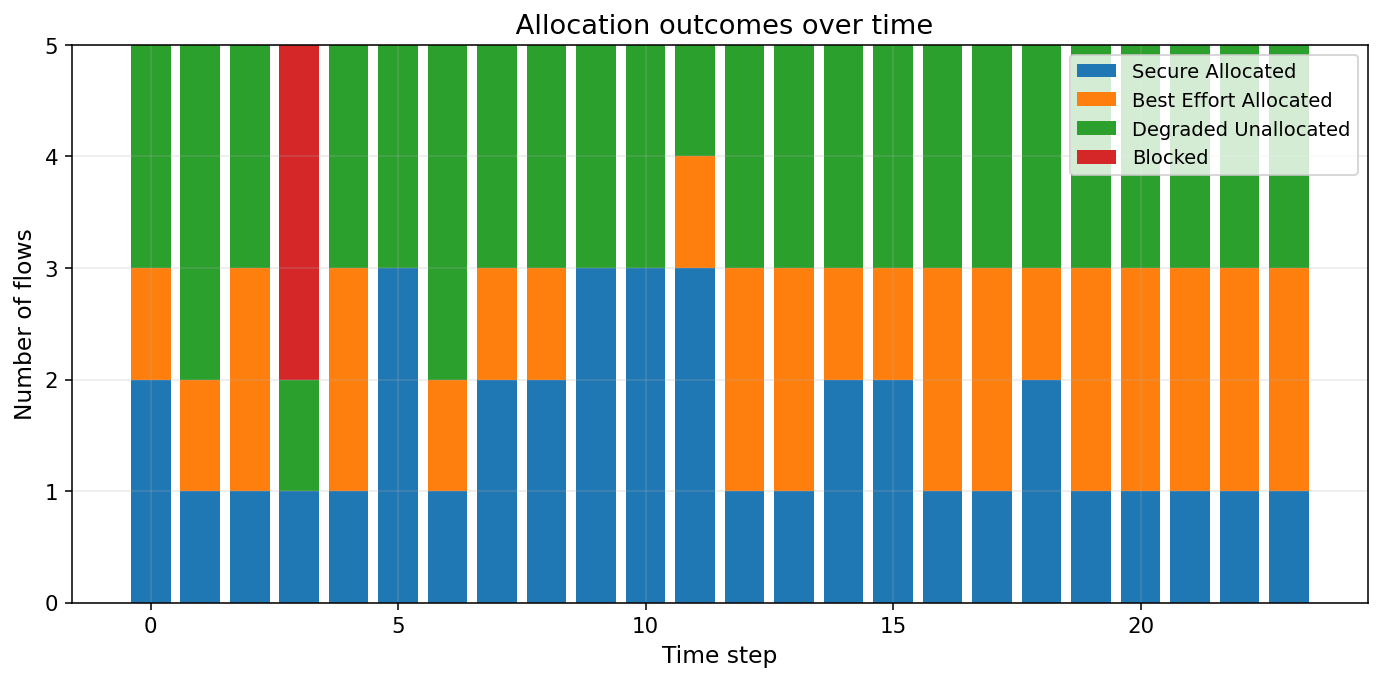

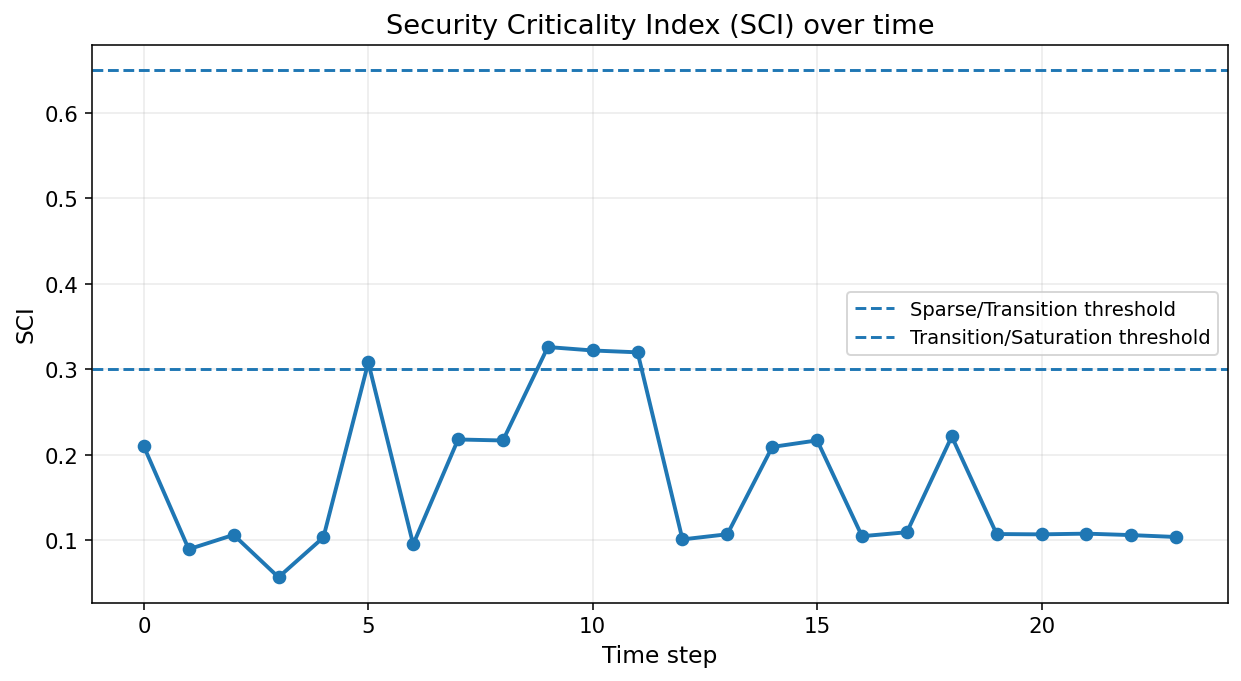

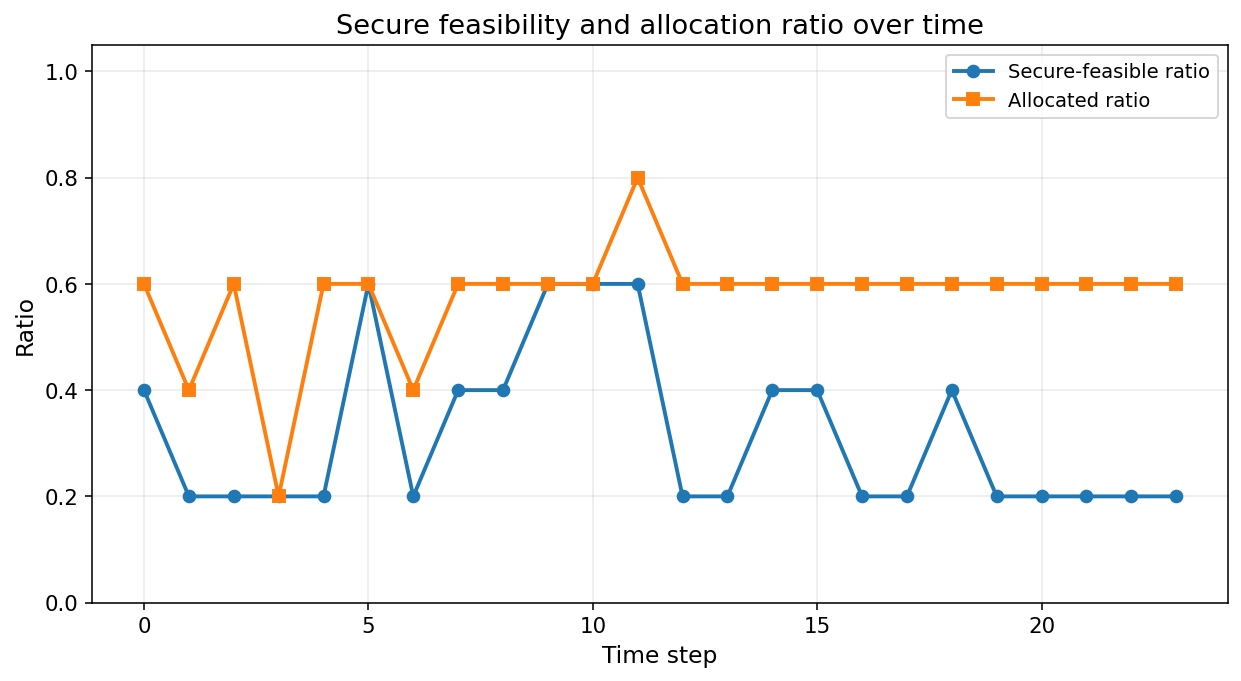

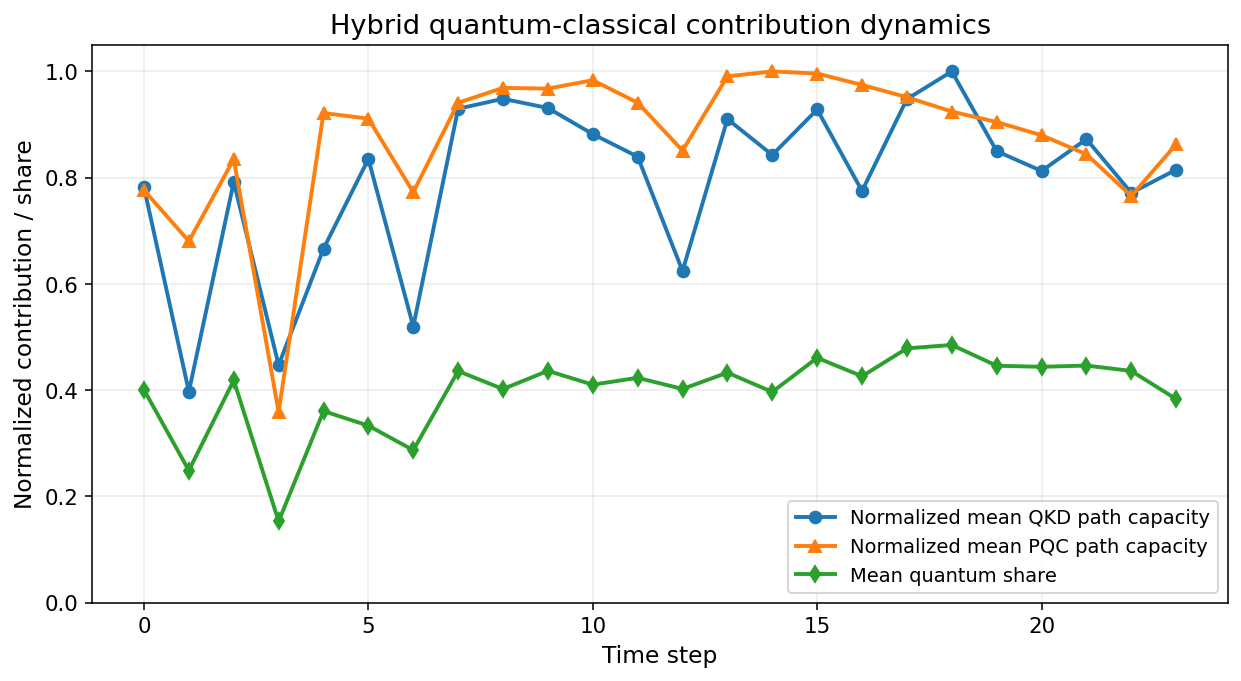

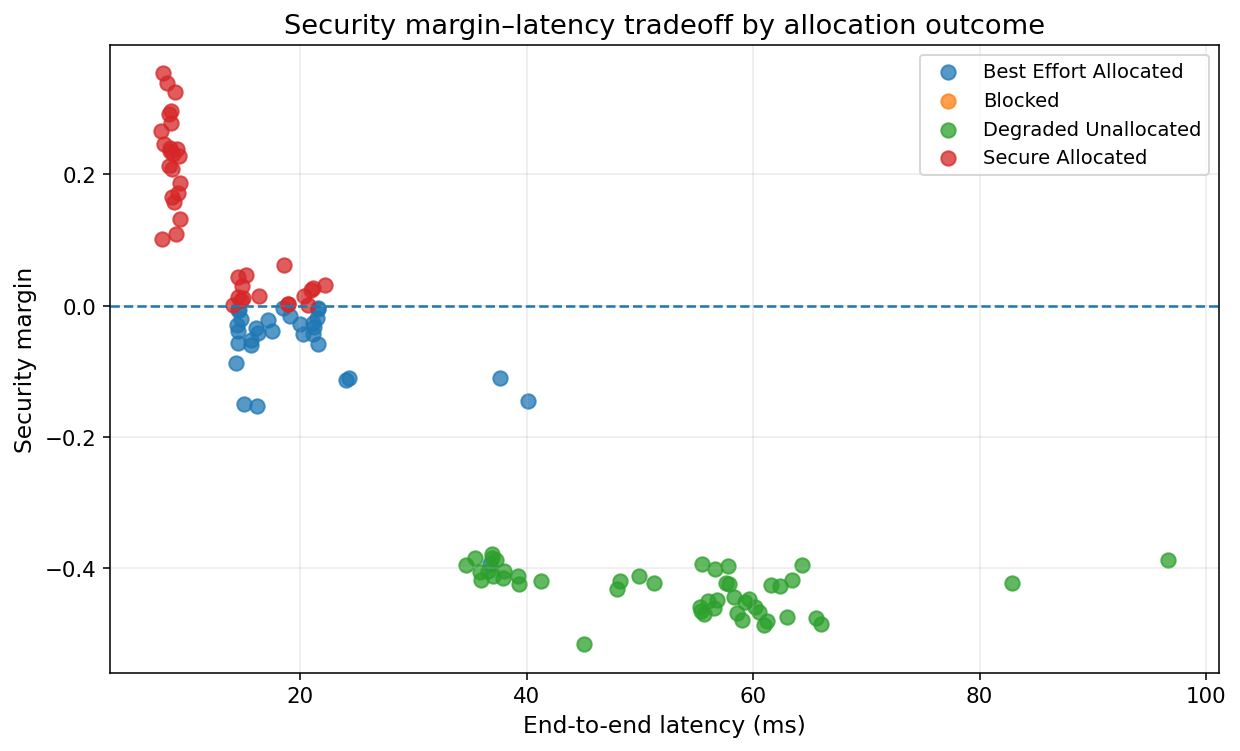

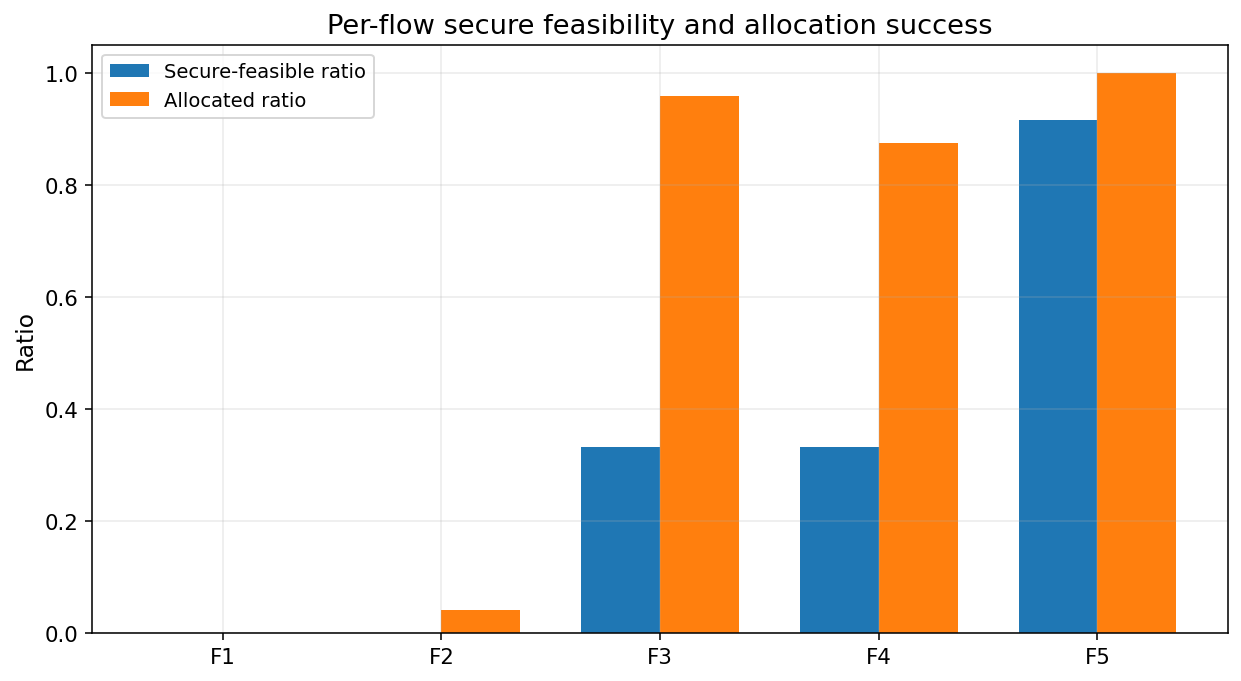

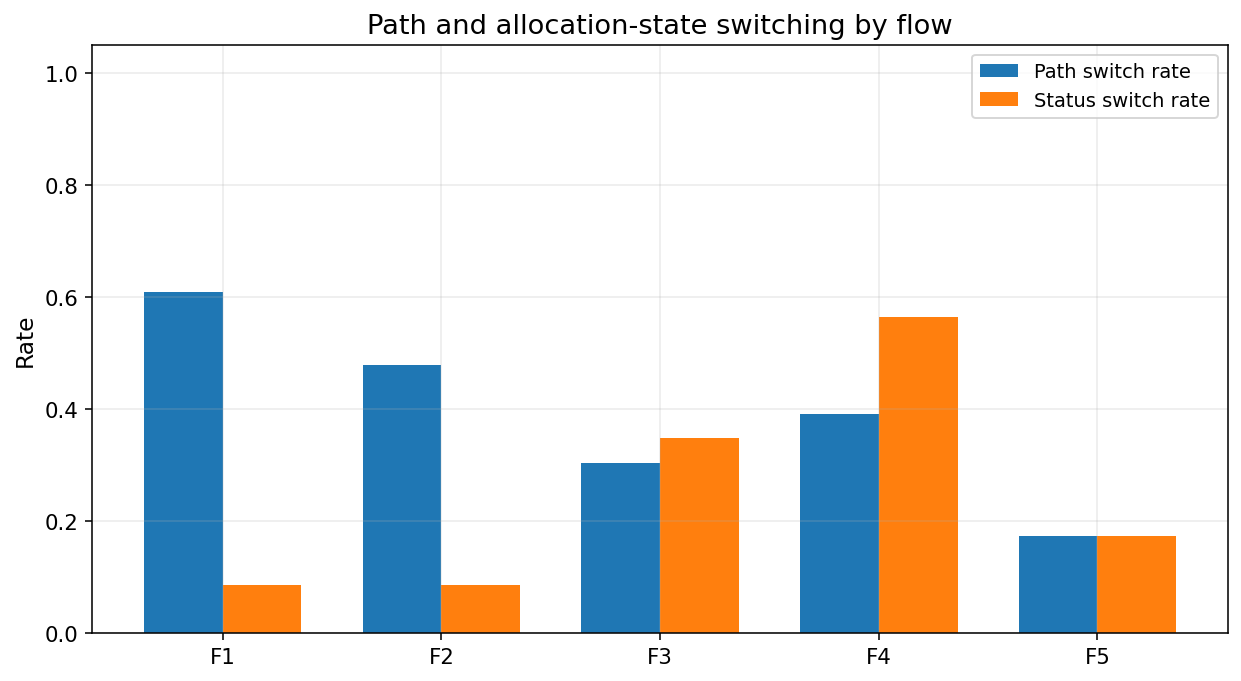

Saved figures:
- fig10_sci_over_time_by_method.png
- fig11_secure_feasible_ratio_by_method.png
- fig12_allocation_state_composition_by_method.png
- fig13_per_flow_security_margin_by_method.png
- fig14_latency_vs_quantum_share_by_method.png
- fig15_functional_score_by_method.png
- fig1_role_aware_topology.png
- fig2_allocation_outcomes_over_time.png
- fig3_sci_over_time.png
- fig4_secure_feasibility_and_allocation.png
- fig5_hybrid_contribution_dynamics.png
- fig6_security_margin_vs_latency.png
- fig7_per_flow_feasibility_and_allocation.png
- fig8_path_and_status_switching.png
- fig9_method_overall_comparison.png

Quantum-Secure 6G STIN Hybrid Allocation Prototype
Number of nodes: 10
Number of edges: 18
Number of flows: 5
Time steps: 24

Overall allocation-state counts:
- degraded_unallocated: 48
- secure_allocated: 38
- best_effort_allocated: 31
- blocked: 3

Overall regime counts:
- sparse: 20
- transition: 4

Flow-level summary:
- F1 (satellite_telemetry_backhaul): secure_feasible_ra

In [8]:
# -----------------------------
# Prepare figure-friendly data
# -----------------------------
time_df = summary_time.sort_values("time").reset_index(drop=True)
flow_df = summary_flow.sort_values("flow_id").reset_index(drop=True)
switch_df = path_stability_df.sort_values("flow_id").reset_index(drop=True)

status_order = ["secure_allocated", "best_effort_allocated", "degraded_unallocated", "blocked"]

status_time_df = (
    alloc_df.groupby(["time", "selection_status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=status_order, fill_value=0)
    .reset_index()
)

# Normalized contribution view for comparable plotting
time_df["mean_q_path_norm_plot"] = time_df["mean_q_path_raw"] / max(time_df["mean_q_path_raw"].max(), 1e-9)
time_df["mean_p_path_norm_plot"] = time_df["mean_p_path_raw"] / max(time_df["mean_p_path_raw"].max(), 1e-9)

# -----------------------------
# Figure 1 — Role-aware topology
# -----------------------------
plt.figure(figsize=(9, 6))
pos = {n: G.nodes[n]["pos"] for n in G.nodes()}

role_marker = {
    "satellite": "o",
    "uav": "s",
    "gateway": "D",
    "base_station": "^",
    "data_center": "P",
}
for role_name in ["satellite", "uav", "gateway", "base_station", "data_center"]:
    role_nodes = [n for n in G.nodes() if G.nodes[n]["role"] == role_name]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=role_nodes,
        node_shape=role_marker.get(role_name, "o"),
        label=role_name.replace("_", " ").title(),
        node_size=900,
        alpha=0.92
    )

qkd_edges = [(u, v) for u, v in G.edges() if G[u][v]["supports_qkd"]]
non_qkd_edges = [(u, v) for u, v in G.edges() if not G[u][v]["supports_qkd"]]

nx.draw_networkx_edges(G, pos, edgelist=qkd_edges, width=1.8, alpha=0.8)
nx.draw_networkx_edges(G, pos, edgelist=non_qkd_edges, width=1.8, alpha=0.5, style="dashed")
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Role-aware hybrid STIN topology")
plt.axis("off")
plt.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_role_aware_topology.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Allocation outcomes over time
# -----------------------------
plt.figure(figsize=(10, 5))
bottom = np.zeros(len(status_time_df))
for status in status_order:
    vals = status_time_df[status].values
    plt.bar(status_time_df["time"], vals, bottom=bottom, label=status.replace("_", " ").title())
    bottom = bottom + vals

plt.xlabel("Time step")
plt.ylabel("Number of flows")
plt.title(" Allocation outcomes over time")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_allocation_outcomes_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 3 — SCI with regime thresholds
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(time_df["time"], time_df["SCI"], marker="o", linewidth=2)
plt.axhline(0.30, linestyle="--", linewidth=1.5, label="Sparse/Transition threshold")
plt.axhline(0.65, linestyle="--", linewidth=1.5, label="Transition/Saturation threshold")
plt.xlabel("Time step")
plt.ylabel("SCI")
plt.title("Security Criticality Index (SCI) over time")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_sci_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 4 — Secure feasibility and allocation ratio
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(time_df["time"], time_df["secure_feasible_ratio"], marker="o", linewidth=2, label="Secure-feasible ratio")
plt.plot(time_df["time"], time_df["allocated_ratio"], marker="s", linewidth=2, label="Allocated ratio")
plt.xlabel("Time step")
plt.ylabel("Ratio")
plt.title("Secure feasibility and allocation ratio over time")
plt.ylim(0, 1.05)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_secure_feasibility_and_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 5 — Normalized QKD/PQC contribution and quantum share
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(time_df["time"], time_df["mean_q_path_norm_plot"], marker="o", linewidth=2, label="Normalized mean QKD path capacity")
plt.plot(time_df["time"], time_df["mean_p_path_norm_plot"], marker="^", linewidth=2, label="Normalized mean PQC path capacity")
plt.plot(time_df["time"], time_df["mean_q_share"], marker="d", linewidth=2, label="Mean quantum share")
plt.xlabel("Time step")
plt.ylabel("Normalized contribution / share")
plt.title("Hybrid quantum-classical contribution dynamics")
plt.ylim(0, 1.05)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_hybrid_contribution_dynamics.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 6 — Security margin vs latency by allocation state
# -----------------------------
plt.figure(figsize=(9, 5.5))
for status, grp in alloc_df.groupby("selection_status"):
    plt.scatter(
        grp["latency_path"],
        grp["security_margin"],
        s=55,
        alpha=0.75,
        label=status.replace("_", " ").title()
    )

plt.axhline(0.0, linestyle="--", linewidth=1.3)
plt.xlabel("End-to-end latency (ms)")
plt.ylabel("Security margin")
plt.title("Security margin–latency tradeoff by allocation outcome")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_security_margin_vs_latency.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 7 — Per-flow secure and allocated ratios
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(flow_df))
width = 0.36

ax.bar(x - width/2, flow_df["secure_feasible_ratio"], width, label="Secure-feasible ratio")
ax.bar(x + width/2, flow_df["allocated_ratio"], width, label="Allocated ratio")
ax.set_xticks(x)
ax.set_xticklabels(flow_df["flow_id"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Ratio")
ax.set_title("Per-flow secure feasibility and allocation success")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_per_flow_feasibility_and_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 8 — Path and status switching by flow
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(switch_df))
width = 0.36

ax.bar(x - width/2, switch_df["path_switch_rate"], width, label="Path switch rate")
ax.bar(x + width/2, switch_df["status_switch_rate"], width, label="Status switch rate")
ax.set_xticks(x)
ax.set_xticklabels(switch_df["flow_id"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate")
ax.set_title("Path and allocation-state switching by flow")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_path_and_status_switching.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Consolidated text summary
# -----------------------------
lines = []
lines.append("Quantum-Secure 6G STIN Hybrid Allocation Prototype")
lines.append("=" * 68)
lines.append(f"Number of nodes: {G.number_of_nodes()}")
lines.append(f"Number of edges: {G.number_of_edges()}")
lines.append(f"Number of flows: {len(flows)}")
lines.append(f"Time steps: {T}")
lines.append("")

lines.append("Overall allocation-state counts:")
for _, row in selection_status_counts.iterrows():
    lines.append(f"- {row['selection_status']}: {int(row['count'])}")

lines.append("")
lines.append("Overall regime counts:")
for _, row in regime_counts.iterrows():
    lines.append(f"- {row['regime']}: {int(row['count'])}")

lines.append("")
lines.append("Flow-level summary:")
for _, row in flow_df.iterrows():
    lines.append(
        f"- {row['flow_id']} ({row['mission']}): "
        f"secure_feasible_ratio={row['secure_feasible_ratio']:.3f}, "
        f"allocated_ratio={row['allocated_ratio']:.3f}, "
        f"avg_security_level={row['avg_security_level']:.4f}, "
        f"avg_security_margin={row['avg_security_margin']:.4f}, "
        f"avg_functional_score={row['avg_functional_score']:.4f}, "
        f"avg_q_share={row['avg_q_share']:.4f}, "
        f"avg_trust={row['avg_trust']:.4f}, "
        f"avg_risk={row['avg_risk']:.4f}, "
        f"avg_latency={row['avg_latency']:.2f}, "
        f"dominant_regime={row['dominant_regime']}, "
        f"dominant_selection_status={row['dominant_selection_status']}"
    )

lines.append("")
lines.append("Time-level summary:")
for _, row in time_df.iterrows():
    lines.append(
        f"- t={int(row['time'])}: "
        f"secure_allocated={int(row['secure_allocated_flows'])}, "
        f"best_effort={int(row['best_effort_flows'])}, "
        f"degraded={int(row['degraded_flows'])}, "
        f"blocked={int(row['blocked_flows'])}, "
        f"secure_feasible_ratio={row['secure_feasible_ratio']:.3f}, "
        f"allocated_ratio={row['allocated_ratio']:.3f}, "
        f"mean_security_margin={row['mean_security_margin']:.4f}, "
        f"mean_q_share={row['mean_q_share']:.4f}, "
        f"mean_risk={row['mean_risk']:.4f}, "
        f"SCI={row['SCI']:.5f}, "
        f"regime={row['regime']}"
    )

lines.append("")
lines.append("Path stability summary:")
for _, row in switch_df.iterrows():
    lines.append(
        f"- {row['flow_id']}: "
        f"path_switch_rate={row['path_switch_rate']:.3f}, "
        f"status_switch_rate={row['status_switch_rate']:.3f}, "
        f"unique_paths_used={int(row['unique_paths_used'])}, "
        f"blocked_fraction={row['blocked_fraction']:.3f}, "
        f"secure_fraction={row['secure_fraction']:.3f}"
    )

lines.append("")
lines.append("Exported figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    lines.append(f"- {fig_name}")

OUTPUTS_SUMMARY_PATH.write_text("\n".join(lines), encoding="utf-8")

print("Saved figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    print("-", fig_name)

print("")
print(OUTPUTS_SUMMARY_PATH.read_text(encoding="utf-8"))
print(f"[SAVED] {OUTPUTS_SUMMARY_PATH}")

## Cell 9 — Baseline routing/allocation methods and comparative evaluation

This cell adds comparative baselines to evaluate the proposed hybrid allocator against simpler decision rules. All methods operate on the same dynamic STIN state, the same ranked candidate paths, the same flow ordering, and the same shared-resource coupling model. The baselines include latency-first routing, PQC-trust-oriented routing, and QKD-priority routing. This enables method-wise comparison of secure-feasible ratio, allocation success, security margin, latency, quantum share, and SCI.

In [9]:
# -----------------------------
# Comparative baseline methods
# -----------------------------
METHODS = [
    "proposed_hybrid",
    "latency_first",
    "pqc_trust",
    "qkd_priority",
]

def strategy_score(candidate: dict, method_name: str) -> float:
    """
    Method-specific ranking score used inside the same feasibility hierarchy.
    Higher is better.
    """
    cost = communication_cost(
        latency_ms=0.0 if pd.isna(candidate["latency_path"]) else candidate["latency_path"],
        hop_count=0 if pd.isna(candidate["hop_count"]) else int(candidate["hop_count"])
    )

    if method_name == "proposed_hybrid":
        return float(candidate["functional_score"])

    if method_name == "latency_first":
        return float(
            -candidate["latency_path"]
            + 5.0 * candidate["trust_path"]
            - 2.0 * candidate["risk_path"]
        )

    if method_name == "pqc_trust":
        return float(
            0.60 * candidate["p_path_norm"]
            + 0.25 * candidate["trust_path"]
            - 0.15 * cost
        )

    if method_name == "qkd_priority":
        return float(
            0.45 * candidate["q_path_norm"]
            + 0.25 * candidate["q_share"]
            + 0.15 * candidate["trust_path"]
            - 0.15 * cost
        )

    raise ValueError(f"Unknown method: {method_name}")

def blocked_result(flow: dict, time_t: int, method_name: str) -> dict:
    return {
        "method": method_name,
        "time": time_t,
        "flow_id": flow["flow_id"],
        "mission": flow["mission"],
        "src": flow["src"],
        "dst": flow["dst"],
        "path": "BLOCKED",
        "hop_count": np.nan,
        "traffic_demand": flow["traffic_demand"],
        "key_demand": flow["key_demand"],
        "security_req": flow["security_req"],
        "priority": flow["priority"],
        "path_available": False,
        "service_feasible": False,
        "key_feasible": False,
        "resource_feasible": False,
        "secure_feasible": False,
        "functional_score": -1.0,
        "selection_score": -1.0,
        "q_path_raw": 0.0,
        "p_path_raw": 0.0,
        "q_path_norm": 0.0,
        "p_path_norm": 0.0,
        "q_share": 0.0,
        "trust_path": 0.0,
        "latency_path": np.nan,
        "risk_path": 1.0,
        "degradation_path": 1.0,
        "security_level": 0.0,
        "security_margin": -flow["security_req"],
        "service_deficit": 1.0,
        "key_deficit": 1.0,
        "qkd_edge_fraction": 0.0,
        "selection_status": "blocked",
        "allocated": False,
    }

def run_allocation_method(method_name: str) -> pd.DataFrame:
    method_results = []

    for t in range(T):
        residual_resources = initialize_residual_resources(t)

        for flow in flow_order_template:
            evaluated_candidates = []

            for path in candidate_paths[flow["flow_id"]]:
                candidate = evaluate_path_at_time(
                    path=path,
                    time_t=t,
                    residual_resources=residual_resources,
                    flow=flow
                )
                candidate["method"] = method_name
                candidate["selection_score"] = strategy_score(candidate, method_name)
                evaluated_candidates.append(candidate)

            secure_candidates = [c for c in evaluated_candidates if c["secure_feasible"]]
            best_effort_candidates = [c for c in evaluated_candidates if c["resource_feasible"] and not c["secure_feasible"]]
            degraded_candidates = [c for c in evaluated_candidates if c["path_available"] and not c["resource_feasible"]]

            if secure_candidates:
                selected = max(secure_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "secure_allocated"
                selected["allocated"] = True
                consume_resources_for_selected_path(selected["path"], t, residual_resources, flow)

            elif best_effort_candidates:
                selected = max(best_effort_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "best_effort_allocated"
                selected["allocated"] = True
                consume_resources_for_selected_path(selected["path"], t, residual_resources, flow)

            elif degraded_candidates:
                selected = max(degraded_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "degraded_unallocated"
                selected["allocated"] = False

            else:
                selected = blocked_result(flow, t, method_name)

            method_results.append(selected)

    method_df = pd.DataFrame(method_results)

    # Method-specific SCI
    method_time = method_df.groupby(["method", "time"]).agg(
        secure_feasible_ratio=("secure_feasible", "mean"),
        allocated_ratio=("allocated", "mean"),
        mean_security_margin=("security_margin", "mean"),
        mean_q_share=("q_share", "mean"),
        mean_risk=("risk_path", "mean"),
        mean_latency=("latency_path", "mean"),
        mean_functional_score=("functional_score", "mean"),
    ).reset_index()

    method_time["SCI"] = method_time.apply(
        lambda r: security_criticality_index(
            feasible_ratio=r["secure_feasible_ratio"],
            mean_security_margin=r["mean_security_margin"],
            mean_q_share=r["mean_q_share"],
            mean_risk=r["mean_risk"],
        ),
        axis=1
    )
    method_time["regime"] = method_time["SCI"].apply(classify_security_regime)

    method_df = method_df.merge(
        method_time[["method", "time", "SCI", "regime", "secure_feasible_ratio", "allocated_ratio"]],
        on=["method", "time"],
        how="left"
    )

    return method_df

# -----------------------------
# Run all methods
# -----------------------------
comparison_alloc_df = pd.concat(
    [run_allocation_method(method_name) for method_name in METHODS],
    ignore_index=True
)

# -----------------------------
# Method-level summaries
# -----------------------------
method_summary = comparison_alloc_df.groupby("method").agg(
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    avg_security_level=("security_level", "mean"),
    avg_security_margin=("security_margin", "mean"),
    avg_functional_score=("functional_score", "mean"),
    avg_q_share=("q_share", "mean"),
    avg_risk=("risk_path", "mean"),
    avg_latency=("latency_path", "mean"),
    avg_SCI=("SCI", "mean"),
).reset_index()

method_status_summary = (
    comparison_alloc_df.groupby(["method", "selection_status"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["method", "selection_status"])
)

method_regime_summary = (
    comparison_alloc_df.groupby(["method", "regime"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["method", "regime"])
)

method_flow_summary = comparison_alloc_df.groupby(["method", "flow_id"]).agg(
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    avg_security_margin=("security_margin", "mean"),
    avg_latency=("latency_path", "mean"),
    avg_q_share=("q_share", "mean"),
).reset_index()

method_time_summary = comparison_alloc_df.groupby(["method", "time"]).agg(
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    mean_security_margin=("security_margin", "mean"),
    mean_latency=("latency_path", "mean"),
    mean_q_share=("q_share", "mean"),
    SCI=("SCI", "mean"),
).reset_index()

# -----------------------------
# Save comparison tables
# -----------------------------
comparison_alloc_df.to_csv(TAB_DIR / "comparison_allocation_decisions.csv", index=False)
method_summary.to_csv(TAB_DIR / "comparison_method_summary.csv", index=False)
method_status_summary.to_csv(TAB_DIR / "comparison_method_status_summary.csv", index=False)
method_regime_summary.to_csv(TAB_DIR / "comparison_method_regime_summary.csv", index=False)
method_flow_summary.to_csv(TAB_DIR / "comparison_method_flow_summary.csv", index=False)
method_time_summary.to_csv(TAB_DIR / "comparison_method_time_summary.csv", index=False)

# -----------------------------
# Display
# -----------------------------
display(method_summary)
display(method_status_summary)
display(method_regime_summary)
display(method_flow_summary.head(20))

print(f"[SAVED] {TAB_DIR / 'comparison_allocation_decisions.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_method_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_method_status_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_method_regime_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_method_flow_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_method_time_summary.csv'}")

,method,secure_feasible_ratio,allocated_ratio,avg_security_level,avg_security_margin,avg_functional_score,avg_q_share,avg_risk,avg_latency,avg_SCI
0,latency_first,0.316667,0.575,0.327449,-0.168551,-0.159726,0.328739,0.245758,28.610723,0.158852
1,pqc_trust,0.316667,0.575,0.318739,-0.177261,-0.182264,0.283332,0.246594,31.599330,0.155638
2,proposed_hybrid,0.316667,0.575,0.339296,-0.156704,-0.133093,0.397791,0.242165,31.109488,0.165698
3,qkd_priority,0.300000,0.575,0.304232,-0.191768,-0.187230,0.419561,0.245778,33.649970,0.155980


,method,selection_status,count
0,latency_first,best_effort_allocated,31
1,latency_first,blocked,3
2,latency_first,degraded_unallocated,48
3,latency_first,secure_allocated,38
4,pqc_trust,best_effort_allocated,31
5,pqc_trust,blocked,3
6,pqc_trust,degraded_unallocated,48
7,pqc_trust,secure_allocated,38
8,proposed_hybrid,best_effort_allocated,31
9,proposed_hybrid,blocked,3


,method,regime,count
0,latency_first,sparse,105
1,latency_first,transition,15
2,pqc_trust,sparse,100
3,pqc_trust,transition,20
4,proposed_hybrid,sparse,100
5,proposed_hybrid,transition,20
6,qkd_priority,sparse,100
7,qkd_priority,transition,20


,method,flow_id,secure_feasible_ratio,allocated_ratio,avg_security_margin,avg_latency,avg_q_share
0,latency_first,F1,0.000000,0.000000,-0.513483,49.305813,0.057642
1,latency_first,F2,0.000000,0.041667,-0.416927,41.610023,0.338189
2,latency_first,F3,0.333333,0.958333,-0.047134,16.034478,0.292381
3,latency_first,F4,0.333333,0.875000,-0.067206,27.270080,0.466896
4,latency_first,F5,0.916667,1.000000,0.201995,9.115646,0.488585
5,pqc_trust,F1,0.000000,0.000000,-0.519118,50.400628,0.013751
6,pqc_trust,F2,0.000000,0.041667,-0.433584,51.432918,0.198245
7,pqc_trust,F3,0.333333,0.958333,-0.045496,16.042951,0.291377
8,pqc_trust,F4,0.333333,0.875000,-0.084834,30.734280,0.429182
9,pqc_trust,F5,0.916667,1.000000,0.196728,9.485037,0.484106


[SAVED] Outputs\quantum_secure_comm\tables\comparison_allocation_decisions.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_status_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_regime_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_flow_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_time_summary.csv


## Cell 10 — Comparative figures for baseline evaluation

This cell generates manuscript-oriented comparison figures across the proposed hybrid allocator and the baseline methods. The plots summarize overall method performance, time-varying SCI, security-feasible ratio, allocation-state composition, per-flow security margin, and the latency–quantum-share tradeoff. These figures are intended to support the central comparative claims of the paper.

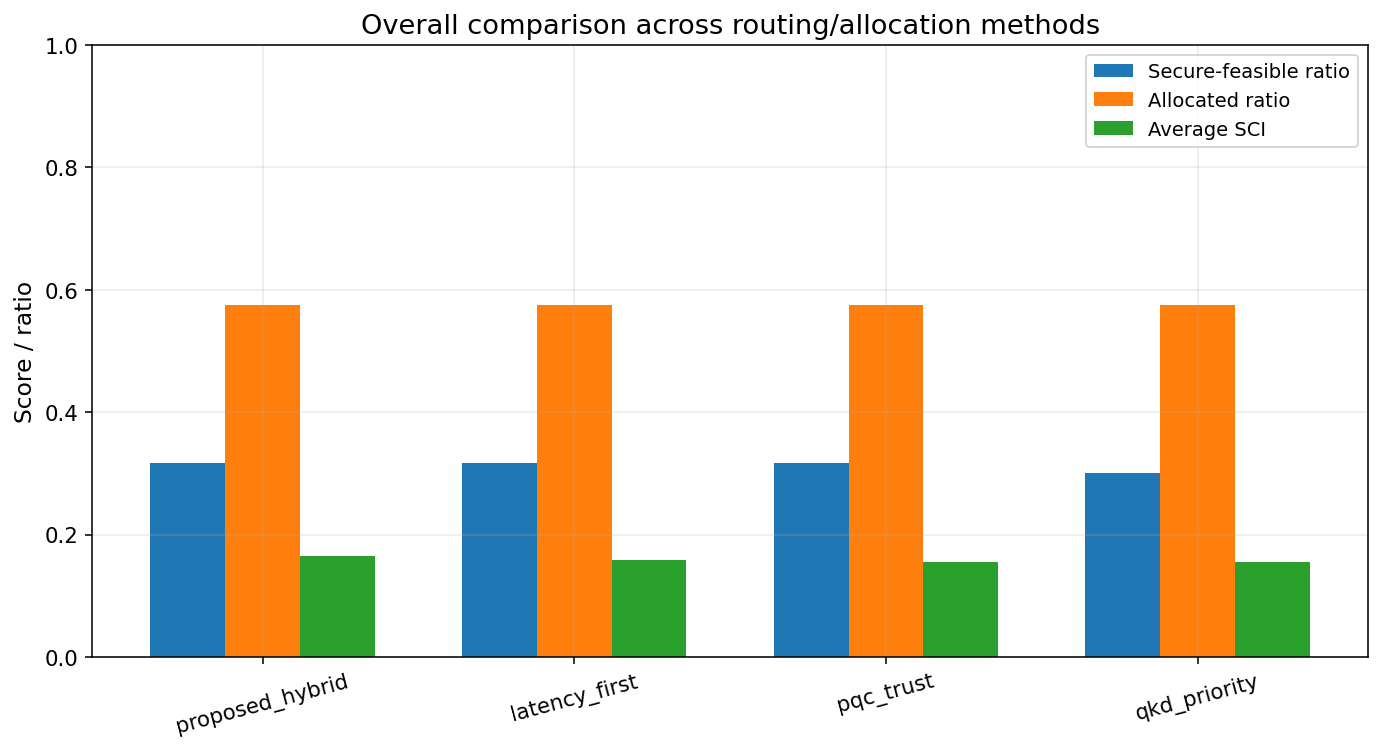

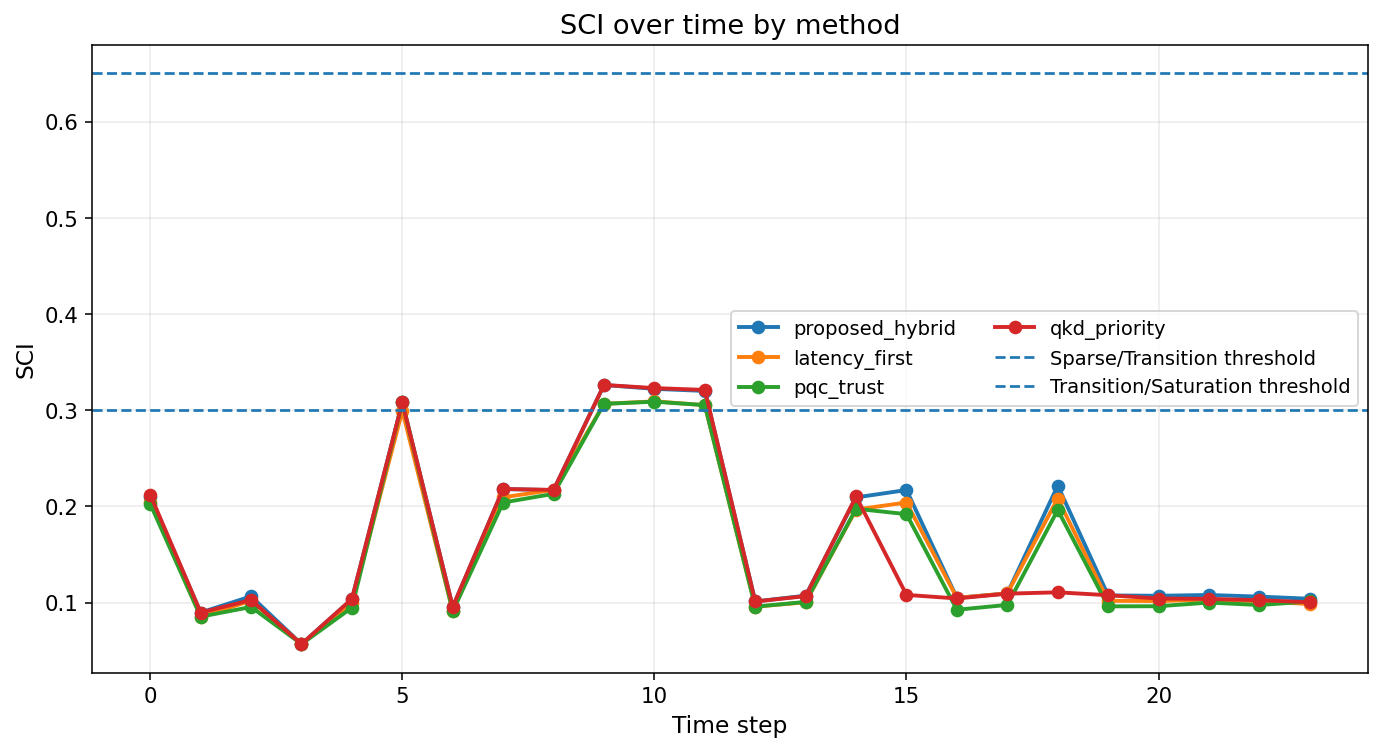

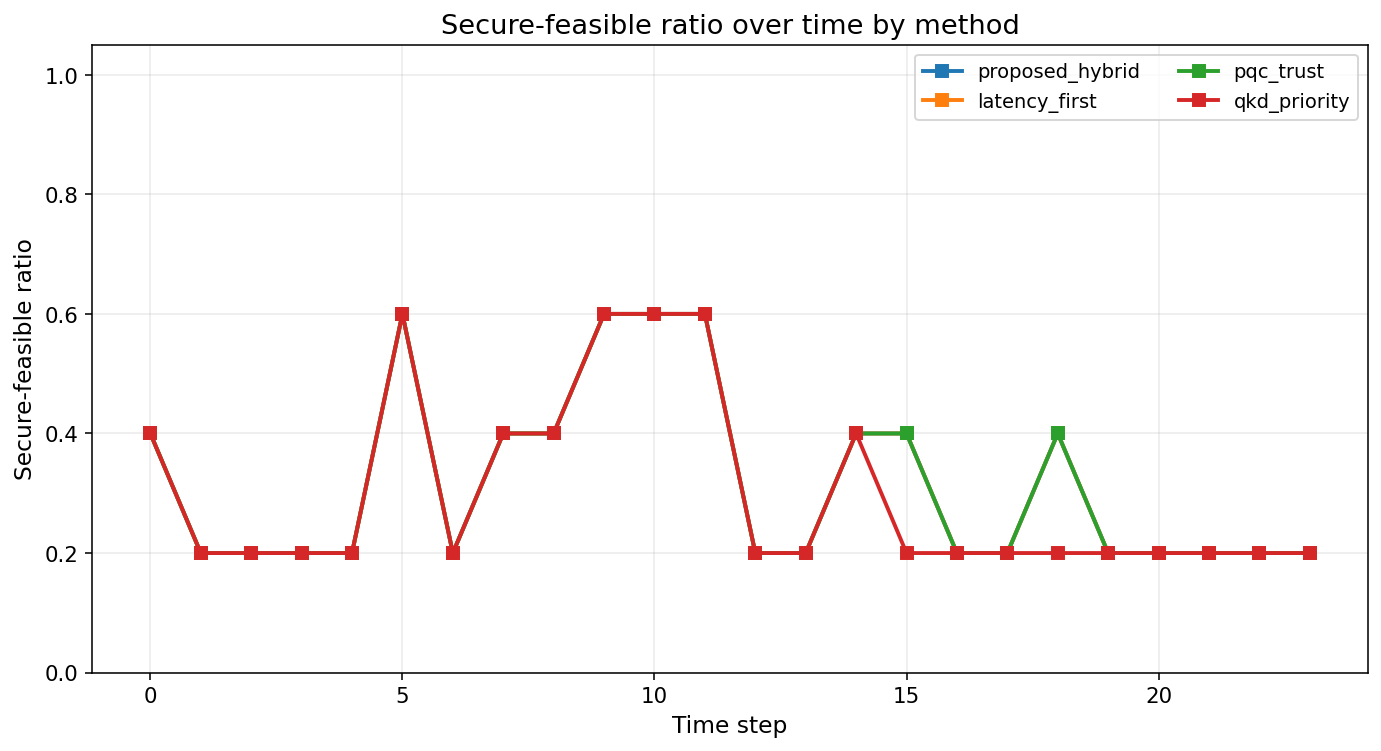

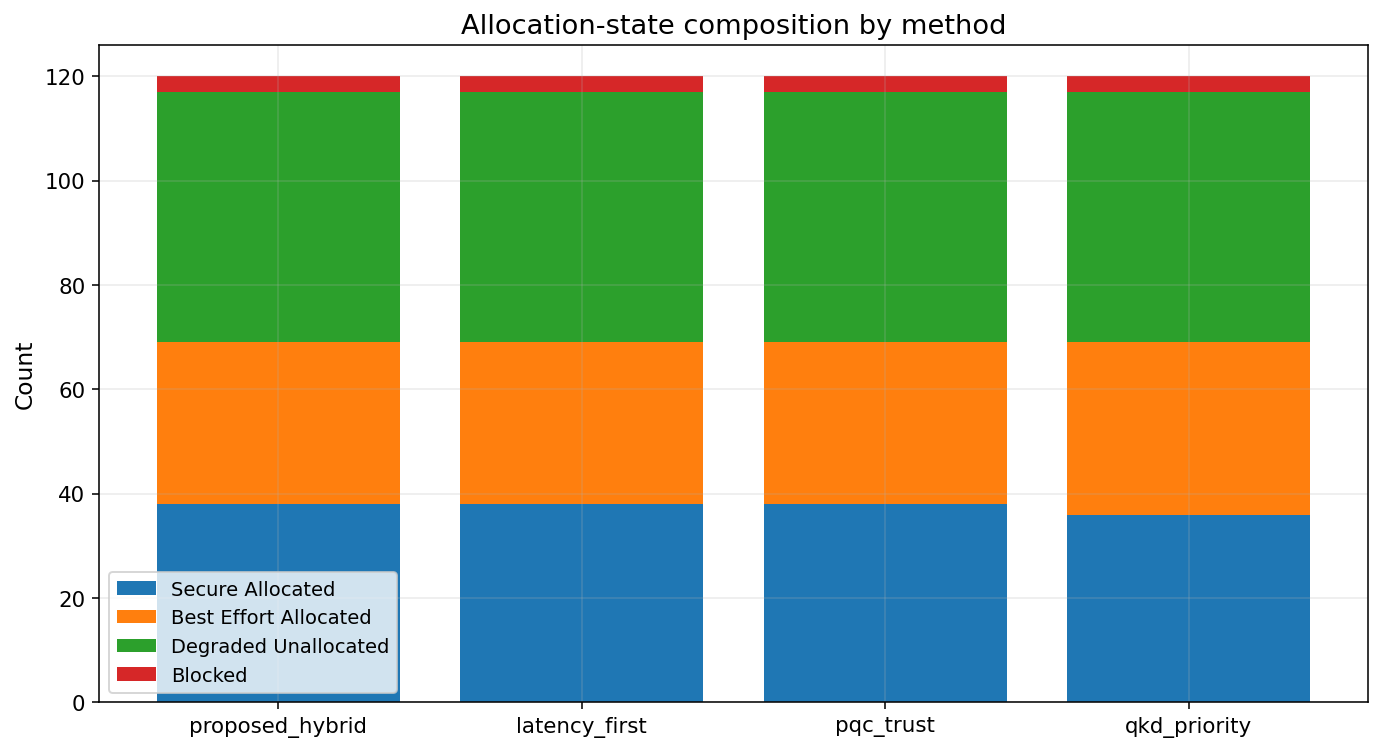

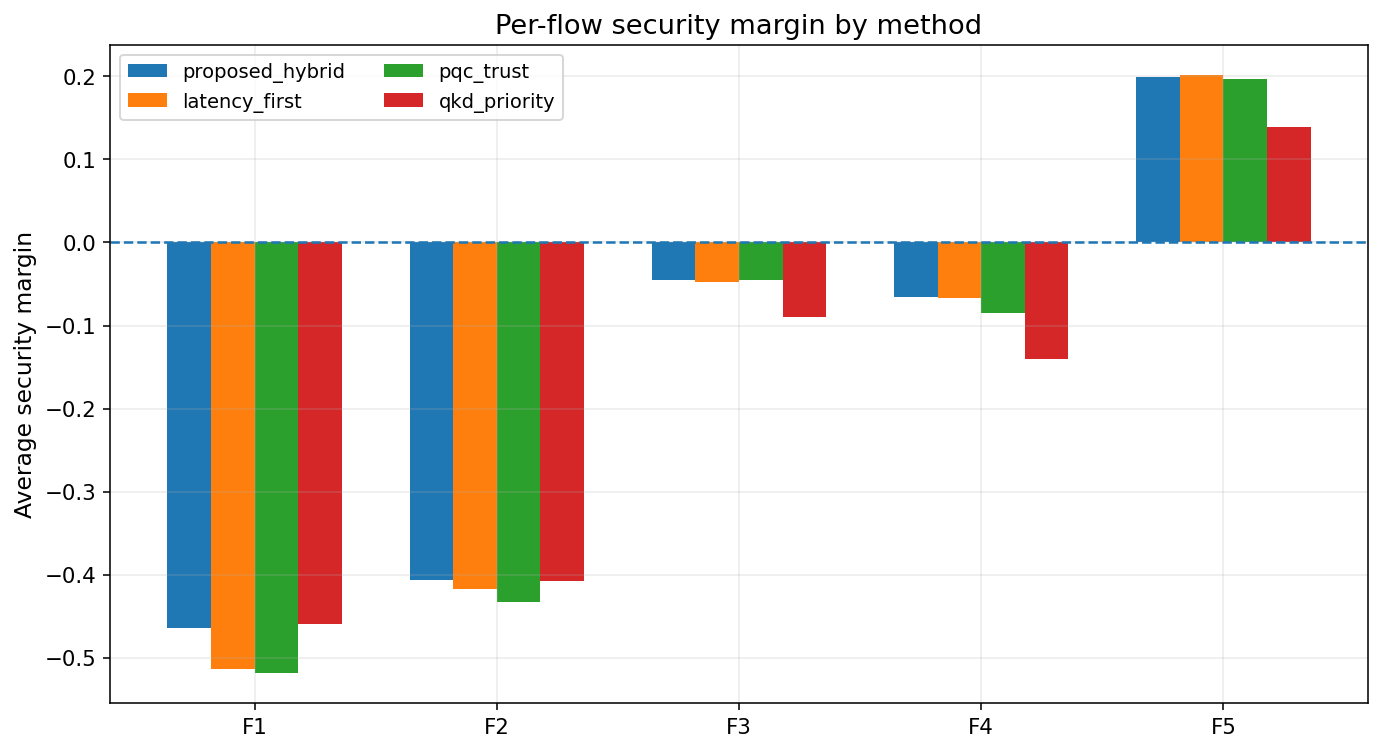

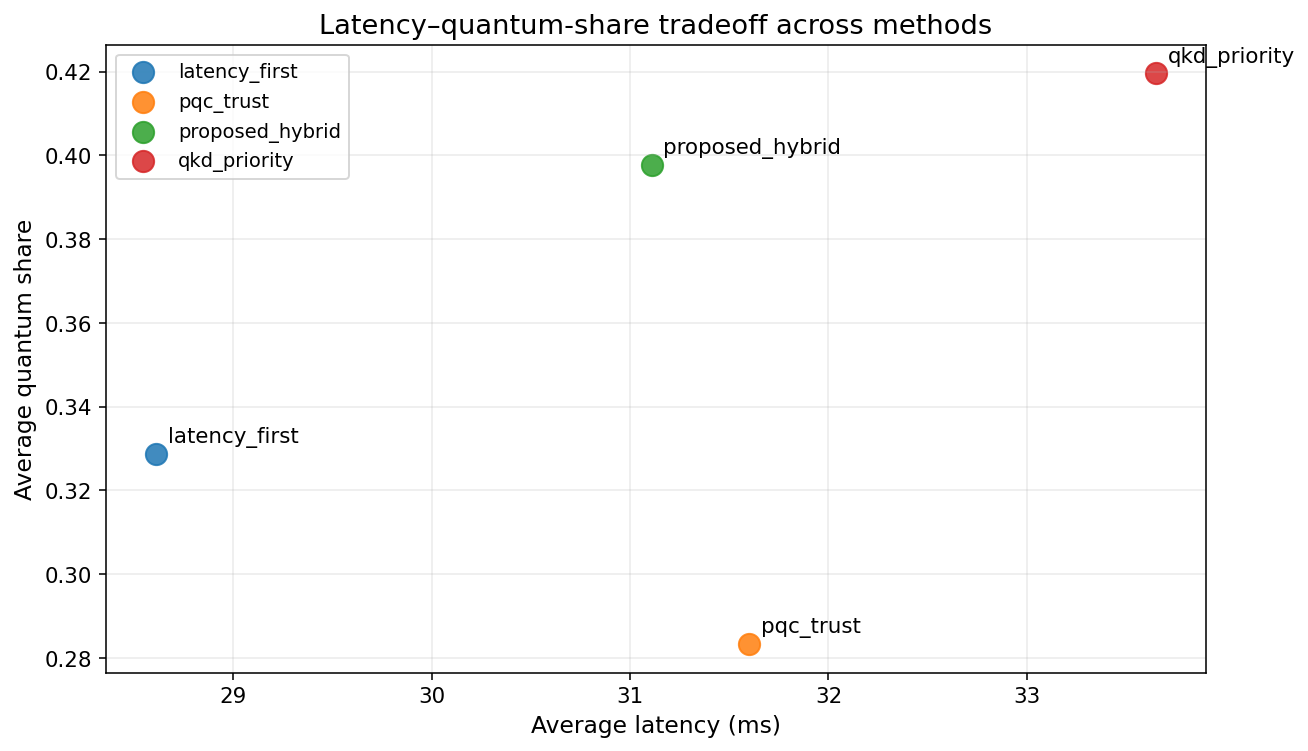

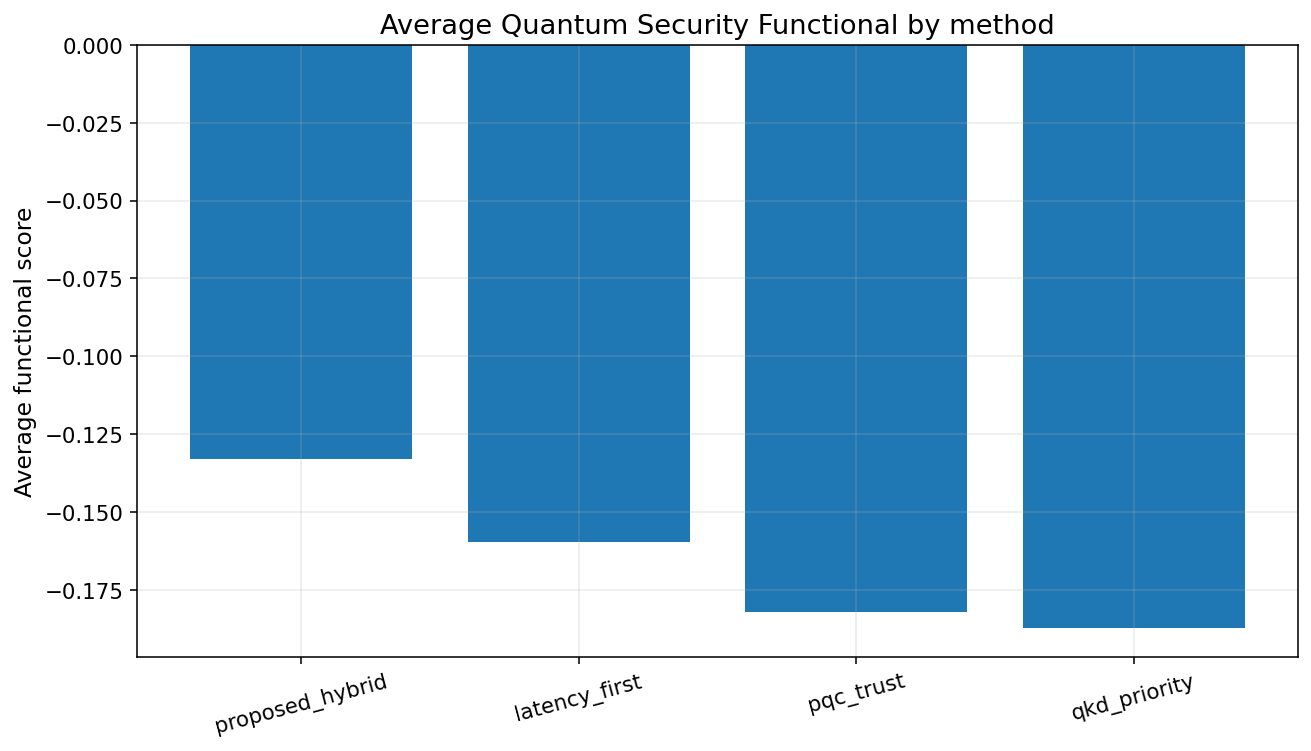

Saved comparative figures:
- fig10_sci_over_time_by_method.png
- fig11_secure_feasible_ratio_by_method.png
- fig12_allocation_state_composition_by_method.png
- fig13_per_flow_security_margin_by_method.png
- fig14_latency_vs_quantum_share_by_method.png
- fig15_functional_score_by_method.png
- fig9_method_overall_comparison.png


In [10]:
# -----------------------------
# Figure-friendly comparative data
# -----------------------------
method_order = ["proposed_hybrid", "latency_first", "pqc_trust", "qkd_priority"]

method_summary_plot = (
    method_summary.set_index("method")
    .loc[method_order]
    .reset_index()
)

method_time_plot = (
    method_time_summary.copy()
    .assign(method=lambda df: pd.Categorical(df["method"], categories=method_order, ordered=True))
    .sort_values(["method", "time"])
)

method_flow_plot = (
    method_flow_summary.copy()
    .assign(method=lambda df: pd.Categorical(df["method"], categories=method_order, ordered=True))
    .sort_values(["flow_id", "method"])
)

method_status_pivot = (
    method_status_summary.pivot(index="method", columns="selection_status", values="count")
    .fillna(0)
    .reindex(method_order)
)

# Ensure all status columns exist
for c in ["secure_allocated", "best_effort_allocated", "degraded_unallocated", "blocked"]:
    if c not in method_status_pivot.columns:
        method_status_pivot[c] = 0
method_status_pivot = method_status_pivot[["secure_allocated", "best_effort_allocated", "degraded_unallocated", "blocked"]]

# -----------------------------
# Figure 9 — Overall method comparison
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(method_summary_plot))
width = 0.24

ax.bar(x - width, method_summary_plot["secure_feasible_ratio"], width, label="Secure-feasible ratio")
ax.bar(x, method_summary_plot["allocated_ratio"], width, label="Allocated ratio")
ax.bar(x + width, method_summary_plot["avg_SCI"], width, label="Average SCI")

ax.set_xticks(x)
ax.set_xticklabels(method_summary_plot["method"], rotation=15)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score / ratio")
ax.set_title("Overall comparison across routing/allocation methods")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_method_overall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 10 — SCI over time by method
# -----------------------------
plt.figure(figsize=(10, 5.5))
for method_name, grp in method_time_plot.groupby("method"):
    plt.plot(grp["time"], grp["SCI"], marker="o", linewidth=2, label=method_name)

plt.axhline(0.30, linestyle="--", linewidth=1.4, label="Sparse/Transition threshold")
plt.axhline(0.65, linestyle="--", linewidth=1.4, label="Transition/Saturation threshold")
plt.xlabel("Time step")
plt.ylabel("SCI")
plt.title("SCI over time by method")
plt.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_sci_over_time_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 11 — Secure-feasible ratio over time by method
# -----------------------------
plt.figure(figsize=(10, 5.5))
for method_name, grp in method_time_plot.groupby("method"):
    plt.plot(grp["time"], grp["secure_feasible_ratio"], marker="s", linewidth=2, label=method_name)

plt.xlabel("Time step")
plt.ylabel("Secure-feasible ratio")
plt.ylim(0, 1.05)
plt.title("Secure-feasible ratio over time by method")
plt.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_secure_feasible_ratio_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 12 — Allocation-state composition by method
# -----------------------------
plt.figure(figsize=(10, 5.5))
bottom = np.zeros(len(method_status_pivot))

for status in ["secure_allocated", "best_effort_allocated", "degraded_unallocated", "blocked"]:
    vals = method_status_pivot[status].values
    plt.bar(method_status_pivot.index, vals, bottom=bottom, label=status.replace("_", " ").title())
    bottom = bottom + vals

plt.ylabel("Count")
plt.title("Allocation-state composition by method")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_allocation_state_composition_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 13 — Per-flow security margin by method
# -----------------------------
flow_ids = sorted(method_flow_plot["flow_id"].unique())
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(flow_ids))
width = 0.18

for i, method_name in enumerate(method_order):
    subset = (
        method_flow_plot[method_flow_plot["method"] == method_name]
        .set_index("flow_id")
        .reindex(flow_ids)
        .reset_index()
    )
    ax.bar(
        x + (i - 1.5) * width,
        subset["avg_security_margin"],
        width,
        label=method_name
    )

ax.axhline(0.0, linestyle="--", linewidth=1.3)
ax.set_xticks(x)
ax.set_xticklabels(flow_ids)
ax.set_ylabel("Average security margin")
ax.set_title("Per-flow security margin by method")
ax.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig13_per_flow_security_margin_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 14 — Latency vs quantum-share comparison
# -----------------------------
plt.figure(figsize=(9.5, 5.5))
for method_name, grp in method_summary_plot.groupby("method"):
    plt.scatter(
        grp["avg_latency"],
        grp["avg_q_share"],
        s=120,
        alpha=0.85,
        label=method_name
    )

for _, row in method_summary_plot.iterrows():
    plt.annotate(
        row["method"],
        (row["avg_latency"], row["avg_q_share"]),
        textcoords="offset points",
        xytext=(6, 6)
    )

plt.xlabel("Average latency (ms)")
plt.ylabel("Average quantum share")
plt.title("Latency–quantum-share tradeoff across methods")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_latency_vs_quantum_share_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 15 — Functional score by method
# -----------------------------
plt.figure(figsize=(9.5, 5.5))
plt.bar(method_summary_plot["method"], method_summary_plot["avg_functional_score"])
plt.ylabel("Average functional score")
plt.title("Average Quantum Security Functional by method")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_functional_score_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparative figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    if fig_name.startswith("fig9_") or fig_name.startswith("fig10_") or fig_name.startswith("fig11_") or fig_name.startswith("fig12_") or fig_name.startswith("fig13_") or fig_name.startswith("fig14_") or fig_name.startswith("fig15_"):
        print("-", fig_name)

## Cell 11 — Comparative summary tables and manuscript-claim extraction

This cell consolidates the method comparison results into manuscript-oriented summary tables. It computes rankings, relative improvements against baseline methods, per-time-step win counts, and candidate claim statements grounded in the simulation outputs. The goal is to convert the raw comparison results into interpretable evidence that can later be used in the paper’s results and discussion sections.

In [11]:
# -----------------------------
# Comparative summary tables
# -----------------------------
method_rank_table = method_summary.copy()

# Ranking directions:
# higher is better for:
# - secure_feasible_ratio
# - allocated_ratio
# - avg_security_level
# - avg_security_margin
# - avg_functional_score
# - avg_q_share
# - avg_SCI
# lower is better for:
# - avg_risk
# - avg_latency

higher_better_cols = [
    "secure_feasible_ratio",
    "allocated_ratio",
    "avg_security_level",
    "avg_security_margin",
    "avg_functional_score",
    "avg_q_share",
    "avg_SCI",
]
lower_better_cols = [
    "avg_risk",
    "avg_latency",
]

for col in higher_better_cols:
    method_rank_table[f"rank_{col}"] = method_rank_table[col].rank(ascending=False, method="min")

for col in lower_better_cols:
    method_rank_table[f"rank_{col}"] = method_rank_table[col].rank(ascending=True, method="min")

rank_cols = [c for c in method_rank_table.columns if c.startswith("rank_")]
method_rank_table["mean_rank"] = method_rank_table[rank_cols].mean(axis=1)
method_rank_table = method_rank_table.sort_values("mean_rank").reset_index(drop=True)

# -----------------------------
# Relative improvement of proposed method vs baselines
# -----------------------------
proposed_row = method_summary[method_summary["method"] == "proposed_hybrid"].iloc[0]

improvement_records = []
for baseline in ["latency_first", "pqc_trust", "qkd_priority"]:
    base_row = method_summary[method_summary["method"] == baseline].iloc[0]

    improvement_records.append({
        "baseline_method": baseline,
        "delta_secure_feasible_ratio": proposed_row["secure_feasible_ratio"] - base_row["secure_feasible_ratio"],
        "delta_allocated_ratio": proposed_row["allocated_ratio"] - base_row["allocated_ratio"],
        "delta_avg_security_margin": proposed_row["avg_security_margin"] - base_row["avg_security_margin"],
        "delta_avg_functional_score": proposed_row["avg_functional_score"] - base_row["avg_functional_score"],
        "delta_avg_q_share": proposed_row["avg_q_share"] - base_row["avg_q_share"],
        "delta_avg_risk": proposed_row["avg_risk"] - base_row["avg_risk"],
        "delta_avg_latency": proposed_row["avg_latency"] - base_row["avg_latency"],
        "delta_avg_SCI": proposed_row["avg_SCI"] - base_row["avg_SCI"],
    })

improvement_df = pd.DataFrame(improvement_records)

# -----------------------------
# Time-step winners by metric
# -----------------------------
time_metric_wins = []

metrics_for_wins = {
    "SCI": "max",
    "secure_feasible_ratio": "max",
    "allocated_ratio": "max",
    "mean_security_margin": "max",
    "mean_latency": "min",
    "mean_q_share": "max",
}

for metric_name, direction in metrics_for_wins.items():
    for t, grp in method_time_summary.groupby("time"):
        if direction == "max":
            best_val = grp[metric_name].max()
            winners = grp.loc[np.isclose(grp[metric_name], best_val), "method"].tolist()
        else:
            best_val = grp[metric_name].min()
            winners = grp.loc[np.isclose(grp[metric_name], best_val), "method"].tolist()

        for w in winners:
            time_metric_wins.append({
                "time": t,
                "metric": metric_name,
                "winner_method": w,
                "winning_value": best_val,
            })

time_metric_wins_df = pd.DataFrame(time_metric_wins)

time_metric_win_counts = (
    time_metric_wins_df.groupby(["metric", "winner_method"])
    .size()
    .rename("win_count")
    .reset_index()
    .sort_values(["metric", "win_count"], ascending=[True, False])
)

# -----------------------------
# Per-flow best method table
# -----------------------------
flow_best_records = []
for flow_id, grp in method_flow_summary.groupby("flow_id"):
    best_margin_row = grp.loc[grp["avg_security_margin"].idxmax()]
    best_latency_row = grp.loc[grp["avg_latency"].idxmin()]
    best_qshare_row = grp.loc[grp["avg_q_share"].idxmax()]
    best_secure_row = grp.loc[grp["secure_feasible_ratio"].idxmax()]

    flow_best_records.append({
        "flow_id": flow_id,
        "best_security_margin_method": best_margin_row["method"],
        "best_security_margin_value": best_margin_row["avg_security_margin"],
        "best_latency_method": best_latency_row["method"],
        "best_latency_value": best_latency_row["avg_latency"],
        "best_q_share_method": best_qshare_row["method"],
        "best_q_share_value": best_qshare_row["avg_q_share"],
        "best_secure_feasible_method": best_secure_row["method"],
        "best_secure_feasible_value": best_secure_row["secure_feasible_ratio"],
    })

flow_best_method_df = pd.DataFrame(flow_best_records)

# -----------------------------
# Candidate manuscript claims (data-grounded)
# -----------------------------
claims = []

best_overall_method = method_rank_table.iloc[0]["method"]
claims.append(
    f"Overall multi-metric ranking places '{best_overall_method}' first with mean rank "
    f"{method_rank_table.iloc[0]['mean_rank']:.2f}."
)

for _, row in improvement_df.iterrows():
    baseline = row["baseline_method"]
    claims.append(
        f"Against '{baseline}', the proposed_hybrid method changes average SCI by "
        f"{row['delta_avg_SCI']:+.4f}, average security margin by "
        f"{row['delta_avg_security_margin']:+.4f}, and average latency by "
        f"{row['delta_avg_latency']:+.4f} ms."
    )

# Add one clear tradeoff claim for qkd_priority
qkd_row = method_summary[method_summary["method"] == "qkd_priority"].iloc[0]
lat_row = method_summary[method_summary["method"] == "latency_first"].iloc[0]
claims.append(
    f"The qkd_priority baseline achieves the highest average quantum share "
    f"({qkd_row['avg_q_share']:.4f}) but also incurs the highest average latency "
    f"({qkd_row['avg_latency']:.2f} ms)."
)

# Add one claim about proposed hybrid
claims.append(
    f"The proposed_hybrid method attains the highest average SCI "
    f"({proposed_row['avg_SCI']:.4f}) and the highest average functional score "
    f"({proposed_row['avg_functional_score']:.4f}) among the evaluated methods."
)

claims_df = pd.DataFrame({"candidate_claim": claims})

# -----------------------------
# Save manuscript-oriented tables
# -----------------------------
method_rank_table.to_csv(TAB_DIR / "comparison_method_rank_table.csv", index=False)
improvement_df.to_csv(TAB_DIR / "comparison_proposed_vs_baselines.csv", index=False)
time_metric_wins_df.to_csv(TAB_DIR / "comparison_time_metric_wins_detailed.csv", index=False)
time_metric_win_counts.to_csv(TAB_DIR / "comparison_time_metric_win_counts.csv", index=False)
flow_best_method_df.to_csv(TAB_DIR / "comparison_flow_best_methods.csv", index=False)
claims_df.to_csv(TAB_DIR / "comparison_candidate_claims.csv", index=False)

# -----------------------------
# Display
# -----------------------------
display(method_rank_table)
display(improvement_df)
display(time_metric_win_counts)
display(flow_best_method_df)
display(claims_df)

print(f"[SAVED] {TAB_DIR / 'comparison_method_rank_table.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_proposed_vs_baselines.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_time_metric_wins_detailed.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_time_metric_win_counts.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_flow_best_methods.csv'}")
print(f"[SAVED] {TAB_DIR / 'comparison_candidate_claims.csv'}")

,method,secure_feasible_ratio,allocated_ratio,avg_security_level,avg_security_margin,avg_functional_score,avg_q_share,avg_risk,avg_latency,avg_SCI,rank_secure_feasible_ratio,rank_allocated_ratio,rank_avg_security_level,rank_avg_security_margin,rank_avg_functional_score,rank_avg_q_share,rank_avg_SCI,rank_avg_risk,rank_avg_latency,mean_rank
0,proposed_hybrid,0.316667,0.575,0.339296,-0.156704,-0.133093,0.397791,0.242165,31.109488,0.165698,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.222222
1,latency_first,0.316667,0.575,0.327449,-0.168551,-0.159726,0.328739,0.245758,28.610723,0.158852,1.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,1.0,1.777778
2,pqc_trust,0.316667,0.575,0.318739,-0.177261,-0.182264,0.283332,0.246594,31.599330,0.155638,1.0,1.0,3.0,3.0,3.0,4.0,4.0,4.0,3.0,2.888889
3,qkd_priority,0.300000,0.575,0.304232,-0.191768,-0.187230,0.419561,0.245778,33.649970,0.155980,4.0,1.0,4.0,4.0,4.0,1.0,3.0,3.0,4.0,3.111111


,baseline_method,delta_secure_feasible_ratio,delta_allocated_ratio,delta_avg_security_margin,delta_avg_functional_score,delta_avg_q_share,delta_avg_risk,delta_avg_latency,delta_avg_SCI
0,latency_first,0.000000,0.0,0.011846,0.026633,0.069052,-0.003593,2.498765,0.006845
1,pqc_trust,0.000000,0.0,0.020556,0.049171,0.114459,-0.004428,-0.489842,0.010060
2,qkd_priority,0.016667,0.0,0.035064,0.054137,-0.021771,-0.003612,-2.540482,0.009718


,metric,winner_method,win_count
2,SCI,proposed_hybrid,16
3,SCI,qkd_priority,14
0,SCI,latency_first,4
1,SCI,pqc_trust,2
4,allocated_ratio,latency_first,24
5,allocated_ratio,pqc_trust,24
6,allocated_ratio,proposed_hybrid,24
7,allocated_ratio,qkd_priority,24
8,mean_latency,latency_first,24
9,mean_latency,pqc_trust,6


,flow_id,best_security_margin_method,best_security_margin_value,best_latency_method,best_latency_value,best_q_share_method,best_q_share_value,best_secure_feasible_method,best_secure_feasible_value
0,F1,qkd_priority,-0.460141,latency_first,49.305813,qkd_priority,0.383116,latency_first,0.000000
1,F2,proposed_hybrid,-0.406675,latency_first,41.610023,qkd_priority,0.383326,latency_first,0.000000
2,F3,pqc_trust,-0.045496,latency_first,16.034478,qkd_priority,0.368862,latency_first,0.333333
3,F4,proposed_hybrid,-0.066191,latency_first,27.270080,latency_first,0.466896,latency_first,0.333333
4,F5,latency_first,0.201995,latency_first,9.115646,qkd_priority,0.517472,latency_first,0.916667


,candidate_claim
0,Overall multi-metric ranking places 'proposed_...
1,"Against 'latency_first', the proposed_hybrid m..."
2,"Against 'pqc_trust', the proposed_hybrid metho..."
3,"Against 'qkd_priority', the proposed_hybrid me..."
4,The qkd_priority baseline achieves the highest...
5,The proposed_hybrid method attains the highest...


[SAVED] Outputs\quantum_secure_comm\tables\comparison_method_rank_table.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_proposed_vs_baselines.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_time_metric_wins_detailed.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_time_metric_win_counts.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_flow_best_methods.csv
[SAVED] Outputs\quantum_secure_comm\tables\comparison_candidate_claims.csv


## Cell 12 — Scenario sweep under stressed STIN operating conditions

This cell evaluates all routing/allocation methods across multiple operating scenarios. Each scenario modifies the dynamic link-state environment through channel degradation, trust erosion, congestion, and compound stress. The goal is to measure how robust each method remains when the STIN moves away from nominal conditions and to identify when the proposed hybrid allocator provides the largest benefit.

In [12]:
import hashlib
from copy import deepcopy

# -----------------------------
# Scenario definitions
# -----------------------------
SCENARIOS = {
    "nominal": {
        "qkd_space_factor": 1.00,
        "qkd_ground_factor": 1.00,
        "pqc_space_factor": 1.00,
        "pqc_ground_factor": 1.00,
        "latency_space_factor": 1.00,
        "latency_ground_factor": 1.00,
        "trust_shift": 0.00,
        "noise_factor": 1.00,
        "qber_factor": 1.00,
        "availability_factor": 1.00,
        "traffic_demand_factor": 1.00,
        "key_demand_factor": 1.00,
    },
    "satellite_channel_stress": {
        "qkd_space_factor": 0.60,
        "qkd_ground_factor": 0.90,
        "pqc_space_factor": 0.92,
        "pqc_ground_factor": 0.98,
        "latency_space_factor": 1.15,
        "latency_ground_factor": 1.03,
        "trust_shift": -0.03,
        "noise_factor": 1.25,
        "qber_factor": 1.20,
        "availability_factor": 0.93,
        "traffic_demand_factor": 1.00,
        "key_demand_factor": 1.10,
    },
    "trust_erosion": {
        "qkd_space_factor": 0.92,
        "qkd_ground_factor": 0.95,
        "pqc_space_factor": 0.96,
        "pqc_ground_factor": 0.96,
        "latency_space_factor": 1.03,
        "latency_ground_factor": 1.05,
        "trust_shift": -0.12,
        "noise_factor": 1.05,
        "qber_factor": 1.05,
        "availability_factor": 0.98,
        "traffic_demand_factor": 1.00,
        "key_demand_factor": 1.00,
    },
    "congestion_heavy": {
        "qkd_space_factor": 0.95,
        "qkd_ground_factor": 0.98,
        "pqc_space_factor": 0.82,
        "pqc_ground_factor": 0.72,
        "latency_space_factor": 1.12,
        "latency_ground_factor": 1.30,
        "trust_shift": -0.02,
        "noise_factor": 1.03,
        "qber_factor": 1.02,
        "availability_factor": 0.99,
        "traffic_demand_factor": 1.18,
        "key_demand_factor": 1.00,
    },
    "compound_stress": {
        "qkd_space_factor": 0.50,
        "qkd_ground_factor": 0.82,
        "pqc_space_factor": 0.80,
        "pqc_ground_factor": 0.68,
        "latency_space_factor": 1.22,
        "latency_ground_factor": 1.35,
        "trust_shift": -0.15,
        "noise_factor": 1.35,
        "qber_factor": 1.30,
        "availability_factor": 0.88,
        "traffic_demand_factor": 1.20,
        "key_demand_factor": 1.15,
    },
}

space_air_link_classes = {
    "inter_satellite",
    "satellite_gateway",
    "satellite_aerial",
    "aerial_gateway",
    "aerial_access",
}

def deterministic_unit_interval(key: str) -> float:
    digest = hashlib.md5(key.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) / 0xFFFFFFFF

def scenario_adjusted_row(row: dict, scenario_name: str, scenario_cfg: dict) -> dict:
    r = deepcopy(row)
    link_class = r["link_class"]
    is_space_air = link_class in space_air_link_classes

    qkd_factor = scenario_cfg["qkd_space_factor"] if is_space_air else scenario_cfg["qkd_ground_factor"]
    pqc_factor = scenario_cfg["pqc_space_factor"] if is_space_air else scenario_cfg["pqc_ground_factor"]
    latency_factor = scenario_cfg["latency_space_factor"] if is_space_air else scenario_cfg["latency_ground_factor"]

    # Trust, noise, qber, latency adjustments
    r["trust_score"] = float(np.clip(r["trust_score"] + scenario_cfg["trust_shift"], 0.30, 0.99))
    r["excess_noise"] = float(np.clip(r["excess_noise"] * scenario_cfg["noise_factor"], 0.001, 0.25))
    r["qber"] = float(np.clip(r["qber"] * scenario_cfg["qber_factor"], 0.001, 0.30))
    r["latency_ms"] = float(np.clip(r["latency_ms"] * latency_factor, 0.5, 180.0))

    # Availability degradation, deterministic rather than random
    if r["is_available"]:
        fragility = 1.0 if is_space_air else 0.6
        dropout_prob = (1.0 - scenario_cfg["availability_factor"]) * fragility
        score = deterministic_unit_interval(f"{scenario_name}-{r['time']}-{r['u']}-{r['v']}")
        if score < dropout_prob:
            r["is_available"] = False

    # If unavailable after scenario, impose harsher impairment
    if not r["is_available"]:
        r["transmissivity"] = float(np.clip(r["transmissivity"] * 0.20, 0.001, 0.98))
        r["excess_noise"] = float(np.clip(r["excess_noise"] * 1.40, 0.001, 0.25))
        r["qber"] = float(np.clip(r["qber"] + 0.03, 0.001, 0.30))
        r["latency_ms"] = float(np.clip(r["latency_ms"] * 1.15, 0.5, 180.0))

    # Recompute q_rate and p_rate after scenario perturbation
    if r["supports_qkd"]:
        base_q = qkd_rate(
            transmissivity=r["transmissivity"],
            excess_noise=r["excess_noise"],
            qber=r["qber"]
        )
        r["q_rate"] = float(base_q * qkd_factor)
    else:
        r["q_rate"] = 0.0

    r["p_rate"] = float(np.clip(r["p_rate"] * pqc_factor, 0.0, None))
    return r

def build_scenario_link_lookup(scenario_name: str, scenario_cfg: dict):
    lookup = {}
    rows = []
    for row in link_df.to_dict("records"):
        adj = scenario_adjusted_row(row, scenario_name, scenario_cfg)
        edge_key = canonical_edge(adj["u"], adj["v"])
        lookup[(int(adj["time"]), edge_key)] = adj
        rows.append(adj)
    return lookup, pd.DataFrame(rows)

def initialize_scenario_residual_resources(time_t: int, scenario_link_lookup: dict):
    residual = {}
    for u, v in G.edges():
        row = scenario_link_lookup[(time_t, canonical_edge(u, v))]
        residual[canonical_edge(u, v)] = {
            "q_budget": float(row["q_rate"]),
            "p_budget": float(row["p_rate"]),
        }
    return residual

def evaluate_path_at_time_scenario(path, time_t, residual_resources, flow, scenario_link_lookup):
    edge_metrics = []
    path_available = True

    for a, b in zip(path[:-1], path[1:]):
        row = scenario_link_lookup[(time_t, canonical_edge(a, b))]
        residual = residual_resources[canonical_edge(a, b)]

        if not bool(row["is_available"]):
            path_available = False

        edge_metrics.append({
            "u": a,
            "v": b,
            "link_class": row["link_class"],
            "transmissivity": float(row["transmissivity"]),
            "excess_noise": float(row["excess_noise"]),
            "qber": float(row["qber"]),
            "q_rate": float(row["q_rate"]),
            "p_rate": float(row["p_rate"]),
            "q_budget": float(residual["q_budget"]),
            "p_budget": float(residual["p_budget"]),
            "trust_score": float(row["trust_score"]),
            "latency_ms": float(row["latency_ms"]),
            "supports_qkd": bool(row["supports_qkd"]),
            "supports_pqc": bool(row["supports_pqc"]),
        })

    hop_count = len(path) - 1
    latency_ms = path_latency(edge_metrics)
    risk_val = path_risk(edge_metrics)
    degradation_val = path_degradation_operator(edge_metrics)
    trust_path = safe_mean(m["trust_score"] for m in edge_metrics)

    qkd_edges = [m for m in edge_metrics if m["supports_qkd"]]
    qkd_fraction = len(qkd_edges) / max(len(edge_metrics), 1)

    p_path_raw = min(m["p_budget"] for m in edge_metrics) if edge_metrics else 0.0
    q_segment_raw = min(m["q_budget"] for m in qkd_edges) if qkd_edges else 0.0
    q_path_raw = qkd_fraction * q_segment_raw

    q_path_norm = normalize_value(q_path_raw, upper_bound=max(Q_RATE_NORM_UPPER, 1e-6))
    p_path_norm = normalize_value(p_path_raw, upper_bound=max(P_RATE_NORM_UPPER, 1e-6))
    q_share = qkd_share(q_path_norm, p_path_norm)

    security_level = hybrid_security_level(
        q_path_norm=q_path_norm,
        p_path_norm=p_path_norm,
        trust_path=trust_path
    )
    security_margin = security_margin_value(security_level, flow["security_req"])

    service_feasible = bool(p_path_raw >= flow["traffic_demand"])
    required_key_budget = flow["key_demand"] * max(qkd_fraction, 0.35)
    key_feasible = bool(q_segment_raw >= required_key_budget) if qkd_fraction > 0 else True

    resource_feasible = bool(path_available and service_feasible and key_feasible)
    secure_feasible = bool(resource_feasible and security_feasible(security_level, flow["security_req"]))

    service_deficit = max(0.0, flow["traffic_demand"] - p_path_raw) / max(flow["traffic_demand"], 1e-6)
    key_deficit = 0.0
    if qkd_fraction > 0:
        key_deficit = max(0.0, required_key_budget - q_segment_raw) / max(required_key_budget, 1e-6)

    functional_score = quantum_security_functional(
        security_level=security_level,
        security_req=flow["security_req"],
        q_share=q_share,
        trust_path=trust_path,
        latency_ms=latency_ms,
        hop_count=hop_count,
        risk_val=risk_val,
        degradation_val=degradation_val,
        flow_priority=flow["priority"],
    )
    functional_score -= 0.40 * service_deficit
    functional_score -= 0.20 * key_deficit
    if not path_available:
        functional_score -= 0.75

    return {
        "time": time_t,
        "flow_id": flow["flow_id"],
        "mission": flow["mission"],
        "src": flow["src"],
        "dst": flow["dst"],
        "path": " -> ".join(path),
        "hop_count": hop_count,
        "traffic_demand": flow["traffic_demand"],
        "key_demand": flow["key_demand"],
        "security_req": flow["security_req"],
        "priority": flow["priority"],
        "path_available": path_available,
        "service_feasible": service_feasible,
        "key_feasible": key_feasible,
        "resource_feasible": resource_feasible,
        "secure_feasible": secure_feasible,
        "functional_score": float(functional_score),
        "q_path_raw": float(q_path_raw),
        "p_path_raw": float(p_path_raw),
        "q_path_norm": float(q_path_norm),
        "p_path_norm": float(p_path_norm),
        "q_share": float(q_share),
        "trust_path": float(trust_path),
        "latency_path": float(latency_ms),
        "risk_path": float(risk_val),
        "degradation_path": float(degradation_val),
        "security_level": float(security_level),
        "security_margin": float(security_margin),
        "service_deficit": float(service_deficit),
        "key_deficit": float(key_deficit),
        "qkd_edge_fraction": float(qkd_fraction),
    }

def consume_resources_for_selected_path_scenario(path_string, time_t, residual_resources, flow):
    path_nodes = path_string.split(" -> ")
    edge_list = list(zip(path_nodes[:-1], path_nodes[1:]))

    qkd_edge_flags = [G[a][b]["supports_qkd"] for a, b in edge_list]
    qkd_fraction = np.mean([1.0 if flag else 0.0 for flag in qkd_edge_flags]) if edge_list else 0.0

    for a, b in edge_list:
        edge_key = canonical_edge(a, b)
        residual_resources[edge_key]["p_budget"] = max(
            0.0,
            residual_resources[edge_key]["p_budget"] - flow["traffic_demand"]
        )
        if G[a][b]["supports_qkd"]:
            residual_resources[edge_key]["q_budget"] = max(
                0.0,
                residual_resources[edge_key]["q_budget"] - flow["key_demand"] * max(qkd_fraction, 0.35)
            )

def run_method_under_scenario(method_name: str, scenario_name: str, scenario_cfg: dict) -> pd.DataFrame:
    scenario_link_lookup, scenario_link_df = build_scenario_link_lookup(scenario_name, scenario_cfg)

    method_results = []

    # Scenario-adjusted flow demands
    scenario_flows = []
    for flow in flows:
        f = deepcopy(flow)
        f["traffic_demand"] = float(f["traffic_demand"] * scenario_cfg["traffic_demand_factor"])
        f["key_demand"] = float(f["key_demand"] * scenario_cfg["key_demand_factor"])
        scenario_flows.append(f)

    scenario_flow_order = sorted(
        scenario_flows,
        key=lambda x: (x["priority"], x["security_req"], x["traffic_demand"]),
        reverse=True
    )

    for t in range(T):
        residual_resources = initialize_scenario_residual_resources(t, scenario_link_lookup)

        for flow in scenario_flow_order:
            evaluated_candidates = []

            for path in candidate_paths[flow["flow_id"]]:
                candidate = evaluate_path_at_time_scenario(
                    path=path,
                    time_t=t,
                    residual_resources=residual_resources,
                    flow=flow,
                    scenario_link_lookup=scenario_link_lookup
                )
                candidate["method"] = method_name
                candidate["scenario"] = scenario_name
                candidate["selection_score"] = strategy_score(candidate, method_name)
                evaluated_candidates.append(candidate)

            secure_candidates = [c for c in evaluated_candidates if c["secure_feasible"]]
            best_effort_candidates = [c for c in evaluated_candidates if c["resource_feasible"] and not c["secure_feasible"]]
            degraded_candidates = [c for c in evaluated_candidates if c["path_available"] and not c["resource_feasible"]]

            if secure_candidates:
                selected = max(secure_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "secure_allocated"
                selected["allocated"] = True
                consume_resources_for_selected_path_scenario(selected["path"], t, residual_resources, flow)

            elif best_effort_candidates:
                selected = max(best_effort_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "best_effort_allocated"
                selected["allocated"] = True
                consume_resources_for_selected_path_scenario(selected["path"], t, residual_resources, flow)

            elif degraded_candidates:
                selected = max(degraded_candidates, key=lambda x: x["selection_score"])
                selected["selection_status"] = "degraded_unallocated"
                selected["allocated"] = False

            else:
                selected = blocked_result(flow, t, method_name)
                selected["scenario"] = scenario_name

            method_results.append(selected)

    method_df = pd.DataFrame(method_results)

    method_time = method_df.groupby(["scenario", "method", "time"]).agg(
        secure_feasible_ratio=("secure_feasible", "mean"),
        allocated_ratio=("allocated", "mean"),
        mean_security_margin=("security_margin", "mean"),
        mean_q_share=("q_share", "mean"),
        mean_risk=("risk_path", "mean"),
        mean_latency=("latency_path", "mean"),
        mean_functional_score=("functional_score", "mean"),
    ).reset_index()

    method_time["SCI"] = method_time.apply(
        lambda r: security_criticality_index(
            feasible_ratio=r["secure_feasible_ratio"],
            mean_security_margin=r["mean_security_margin"],
            mean_q_share=r["mean_q_share"],
            mean_risk=r["mean_risk"],
        ),
        axis=1
    )
    method_time["regime"] = method_time["SCI"].apply(classify_security_regime)

    method_df = method_df.merge(
        method_time[["scenario", "method", "time", "SCI", "regime", "secure_feasible_ratio", "allocated_ratio"]],
        on=["scenario", "method", "time"],
        how="left"
    )
    return method_df

# -----------------------------
# Run full scenario sweep
# -----------------------------
scenario_comparison_alloc_df = pd.concat(
    [
        run_method_under_scenario(method_name, scenario_name, scenario_cfg)
        for scenario_name, scenario_cfg in SCENARIOS.items()
        for method_name in METHODS
    ],
    ignore_index=True
)

scenario_method_summary = scenario_comparison_alloc_df.groupby(["scenario", "method"]).agg(
    secure_feasible_ratio=("secure_feasible", "mean"),
    allocated_ratio=("allocated", "mean"),
    avg_security_level=("security_level", "mean"),
    avg_security_margin=("security_margin", "mean"),
    avg_functional_score=("functional_score", "mean"),
    avg_q_share=("q_share", "mean"),
    avg_risk=("risk_path", "mean"),
    avg_latency=("latency_path", "mean"),
    avg_SCI=("SCI", "mean"),
).reset_index()

scenario_status_summary = (
    scenario_comparison_alloc_df.groupby(["scenario", "method", "selection_status"])
    .size()
    .rename("count")
    .reset_index()
)

scenario_regime_summary = (
    scenario_comparison_alloc_df.groupby(["scenario", "method", "regime"])
    .size()
    .rename("count")
    .reset_index()
)

scenario_proposed_vs_baselines = []
for scenario_name in SCENARIOS.keys():
    proposed_row = scenario_method_summary[
        (scenario_method_summary["scenario"] == scenario_name) &
        (scenario_method_summary["method"] == "proposed_hybrid")
    ].iloc[0]

    for baseline in ["latency_first", "pqc_trust", "qkd_priority"]:
        base_row = scenario_method_summary[
            (scenario_method_summary["scenario"] == scenario_name) &
            (scenario_method_summary["method"] == baseline)
        ].iloc[0]

        scenario_proposed_vs_baselines.append({
            "scenario": scenario_name,
            "baseline_method": baseline,
            "delta_secure_feasible_ratio": proposed_row["secure_feasible_ratio"] - base_row["secure_feasible_ratio"],
            "delta_allocated_ratio": proposed_row["allocated_ratio"] - base_row["allocated_ratio"],
            "delta_avg_security_margin": proposed_row["avg_security_margin"] - base_row["avg_security_margin"],
            "delta_avg_functional_score": proposed_row["avg_functional_score"] - base_row["avg_functional_score"],
            "delta_avg_q_share": proposed_row["avg_q_share"] - base_row["avg_q_share"],
            "delta_avg_risk": proposed_row["avg_risk"] - base_row["avg_risk"],
            "delta_avg_latency": proposed_row["avg_latency"] - base_row["avg_latency"],
            "delta_avg_SCI": proposed_row["avg_SCI"] - base_row["avg_SCI"],
        })

scenario_proposed_vs_baselines_df = pd.DataFrame(scenario_proposed_vs_baselines)

# -----------------------------
# Save scenario-sweep tables
# -----------------------------
scenario_comparison_alloc_df.to_csv(TAB_DIR / "scenario_comparison_allocation_decisions.csv", index=False)
scenario_method_summary.to_csv(TAB_DIR / "scenario_method_summary.csv", index=False)
scenario_status_summary.to_csv(TAB_DIR / "scenario_method_status_summary.csv", index=False)
scenario_regime_summary.to_csv(TAB_DIR / "scenario_method_regime_summary.csv", index=False)
scenario_proposed_vs_baselines_df.to_csv(TAB_DIR / "scenario_proposed_vs_baselines.csv", index=False)

# -----------------------------
# Display
# -----------------------------
display(scenario_method_summary.sort_values(["scenario", "method"]).reset_index(drop=True))
display(scenario_proposed_vs_baselines_df.sort_values(["scenario", "baseline_method"]).reset_index(drop=True))

print(f"[SAVED] {TAB_DIR / 'scenario_comparison_allocation_decisions.csv'}")
print(f"[SAVED] {TAB_DIR / 'scenario_method_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'scenario_method_status_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'scenario_method_regime_summary.csv'}")
print(f"[SAVED] {TAB_DIR / 'scenario_proposed_vs_baselines.csv'}")

,scenario,method,secure_feasible_ratio,allocated_ratio,avg_security_level,avg_security_margin,avg_functional_score,avg_q_share,avg_risk,avg_latency,avg_SCI
0,compound_stress,latency_first,0.000000,0.241667,0.091061,-0.404939,-0.631956,0.044789,0.409253,38.309858,0.000000
1,compound_stress,pqc_trust,0.000000,0.241667,0.092158,-0.403842,-0.629880,0.042806,0.408303,40.229040,0.000000
2,compound_stress,proposed_hybrid,0.000000,0.241667,0.088653,-0.407347,-0.626488,0.045529,0.402269,39.814399,0.000000
3,compound_stress,qkd_priority,0.000000,0.241667,0.087069,-0.408931,-0.630150,0.046365,0.407460,38.528713,0.000000
4,congestion_heavy,latency_first,0.166667,0.566667,0.264393,-0.231607,-0.284719,0.341349,0.257392,32.778910,0.080358
5,congestion_heavy,pqc_trust,0.158333,0.566667,0.261852,-0.234148,-0.298716,0.304862,0.258654,35.128219,0.074700
6,congestion_heavy,proposed_hybrid,0.158333,0.566667,0.273920,-0.222080,-0.264007,0.405288,0.253205,35.457368,0.079452
7,congestion_heavy,qkd_priority,0.083333,0.566667,0.224823,-0.271177,-0.341207,0.423172,0.257011,41.701941,0.040334
8,nominal,latency_first,0.316667,0.575000,0.327449,-0.168551,-0.159726,0.328739,0.245758,28.610723,0.158852
9,nominal,pqc_trust,0.316667,0.575000,0.318739,-0.177261,-0.182264,0.283332,0.246594,31.599330,0.155638


,scenario,baseline_method,delta_secure_feasible_ratio,delta_allocated_ratio,delta_avg_security_margin,delta_avg_functional_score,delta_avg_q_share,delta_avg_risk,delta_avg_latency,delta_avg_SCI
0,compound_stress,latency_first,0.000000,0.000000,-0.002408,0.005468,0.000740,-0.006984,1.504541,0.000000
1,compound_stress,pqc_trust,0.000000,0.000000,-0.003505,0.003392,0.002723,-0.006034,-0.414641,0.000000
2,compound_stress,qkd_priority,0.000000,0.000000,0.001584,0.003663,-0.000836,-0.005191,1.285686,0.000000
3,congestion_heavy,latency_first,-0.008333,0.000000,0.009527,0.020712,0.063940,-0.004187,2.678458,-0.000905
4,congestion_heavy,pqc_trust,0.000000,0.000000,0.012068,0.034709,0.100426,-0.005449,0.329149,0.004752
5,congestion_heavy,qkd_priority,0.075000,0.000000,0.049098,0.077200,-0.017884,-0.003806,-6.244573,0.039118
6,nominal,latency_first,0.000000,0.000000,0.011846,0.026633,0.069052,-0.003593,2.498765,0.006845
7,nominal,pqc_trust,0.000000,0.000000,0.020556,0.049171,0.114459,-0.004428,-0.489842,0.010060
8,nominal,qkd_priority,0.016667,0.000000,0.035064,0.054137,-0.021771,-0.003612,-2.540482,0.009718
9,satellite_channel_stress,latency_first,0.000000,0.000000,0.002483,0.005771,-0.000229,-0.005414,2.463949,0.000000


[SAVED] Outputs\quantum_secure_comm\tables\scenario_comparison_allocation_decisions.csv
[SAVED] Outputs\quantum_secure_comm\tables\scenario_method_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\scenario_method_status_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\scenario_method_regime_summary.csv
[SAVED] Outputs\quantum_secure_comm\tables\scenario_proposed_vs_baselines.csv


## Cell 13 — Scenario-sweep figures for robustness analysis

This cell visualizes the comparative performance of all methods across nominal and stressed operating scenarios. The plots emphasize robustness, degradation trends, security margin behavior, and the relative advantage of the proposed hybrid allocator under different STIN stress conditions.

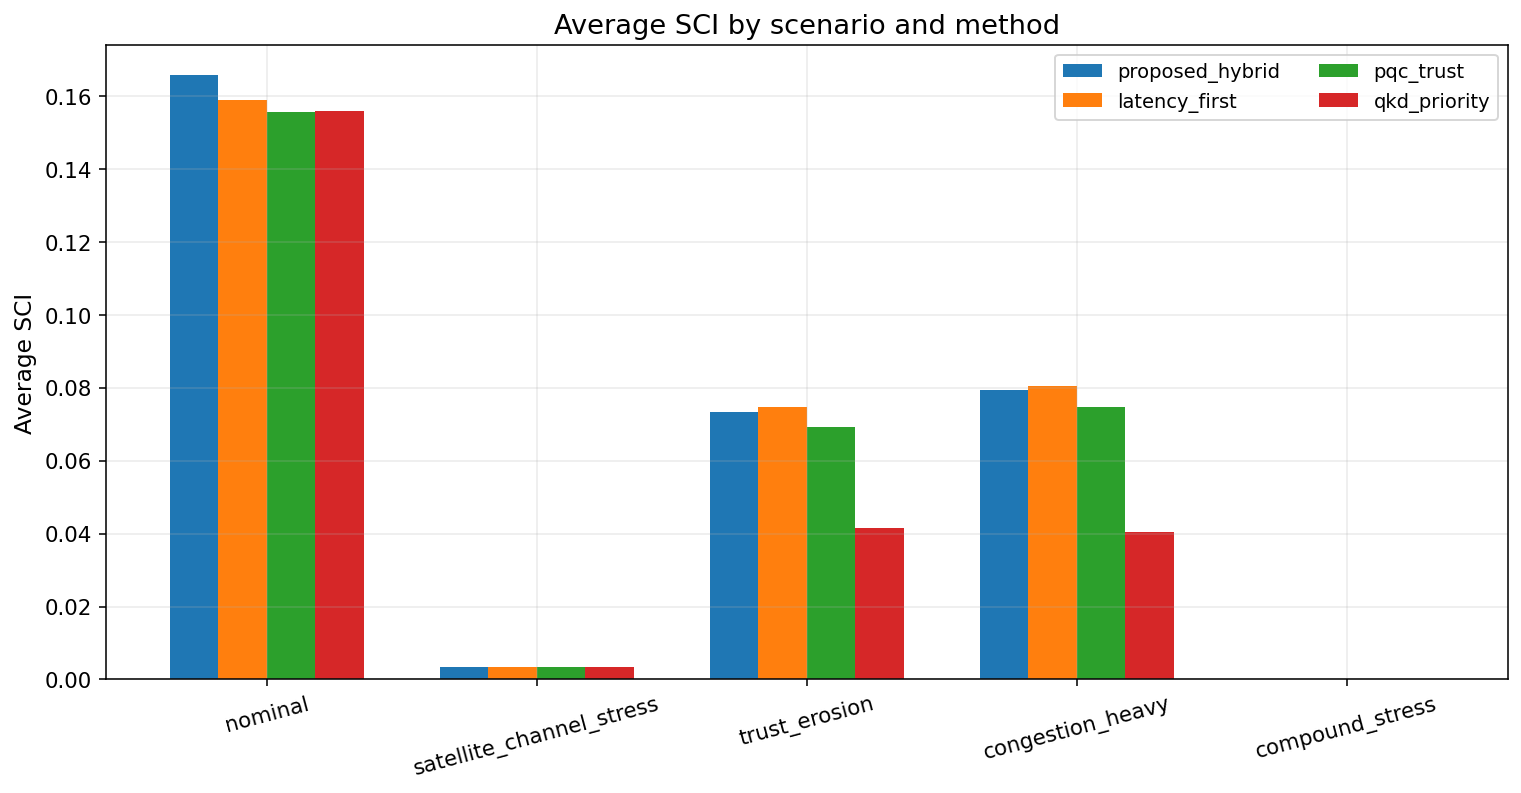

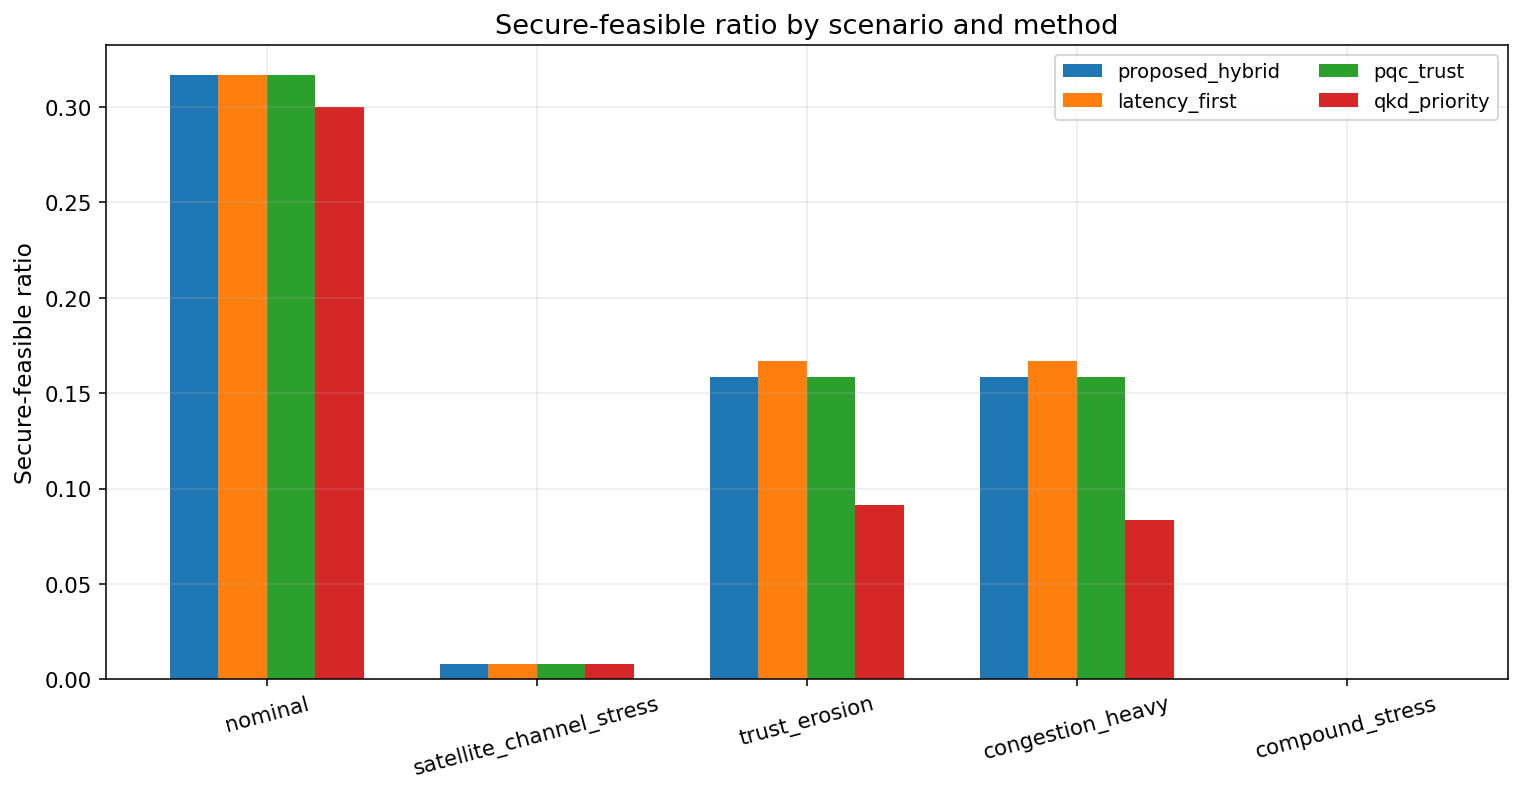

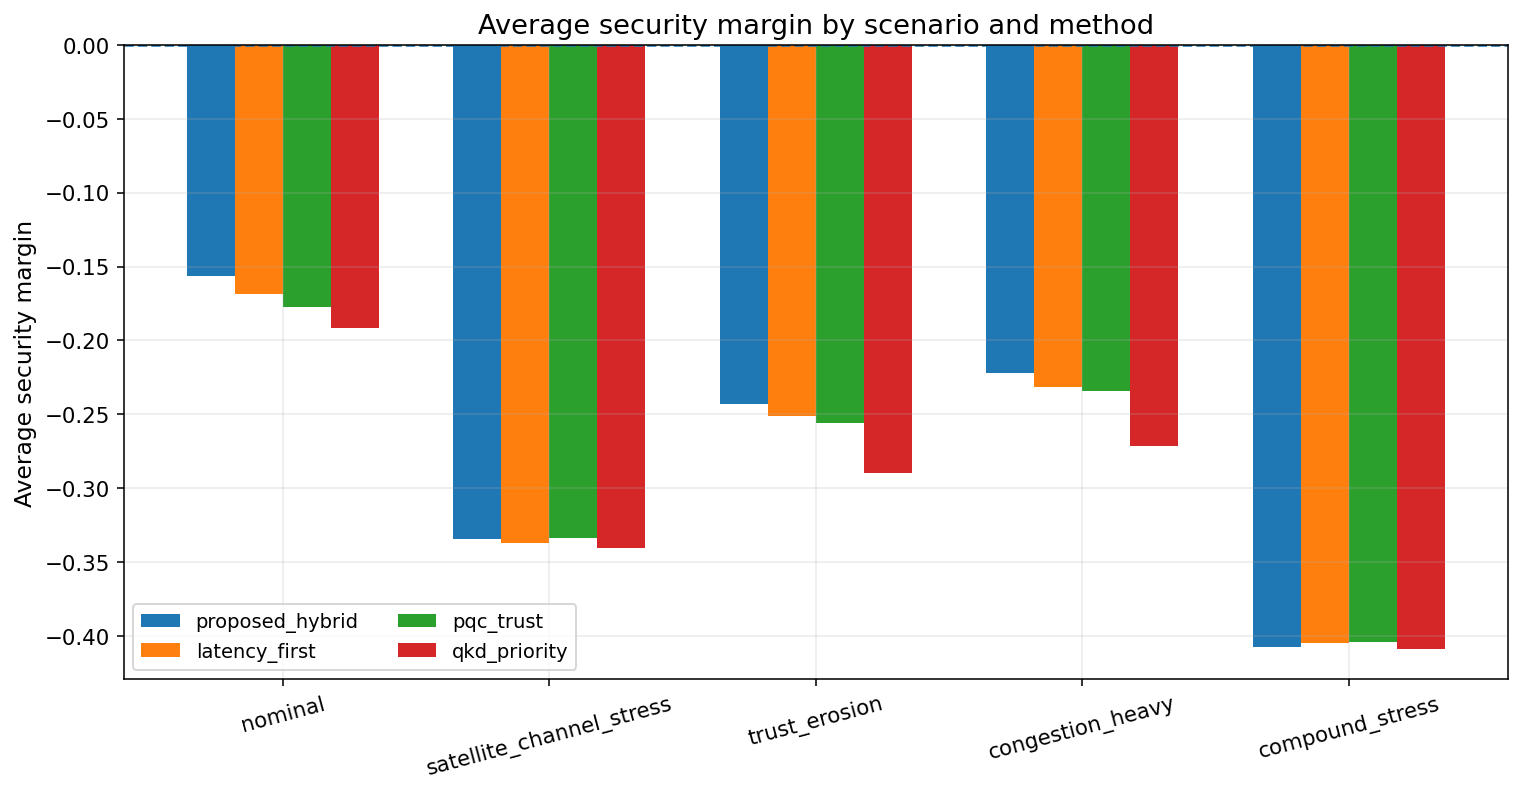

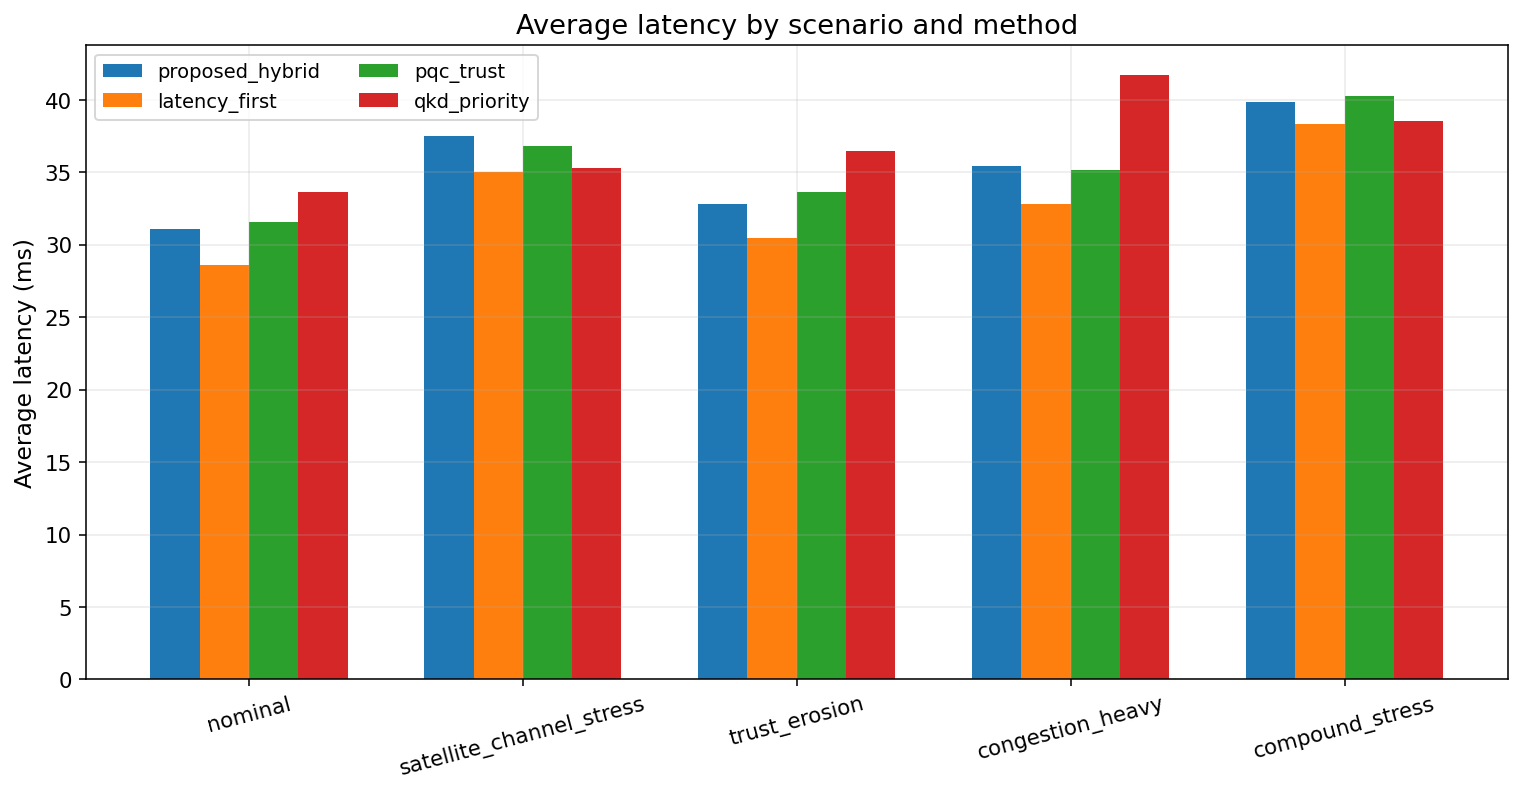

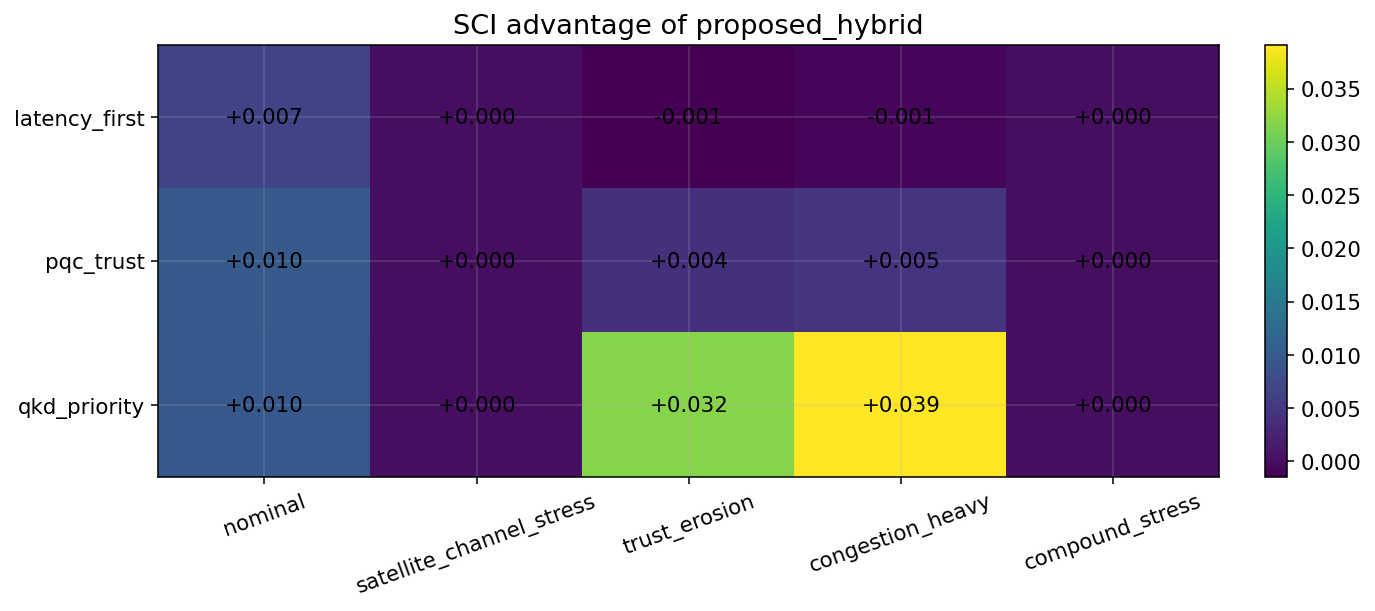

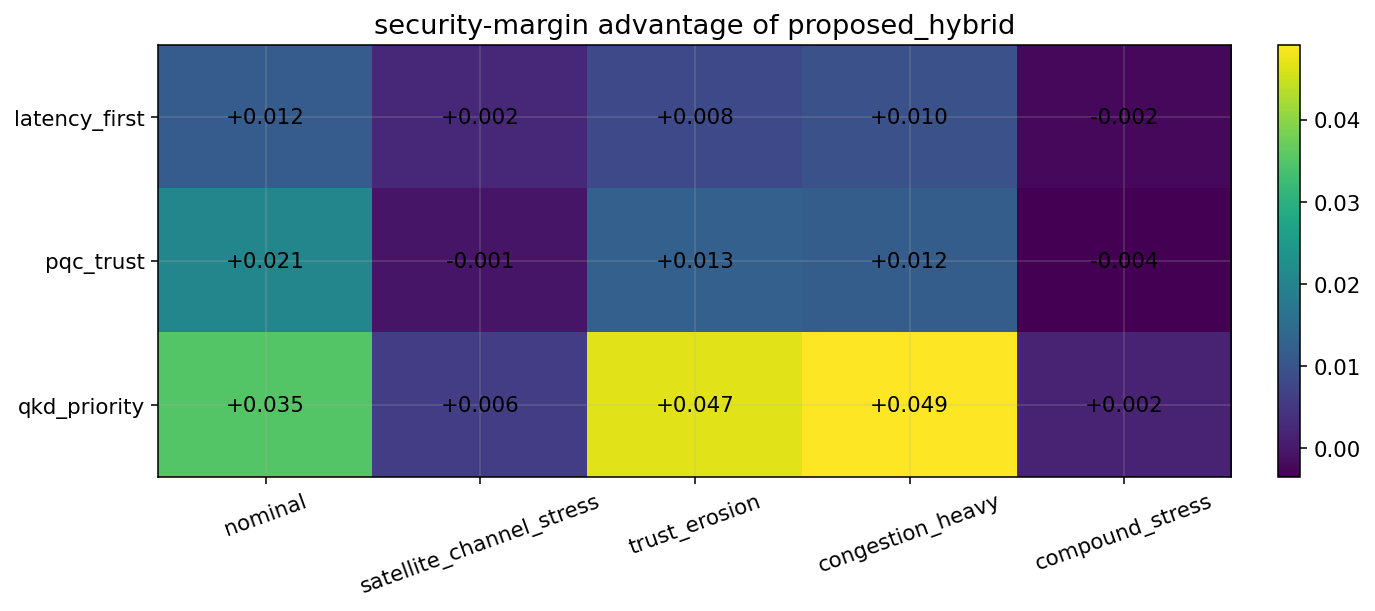

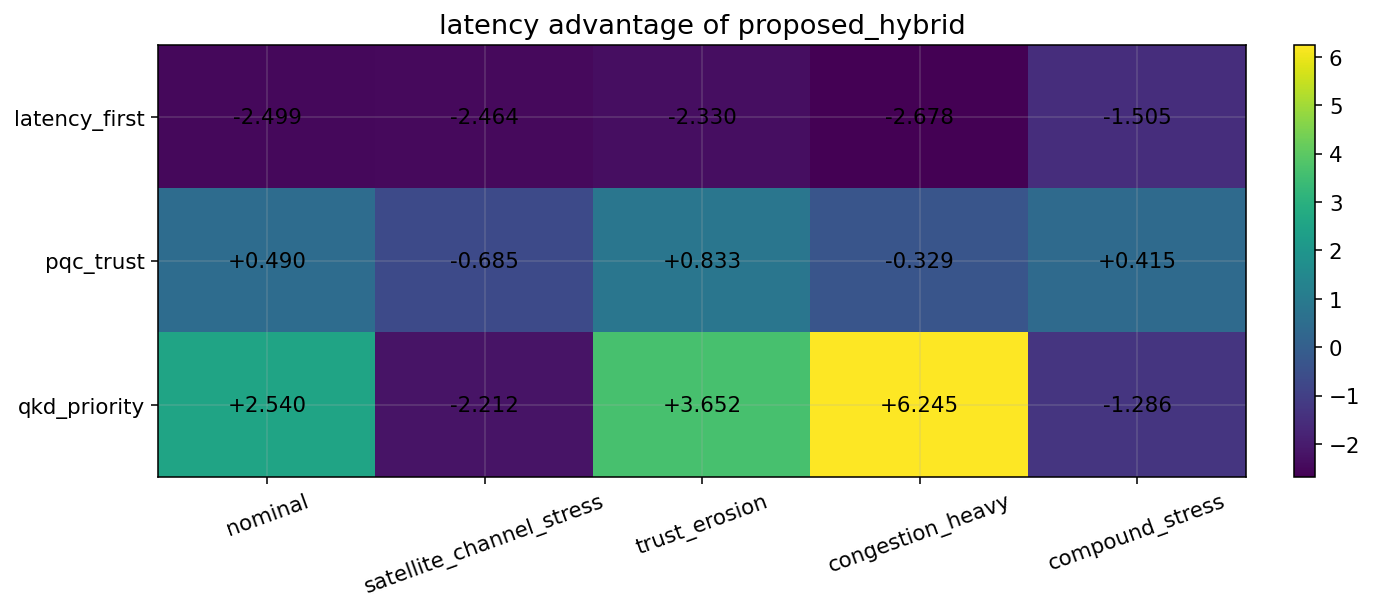

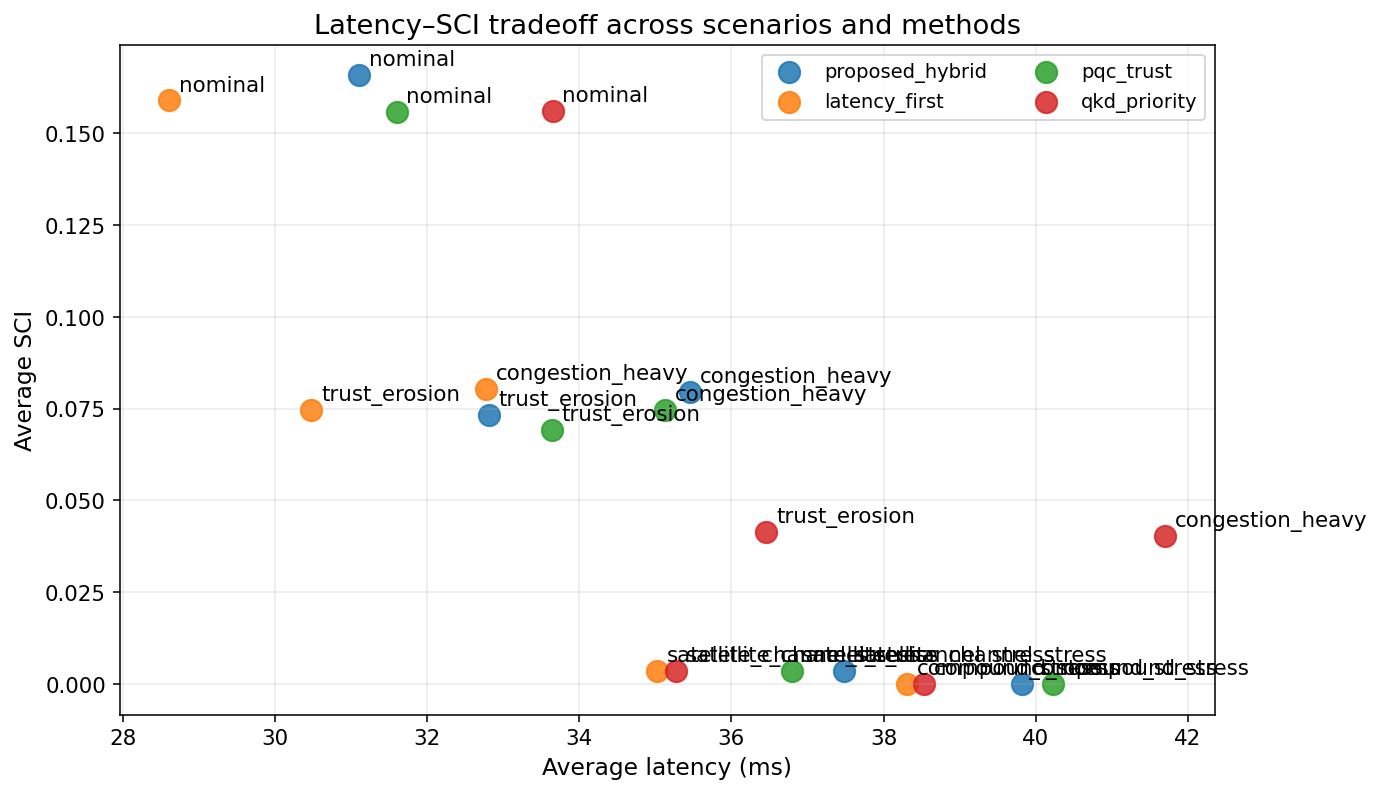

Saved scenario-sweep figures:
- fig16_avg_sci_by_scenario_and_method.png
- fig17_secure_feasible_ratio_by_scenario_and_method.png
- fig18_avg_security_margin_by_scenario_and_method.png
- fig19_avg_latency_by_scenario_and_method.png
- fig20a_sci_advantage_heatmap.png
- fig20b_security_margin_advantage_heatmap.png
- fig20c_latency_advantage_heatmap.png
- fig21_latency_vs_sci_across_scenarios.png


In [14]:
# -----------------------------
# Figure-friendly scenario data
# -----------------------------
scenario_order = [
    "nominal",
    "satellite_channel_stress",
    "trust_erosion",
    "congestion_heavy",
    "compound_stress",
]
method_order = ["proposed_hybrid", "latency_first", "pqc_trust", "qkd_priority"]

scenario_plot_df = (
    scenario_method_summary.copy()
    .assign(
        scenario=lambda df: pd.Categorical(df["scenario"], categories=scenario_order, ordered=True),
        method=lambda df: pd.Categorical(df["method"], categories=method_order, ordered=True)
    )
    .sort_values(["scenario", "method"])
    .reset_index(drop=True)
)

scenario_delta_plot_df = (
    scenario_proposed_vs_baselines_df.copy()
    .assign(
        scenario=lambda df: pd.Categorical(df["scenario"], categories=scenario_order, ordered=True)
    )
    .sort_values(["scenario", "baseline_method"])
    .reset_index(drop=True)
)

# Helper for grouped bar plots
def grouped_bar_plot(df, value_col, ylabel, title, filename, hline_zero=False):
    fig, ax = plt.subplots(figsize=(11, 5.8))
    x = np.arange(len(scenario_order))
    width = 0.18

    for i, method_name in enumerate(method_order):
        subset = (
            df[df["method"] == method_name]
            .set_index("scenario")
            .reindex(scenario_order)
            .reset_index()
        )
        ax.bar(
            x + (i - 1.5) * width,
            subset[value_col],
            width,
            label=method_name
        )

    if hline_zero:
        ax.axhline(0.0, linestyle="--", linewidth=1.3)

    ax.set_xticks(x)
    ax.set_xticklabels(scenario_order, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True, ncol=2)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# Figure 16 — Average SCI by scenario and method
# -----------------------------
grouped_bar_plot(
    df=scenario_plot_df,
    value_col="avg_SCI",
    ylabel="Average SCI",
    title="Average SCI by scenario and method",
    filename="fig16_avg_sci_by_scenario_and_method.png",
    hline_zero=False
)

# -----------------------------
# Figure 17 — Secure-feasible ratio by scenario and method
# -----------------------------
grouped_bar_plot(
    df=scenario_plot_df,
    value_col="secure_feasible_ratio",
    ylabel="Secure-feasible ratio",
    title="Secure-feasible ratio by scenario and method",
    filename="fig17_secure_feasible_ratio_by_scenario_and_method.png",
    hline_zero=False
)

# -----------------------------
# Figure 18 — Average security margin by scenario and method
# -----------------------------
grouped_bar_plot(
    df=scenario_plot_df,
    value_col="avg_security_margin",
    ylabel="Average security margin",
    title="Average security margin by scenario and method",
    filename="fig18_avg_security_margin_by_scenario_and_method.png",
    hline_zero=True
)

# -----------------------------
# Figure 19 — Average latency by scenario and method
# -----------------------------
grouped_bar_plot(
    df=scenario_plot_df,
    value_col="avg_latency",
    ylabel="Average latency (ms)",
    title="Average latency by scenario and method",
    filename="fig19_avg_latency_by_scenario_and_method.png",
    hline_zero=False
)

# -----------------------------
# Figure 20 — Scenario robustness map (proposed vs baselines)
# Metrics shown:
# - delta_avg_SCI
# - delta_avg_security_margin
# - negative delta_avg_latency (so positive means proposed is faster)
# -----------------------------
heatmap_records = []
for _, row in scenario_delta_plot_df.iterrows():
    heatmap_records.append({
        "scenario": row["scenario"],
        "baseline_method": row["baseline_method"],
        "metric": "delta_avg_SCI",
        "value": row["delta_avg_SCI"]
    })
    heatmap_records.append({
        "scenario": row["scenario"],
        "baseline_method": row["baseline_method"],
        "metric": "delta_avg_security_margin",
        "value": row["delta_avg_security_margin"]
    })
    heatmap_records.append({
        "scenario": row["scenario"],
        "baseline_method": row["baseline_method"],
        "metric": "delta_latency_advantage",
        "value": -row["delta_avg_latency"]  # positive means proposed has lower latency
    })

heatmap_df = pd.DataFrame(heatmap_records)

for metric_name, title_suffix, filename in [
    ("delta_avg_SCI", "SCI advantage of proposed_hybrid", "fig20a_sci_advantage_heatmap.png"),
    ("delta_avg_security_margin", "security-margin advantage of proposed_hybrid", "fig20b_security_margin_advantage_heatmap.png"),
    ("delta_latency_advantage", "latency advantage of proposed_hybrid", "fig20c_latency_advantage_heatmap.png"),
]:
    pivot = (
        heatmap_df[heatmap_df["metric"] == metric_name]
        .pivot(index="baseline_method", columns="scenario", values="value")
        .reindex(index=["latency_first", "pqc_trust", "qkd_priority"], columns=scenario_order)
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"{title_suffix}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:+.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# Figure 21 — Latency–SCI tradeoff across scenarios
# -----------------------------
plt.figure(figsize=(10, 5.8))
for method_name, grp in scenario_plot_df.groupby("method"):
    plt.scatter(
        grp["avg_latency"],
        grp["avg_SCI"],
        s=120,
        alpha=0.85,
        label=method_name
    )
    for _, row in grp.iterrows():
        plt.annotate(
            row["scenario"],
            (row["avg_latency"], row["avg_SCI"]),
            textcoords="offset points",
            xytext=(5, 5)
        )

plt.xlabel("Average latency (ms)")
plt.ylabel("Average SCI")
plt.title("Latency–SCI tradeoff across scenarios and methods")
plt.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig21_latency_vs_sci_across_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved scenario-sweep figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    if fig_name.startswith("fig16_") or fig_name.startswith("fig17_") or fig_name.startswith("fig18_") or fig_name.startswith("fig19_") or fig_name.startswith("fig20") or fig_name.startswith("fig21_"):
        print("-", fig_name)

## Cell 14 — Final manuscript package summary and export block

This cell assembles the final manuscript-oriented package from the complete notebook workflow. It extracts key tables, summarizes scenario-level findings, identifies defensible result statements, and exports a final text report that can be used directly while drafting the paper’s results, discussion, and conclusion sections.

In [15]:
# -----------------------------
# Final manuscript package assembly
# -----------------------------
final_report_lines = []
final_report_lines.append("Quantum-Secure 6G STIN — Final Manuscript Package Summary")
final_report_lines.append("=" * 78)
final_report_lines.append("")

# -----------------------------
# Section 1: Experiment overview
# -----------------------------
final_report_lines.append("1. Experiment overview")
final_report_lines.append(f"- Nodes: {G.number_of_nodes()}")
final_report_lines.append(f"- Edges: {G.number_of_edges()}")
final_report_lines.append(f"- Flows: {len(flows)}")
final_report_lines.append(f"- Time steps: {T}")
final_report_lines.append(f"- Methods compared: {', '.join(METHODS)}")
final_report_lines.append(f"- Scenarios evaluated: {', '.join(SCENARIOS.keys())}")
final_report_lines.append("")

# -----------------------------
# Section 2: Best overall method ranking
# -----------------------------
final_report_lines.append("2. Overall method ranking (nominal comparison)")
for _, row in method_rank_table.iterrows():
    final_report_lines.append(
        f"- {row['method']}: mean_rank={row['mean_rank']:.3f}, "
        f"secure_feasible_ratio={row['secure_feasible_ratio']:.3f}, "
        f"allocated_ratio={row['allocated_ratio']:.3f}, "
        f"avg_security_margin={row['avg_security_margin']:.4f}, "
        f"avg_latency={row['avg_latency']:.2f}, "
        f"avg_SCI={row['avg_SCI']:.4f}"
    )
final_report_lines.append("")

# -----------------------------
# Section 3: Scenario-level best method by metric
# -----------------------------
final_report_lines.append("3. Scenario-level best methods by key metric")
for scenario_name in scenario_order:
    sub = scenario_method_summary[scenario_method_summary["scenario"] == scenario_name].copy()

    best_sci = sub.loc[sub["avg_SCI"].idxmax()]
    best_secure = sub.loc[sub["secure_feasible_ratio"].idxmax()]
    best_margin = sub.loc[sub["avg_security_margin"].idxmax()]
    best_latency = sub.loc[sub["avg_latency"].idxmin()]
    best_qshare = sub.loc[sub["avg_q_share"].idxmax()]

    final_report_lines.append(f"- Scenario: {scenario_name}")
    final_report_lines.append(f"    * Best SCI: {best_sci['method']} ({best_sci['avg_SCI']:.4f})")
    final_report_lines.append(f"    * Best secure-feasible ratio: {best_secure['method']} ({best_secure['secure_feasible_ratio']:.4f})")
    final_report_lines.append(f"    * Best security margin: {best_margin['method']} ({best_margin['avg_security_margin']:.4f})")
    final_report_lines.append(f"    * Lowest latency: {best_latency['method']} ({best_latency['avg_latency']:.2f} ms)")
    final_report_lines.append(f"    * Highest quantum share: {best_qshare['method']} ({best_qshare['avg_q_share']:.4f})")
final_report_lines.append("")

# -----------------------------
# Section 4: Proposed method vs baselines by scenario
# -----------------------------
final_report_lines.append("4. Proposed_hybrid relative to baselines by scenario")
for scenario_name in scenario_order:
    final_report_lines.append(f"- Scenario: {scenario_name}")
    sub = scenario_proposed_vs_baselines_df[
        scenario_proposed_vs_baselines_df["scenario"] == scenario_name
    ].sort_values("baseline_method")

    for _, row in sub.iterrows():
        final_report_lines.append(
            f"    * vs {row['baseline_method']}: "
            f"delta_secure_feasible_ratio={row['delta_secure_feasible_ratio']:+.4f}, "
            f"delta_avg_security_margin={row['delta_avg_security_margin']:+.4f}, "
            f"delta_avg_latency={row['delta_avg_latency']:+.4f} ms, "
            f"delta_avg_SCI={row['delta_avg_SCI']:+.4f}"
        )
final_report_lines.append("")

# -----------------------------
# Section 5: Key flow-level observations
# -----------------------------
final_report_lines.append("5. Flow-level observations under nominal hybrid allocation")
for _, row in summary_flow.sort_values("flow_id").iterrows():
    final_report_lines.append(
        f"- {row['flow_id']} ({row['mission']}): "
        f"secure_feasible_ratio={row['secure_feasible_ratio']:.3f}, "
        f"allocated_ratio={row['allocated_ratio']:.3f}, "
        f"avg_security_margin={row['avg_security_margin']:.4f}, "
        f"avg_latency={row['avg_latency']:.2f}, "
        f"dominant_selection_status={row['dominant_selection_status']}"
    )
final_report_lines.append("")

# -----------------------------
# Section 6: Path-switch stability
# -----------------------------
final_report_lines.append("6. Path and allocation-state stability")
for _, row in path_stability_df.sort_values("flow_id").iterrows():
    final_report_lines.append(
        f"- {row['flow_id']}: "
        f"path_switch_rate={row['path_switch_rate']:.3f}, "
        f"status_switch_rate={row['status_switch_rate']:.3f}, "
        f"blocked_fraction={row['blocked_fraction']:.3f}, "
        f"secure_fraction={row['secure_fraction']:.3f}"
    )
final_report_lines.append("")

# -----------------------------
# Section 7: Defensible manuscript claims
# -----------------------------
final_claims = []

# Claim 1: overall ranking
best_method = method_rank_table.iloc[0]["method"]
final_claims.append(
    f"The proposed_hybrid method ranks first overall in the nominal multi-metric comparison "
    f"with mean rank {method_rank_table.iloc[0]['mean_rank']:.3f}."
)

# Claim 2: qkd_priority tradeoff
qkd_row = method_summary[method_summary["method"] == "qkd_priority"].iloc[0]
final_claims.append(
    f"The qkd_priority baseline attains the highest average quantum share "
    f"({qkd_row['avg_q_share']:.4f}) in the nominal setting, but also incurs the highest average latency "
    f"({qkd_row['avg_latency']:.2f} ms) and the lowest average security margin "
    f"({qkd_row['avg_security_margin']:.4f}) among the compared methods."
)

# Claim 3: compound stress collapse
compound_rows = scenario_method_summary[scenario_method_summary["scenario"] == "compound_stress"]
if np.allclose(compound_rows["avg_SCI"].values, 0.0):
    final_claims.append(
        "Under compound_stress, all evaluated methods collapse to near-zero secure operation "
        "with average SCI approximately equal to zero, indicating a system-level failure boundary."
    )

# Claim 4: proposed vs qkd_priority under trust/congestion
for scenario_name in ["trust_erosion", "congestion_heavy"]:
    row = scenario_proposed_vs_baselines_df[
        (scenario_proposed_vs_baselines_df["scenario"] == scenario_name) &
        (scenario_proposed_vs_baselines_df["baseline_method"] == "qkd_priority")
    ].iloc[0]
    final_claims.append(
        f"In {scenario_name}, proposed_hybrid improves average security margin over qkd_priority by "
        f"{row['delta_avg_security_margin']:+.4f} and average SCI by {row['delta_avg_SCI']:+.4f}, "
        f"while reducing average latency by {-row['delta_avg_latency']:.4f} ms."
    )

# Claim 5: honest limitation vs latency_first
for scenario_name in ["trust_erosion", "congestion_heavy"]:
    sub = scenario_method_summary[scenario_method_summary["scenario"] == scenario_name]
    best_sci_method = sub.loc[sub["avg_SCI"].idxmax(), "method"]
    if best_sci_method == "latency_first":
        final_claims.append(
            f"In {scenario_name}, latency_first slightly exceeds proposed_hybrid in average SCI, "
            "showing that the proposed method is best framed as a balanced security-oriented policy "
            "rather than a universal optimum on every metric and scenario."
        )

final_report_lines.append("7. Defensible manuscript claims")
for c in final_claims:
    final_report_lines.append(f"- {c}")
final_report_lines.append("")

# -----------------------------
# Section 8: Exported tables and figures
# -----------------------------
final_report_lines.append("8. Export inventory")
final_report_lines.append("Tables:")
for fname in sorted(os.listdir(TAB_DIR)):
    final_report_lines.append(f"- {fname}")

final_report_lines.append("")
final_report_lines.append("Figures:")
for fname in sorted(os.listdir(FIG_DIR)):
    final_report_lines.append(f"- {fname}")

FINAL_REPORT_PATH = OTH_DIR / "final_manuscript_package_summary.txt"
FINAL_CLAIMS_PATH = OTH_DIR / "final_defensible_claims.txt"

FINAL_REPORT_PATH.write_text("\n".join(final_report_lines), encoding="utf-8")
FINAL_CLAIMS_PATH.write_text("\n".join(final_claims), encoding="utf-8")

print(FINAL_REPORT_PATH.read_text(encoding="utf-8"))
print("")
print("[CLAIMS]")
print(FINAL_CLAIMS_PATH.read_text(encoding="utf-8"))
print("")
print(f"[SAVED] {FINAL_REPORT_PATH}")
print(f"[SAVED] {FINAL_CLAIMS_PATH}")

Quantum-Secure 6G STIN — Final Manuscript Package Summary

1. Experiment overview
- Nodes: 10
- Edges: 18
- Flows: 5
- Time steps: 24
- Methods compared: proposed_hybrid, latency_first, pqc_trust, qkd_priority
- Scenarios evaluated: nominal, satellite_channel_stress, trust_erosion, congestion_heavy, compound_stress

2. Overall method ranking (nominal comparison)
- proposed_hybrid: mean_rank=1.222, secure_feasible_ratio=0.317, allocated_ratio=0.575, avg_security_margin=-0.1567, avg_latency=31.11, avg_SCI=0.1657
- latency_first: mean_rank=1.778, secure_feasible_ratio=0.317, allocated_ratio=0.575, avg_security_margin=-0.1686, avg_latency=28.61, avg_SCI=0.1589
- pqc_trust: mean_rank=2.889, secure_feasible_ratio=0.317, allocated_ratio=0.575, avg_security_margin=-0.1773, avg_latency=31.60, avg_SCI=0.1556
- qkd_priority: mean_rank=3.111, secure_feasible_ratio=0.300, allocated_ratio=0.575, avg_security_margin=-0.1918, avg_latency=33.65, avg_SCI=0.1560

3. Scenario-level best methods by key met